In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

# 1. 读取数据
data_dir = Path("./preprocessed/preprocessed_with_zones")

classic_df = pd.read_csv(data_dir / "classic_with_climate_zones_filtered_30yr_mean.csv")
lpj_df = pd.read_csv(data_dir / "lpj_guess_with_climate_zones_filtered_30yr_mean.csv")

# 2. 变量列名映射
var_map = {
    "P": "precipitation",
    "T": "tran",
    "LAI": "lai",
    "ET": "evapotrans",
    "E_veg": "evspsblveg",
    "E_soil": "evspsblsoi"
}

# 3. 核心组合
pairs = [
    ("P", "ET"),
    ("P", "T"),
    ("P", "E_veg"),
    ("P", "E_soil"),
    ("LAI", "ET"),
    ("LAI", "T"),
    ("LAI", "E_veg"),
    ("LAI", "E_soil"),
]

zone_colors = {
    "HW": "#F27D7A",
    "HD": "#EFD447",
    "CW": "#95D98C",
    "CD": "#73AEEB",
}

zone_labels = {
    "HW": "WW - Warm-Wet",
    "HD": "WD - Warm-Dry",
    "CW": "CW - Cold-Wet",
    "CD": "CD - Cold-Dry",
}

# full_label_map = {
#     "P": "Precipitation",
#     "LAI": "Leaf Area Index",
#     "ET": "Evapotranspiration",
#     "T": "Transpiration",
#     "E_veg": "Vegetation Evaporation",
#     "E_soil": "Soil Evaporation"
# }
full_label_map = {
    "P": "Precipitation (mm yr$^{-1}$)",
    "LAI": "Leaf Area Index",
    "T": "Transpiration (mm yr$^{-1}$)",
    "ET": "Evapotranspiration (mm yr$^{-1}$)",
    "E_veg": "Vegetation Evaporation (mm yr$^{-1}$)",
    "E_soil": "Soil Evaporation (mm yr$^{-1}$)"
}

short_label_map = {
    "P": "Precipitation",
    "LAI": "Leaf Area Index",
    "T": "Transpiration",
    "ET": "Evapotranspiration",
    "E_veg": "Vegetation Evaporation",
    "E_soil": "Soil Evaporation"
}



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit



# =========================================================
# 1. Equal-width binned median curve
# =========================================================

def compute_equal_width_binned_medians(
    x,
    y,
    n_bins=10,
    min_count_per_bin=20
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < min_count_per_bin:
        return None

    x_min, x_max = np.nanmin(x), np.nanmax(x)

    if x_min == x_max:
        return None

    edges = np.linspace(x_min, x_max, n_bins + 1)

    x_med = []
    y_med = []

    for i in range(n_bins):
        left = edges[i]
        right = edges[i + 1]

        if i == n_bins - 1:
            mask = (x >= left) & (x <= right)
        else:
            mask = (x >= left) & (x < right)

        if np.sum(mask) < min_count_per_bin:
            continue

        x_med.append(np.nanmedian(x[mask]))
        y_med.append(np.nanmedian(y[mask]))

    if len(x_med) < 2:
        return None

    return {
        "x": np.asarray(x_med),
        "y": np.asarray(y_med)
    }


# =========================================================
# 2. Equal-count binned median curve
# =========================================================

def compute_equal_count_binned_medians(
    x,
    y,
    n_bins=10,
    min_count_per_bin=20
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < min_count_per_bin:
        return None

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    bin_indices = np.array_split(np.arange(len(x)), n_bins)

    x_med = []
    y_med = []

    for idx in bin_indices:
        if len(idx) < min_count_per_bin:
            continue

        x_med.append(np.nanmedian(x[idx]))
        y_med.append(np.nanmedian(y[idx]))

    if len(x_med) < 2:
        return None

    return {
        "x": np.asarray(x_med),
        "y": np.asarray(y_med)
    }


# =========================================================
# 3. LOWESS curve
# =========================================================

def compute_lowess_curve(
    x,
    y,
    frac=0.18
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return None

    try:
        smoothed = lowess(
            y,
            x,
            frac=frac,
            return_sorted=True
        )

        xs = smoothed[:, 0]
        uniq_idx = np.concatenate([[True], np.diff(xs) > 0])
        smoothed = smoothed[uniq_idx]

        if len(smoothed) < 2:
            return None

        return {
            "x": smoothed[:, 0],
            "y": smoothed[:, 1]
        }

    except Exception:
        return None


# =========================================================
# 4. Polynomial regression curve
# =========================================================

def compute_polynomial_curve(
    x,
    y,
    degree=3,
    n_grid=300
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < degree + 2:
        return None

    try:
        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), n_grid)

        poly = PolynomialFeatures(
            degree=degree,
            include_bias=False
        )

        X_poly = poly.fit_transform(x.reshape(-1, 1))

        model = LinearRegression()
        model.fit(X_poly, y)

        y_grid = model.predict(
            poly.transform(x_grid.reshape(-1, 1))
        )

        return {
            "x": x_grid,
            "y": y_grid
        }

    except Exception:
        return None


# =========================================================
# 5. GAM curve
# =========================================================

def compute_gam_curve(
    x,
    y,
    n_grid=300,
    n_splines=12
):
    try:
        from pygam import LinearGAM, s
    except ImportError:
        return None

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 20:
        return None

    try:
        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), n_grid)

        gam = LinearGAM(
            s(0, n_splines=n_splines)
        ).fit(
            x.reshape(-1, 1),
            y
        )

        y_grid = gam.predict(x_grid.reshape(-1, 1))

        return {
            "x": x_grid,
            "y": y_grid
        }

    except Exception:
        return None


# =========================================================
# 6. Piecewise linear curve
# =========================================================

def piecewise_linear_one_break(x, x0, k1, k2, b):
    return np.where(
        x < x0,
        k1 * x + b,
        k1 * x0 + b + k2 * (x - x0)
    )


def compute_piecewise_linear_curve(
    x,
    y,
    n_grid=300
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 20:
        return None

    try:
        x_min = np.nanmin(x)
        x_max = np.nanmax(x)

        x_grid = np.linspace(x_min, x_max, n_grid)

        p0 = [
            np.nanmedian(x),
            0.0,
            0.0,
            np.nanmedian(y)
        ]

        bounds = (
            [x_min, -np.inf, -np.inf, -np.inf],
            [x_max,  np.inf,  np.inf,  np.inf]
        )

        params, _ = curve_fit(
            piecewise_linear_one_break,
            x,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=20000
        )

        y_grid = piecewise_linear_one_break(x_grid, *params)

        return {
            "x": x_grid,
            "y": y_grid
        }

    except Exception:
        return None


# =========================================================
# 7. Symbolic regression curve
# =========================================================

def compute_symbolic_regression_curve(
    x,
    y,
    n_grid=300,
    max_train=8000,
    random_state=42
):
    try:
        from gplearn.genetic import SymbolicRegressor
    except ImportError:
        return None

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 50:
        return None

    try:
        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), n_grid)

        if len(x) > max_train:
            rng = np.random.default_rng(random_state)
            idx = rng.choice(
                len(x),
                size=max_train,
                replace=False
            )

            x_train = x[idx]
            y_train = y[idx]
        else:
            x_train = x
            y_train = y

        est = SymbolicRegressor(
            population_size=1000,
            generations=15,
            stopping_criteria=0.01,
            p_crossover=0.7,
            p_subtree_mutation=0.1,
            p_hoist_mutation=0.05,
            p_point_mutation=0.1,
            max_samples=0.8,
            verbose=0,
            parsimony_coefficient=0.01,
            random_state=random_state,
            function_set=("add", "sub", "mul", "div", "sqrt", "log")
        )

        est.fit(
            x_train.reshape(-1, 1),
            y_train
        )

        y_grid = est.predict(x_grid.reshape(-1, 1))

        return {
            "x": x_grid,
            "y": y_grid,
            "expression": str(est._program)
        }

    except Exception:
        return None


# =========================================================
# 8. Compute all curves for one x-y relation
# =========================================================

def compute_all_curves_for_relation(
    x,
    y,
    n_bins=10,
    min_count_per_bin=20,
    frac=0.18,
    poly_degree=3,
    include_symbolic=False
):
    curves = {}

    curves["Equal-width bins"] = compute_equal_width_binned_medians(
        x,
        y,
        n_bins=n_bins,
        min_count_per_bin=min_count_per_bin
    )

    curves["Equal-count bins"] = compute_equal_count_binned_medians(
        x,
        y,
        n_bins=n_bins,
        min_count_per_bin=min_count_per_bin
    )

    curves["LOWESS"] = compute_lowess_curve(
        x,
        y,
        frac=frac
    )

    curves[f"Polynomial degree {poly_degree}"] = compute_polynomial_curve(
        x,
        y,
        degree=poly_degree
    )

    curves["GAM"] = compute_gam_curve(
        x,
        y
    )

    curves["Piecewise linear"] = compute_piecewise_linear_curve(
        x,
        y
    )

    if include_symbolic:
        curves["Symbolic regression"] = compute_symbolic_regression_curve(
            x,
            y
        )

    curves = {
        method: curve
        for method, curve in curves.items()
        if curve is not None
    }

    return curves




compute_esm_curves_2x2() 是一个为 2×2 图准备数据的函数。它按照气候区、模型、输入变量和输出变量，提取原始散点，并调用 compute_all_curves_for_relation() 计算多种拟合曲线，最后把这些结果统一保存到 curve_results 里，供后续画图和 shape classification 使用。


In [3]:
# =========================================================
# 9. Compute ESM curves for 2×2 figure
# =========================================================

def compute_esm_curves_2x2(
    classic_df,
    lpj_df,
    var_map,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    n_bins=10,
    min_count_per_bin=20,
    frac=0.18,
    poly_degree=3,
    include_symbolic=False
):
    model_specs = [
        ("CLASSIC", classic_df),
        ("LPJ-GUESS", lpj_df)
    ]

    curve_results = {}

    for x_label in x_labels:
        for model_name, df in model_specs:
            df_zone = df[df["climate_zone"] == climate_zone].copy()

            x_col = var_map[x_label]
            y_col = var_map[y_label]

            sub = (
                df_zone[[x_col, y_col]]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .copy()
            )

            x_raw = sub[x_col].values
            y_raw = sub[y_col].values

            curves = compute_all_curves_for_relation(
                x_raw,
                y_raw,
                n_bins=n_bins,
                min_count_per_bin=min_count_per_bin,
                frac=frac,
                poly_degree=poly_degree,
                include_symbolic=include_symbolic
            )

            curve_results[(x_label, y_label, model_name)] = {
                "x_raw": x_raw,
                "y_raw": y_raw,
                "sub": sub,
                "curves": curves,
                "n_points": len(sub)
            }

    return curve_results

In [4]:
def plot_esm_curves_2x2(
    curve_results,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    model_names=("CLASSIC", "LPJ-GUESS"),
    sample_size=30000,
    point_size=3,
    point_alpha=0.18,
    line_width=1.2,
    n_cols_legend=3
):
    method_styles = {
        "Equal-width bins": {
            "color": "#1f77b4",
            "linestyle": "-"
        },
        "Equal-count bins": {
            "color": "#ff7f0e",
            "linestyle": "-"
        },
        "LOWESS": {
            "color": "#2ca02c",
            "linestyle": "-"
        },
        "Polynomial degree 3": {
            "color": "#d62728",
            "linestyle": "-"
        },
        "GAM": {
            "color": "#9467bd",
            "linestyle": "-"
        },
        "Piecewise linear": {
            "color": "#8c564b",
            "linestyle": "-"
        },
        "Symbolic regression": {
            "color": "#e377c2",
            "linestyle": "-"
        }
    }

    # y-axis limits aligned by row
    y_limits = {}

    for row, x_label in enumerate(x_labels):
        all_y = []

        for model_name in model_names:
            key = (x_label, y_label, model_name)

            if key in curve_results:
                y_raw = curve_results[key]["y_raw"]

                if len(y_raw) > 0:
                    all_y.append(y_raw)

        if len(all_y) > 0:
            y_all = np.concatenate(all_y)

            ymin, ymax = np.nanpercentile(y_all, [1, 99])
            yrange = ymax - ymin

            if yrange == 0:
                yrange = 1

            y_limits[row] = (
                ymin - 0.05 * yrange,
                ymax + 0.05 * yrange
            )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(9, 8),
        dpi=180
    )

    for row, x_label in enumerate(x_labels):
        for col, model_name in enumerate(model_names):
            ax = axes[row, col]

            key = (x_label, y_label, model_name)

            if key not in curve_results:
                continue

            result = curve_results[key]

            x_raw = result["x_raw"]
            y_raw = result["y_raw"]
            sub = result["sub"]
            curves = result["curves"]

            # Scatter sampling
            if len(sub) > sample_size:
                sub_plot = sub.sample(sample_size, random_state=42)
                x_plot = sub_plot.iloc[:, 0].values
                y_plot = sub_plot.iloc[:, 1].values
            else:
                x_plot = x_raw
                y_plot = y_raw

            ax.scatter(
                x_plot,
                y_plot,
                s=point_size,
                alpha=point_alpha,
                color="0.70",
                linewidths=0,
                zorder=1
            )

            # Plot fitted curves
            for method, curve in curves.items():
                style = method_styles.get(
                    method,
                    {
                        "color": "black",
                        "linestyle": "-"
                    }
                )

                ax.plot(
                    curve["x"],
                    curve["y"],
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=line_width,
                    label=method,
                    zorder=5
                )

            # Model label
            ax.text(
                0.03,
                0.97,
                model_name,
                transform=ax.transAxes,
                fontsize=12,
                fontweight="bold",
                ha="left",
                va="top",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="0.65",
                    alpha=0.90
                ),
                zorder=20
            )

            ax.set_xlabel(
                full_label_map.get(x_label, x_label),
                fontsize=12.5
            )

            ax.set_ylabel(
                full_label_map.get(y_label, y_label),
                fontsize=12.5
            )

            if row in y_limits:
                ax.set_ylim(y_limits[row])

            ax.set_title(
                f"{short_label_map.get(x_label, x_label)} → "
                f"{short_label_map.get(y_label, y_label)}",
                fontsize=13,
                pad=9
            )

            ax.set_facecolor("white")
            ax.set_axisbelow(True)
            ax.grid(
                True,
                which="major",
                color="0.82",
                linestyle="-",
                linewidth=0.8
            )
            ax.minorticks_off()

            for side in ["top", "right", "bottom", "left"]:
                ax.spines[side].set_visible(True)
                ax.spines[side].set_linewidth(0.9)
                ax.spines[side].set_color("0.35")

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=10.5,
                length=4,
                width=0.8,
                color="0.35"
            )

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=n_cols_legend,
        frameon=True,
        fontsize=10.5,
        bbox_to_anchor=(0.5, -0.01)
    )

    fig.suptitle(
        # f"{climate_zone} zone: fitted response curves for "
        f"Warm-wet zone: fitted response curves for "
        f"{short_label_map.get(y_label, y_label)}",
        fontsize=15,
        y=0.98
    )

    plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])
    plt.show()

In [5]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import math


# # =========================================================
# # 1. Simple form classification rule
# # =========================================================

# def classify_curve_shape_simple(
#     x_curve,
#     y_curve,
#     y_raw_std=None,
#     flat_threshold=0.05,
#     slope_tol=0.03,
#     monotonic_fraction=0.70,
#     min_net_change_ratio=0.10,
#     turning_amplitude_ratio=0.10,
#     side_fraction_threshold=0.60,
#     roughness_max=3.0,
# ):
#     """
#     Simplified form classification for fitted response curves.

#     Shape labels:
#     - Flat / negligible response
#     - Monotonic increase
#     - Monotonic decrease
#     - U-shaped
#     - Inverted-U-shaped
#     - Complex / uncertain nonlinear

#     Intended use:
#     Apply to fitted curves, not directly to noisy raw scatter points.
#     """

#     # -----------------------------------------------------
#     # 1. Input cleaning
#     # -----------------------------------------------------
#     x = np.asarray(x_curve, dtype=float)
#     y = np.asarray(y_curve, dtype=float)

#     valid = np.isfinite(x) & np.isfinite(y)
#     x = x[valid]
#     y = y[valid]

#     if len(x) < 5:
#         return {"shape_type": "Insufficient data"}

#     order = np.argsort(x)
#     x = x[order]
#     y = y[order]

#     unique_mask = np.concatenate([[True], np.diff(x) > 0])
#     x = x[unique_mask]
#     y = y[unique_mask]

#     if len(x) < 5:
#         return {"shape_type": "Insufficient data"}

#     x_range = float(np.nanmax(x) - np.nanmin(x))
#     y_range_raw = float(np.nanmax(y) - np.nanmin(y))

#     if x_range == 0:
#         return {"shape_type": "Insufficient data"}

#     # -----------------------------------------------------
#     # 2. Flat / negligible response gate before normalization
#     # -----------------------------------------------------
#     flat_gate_used = (
#         y_raw_std is not None
#         and np.isfinite(y_raw_std)
#         and y_raw_std > 0
#     )

#     if flat_gate_used:
#         y_range_to_obs_std = y_range_raw / y_raw_std

#         if y_range_to_obs_std < flat_threshold:
#             return {
#                 "shape_type": "Flat / negligible response",
#                 "y_range_raw": y_range_raw,
#                 "y_raw_std": y_raw_std,
#                 "y_range_to_obs_std": y_range_to_obs_std,
#                 "flat_gate_used": True,
#             }

#     elif y_range_raw == 0:
#         return {
#             "shape_type": "Flat / negligible response",
#             "y_range_raw": 0.0,
#             "y_raw_std": y_raw_std,
#             "y_range_to_obs_std": np.nan,
#             "flat_gate_used": False,
#         }

#     # -----------------------------------------------------
#     # 3. Normalize x and y
#     # -----------------------------------------------------
#     y_min = float(np.nanmin(y))
#     y_range = float(np.nanmax(y) - y_min)

#     if y_range == 0:
#         return {
#             "shape_type": "Flat / negligible response",
#             "y_range_raw": y_range_raw,
#             "y_raw_std": y_raw_std,
#             "y_range_to_obs_std": (
#                 y_range_raw / y_raw_std if flat_gate_used else np.nan
#             ),
#             "flat_gate_used": flat_gate_used,
#         }

#     x_norm = (x - np.nanmin(x)) / x_range
#     y_norm = (y - y_min) / y_range

#     # -----------------------------------------------------
#     # 4. Local slopes
#     # -----------------------------------------------------
#     dx = np.diff(x_norm)
#     dy = np.diff(y_norm)

#     valid_dx = dx != 0
#     dx = dx[valid_dx]
#     dy = dy[valid_dx]

#     if len(dx) < 4:
#         return {"shape_type": "Insufficient data"}

#     slopes = dy / dx

#     signs = np.zeros_like(slopes, dtype=int)
#     signs[slopes > slope_tol] = 1
#     signs[slopes < -slope_tol] = -1
#     signs[np.abs(slopes) <= slope_tol] = 0

#     n_segments = len(signs)

#     pos_fraction = float(np.sum(signs == 1) / n_segments)
#     neg_fraction = float(np.sum(signs == -1) / n_segments)
#     flat_fraction = float(np.sum(signs == 0) / n_segments)

#     nonzero_signs = signs[signs != 0]

#     if len(nonzero_signs) == 0:
#         n_sign_changes = 0
#         first_sign = 0
#         last_sign = 0
#     else:
#         n_sign_changes = int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))
#         first_sign = int(nonzero_signs[0])
#         last_sign = int(nonzero_signs[-1])

#     # -----------------------------------------------------
#     # 5. Net change and roughness
#     # -----------------------------------------------------
#     net_change = float(y_norm[-1] - y_norm[0])
#     net_change_ratio = abs(net_change)

#     total_variation = float(np.sum(np.abs(np.diff(y_norm))))
#     roughness_ratio = total_variation / (abs(net_change) + 1e-9)

#     mostly_increasing = (
#         net_change > min_net_change_ratio
#         and pos_fraction + flat_fraction >= monotonic_fraction
#     )

#     mostly_decreasing = (
#         net_change < -min_net_change_ratio
#         and neg_fraction + flat_fraction >= monotonic_fraction
#     )

#     # -----------------------------------------------------
#     # 6. Tolerant U / inverted-U detection
#     # -----------------------------------------------------
#     min_idx = int(np.argmin(y_norm))
#     max_idx = int(np.argmax(y_norm))

#     valley_is_internal = 0 < min_idx < len(y_norm) - 1
#     peak_is_internal = 0 < max_idx < len(y_norm) - 1

#     left_drop_to_min = float(y_norm[0] - y_norm[min_idx])
#     right_rise_from_min = float(y_norm[-1] - y_norm[min_idx])

#     left_rise_to_max = float(y_norm[max_idx] - y_norm[0])
#     right_drop_from_max = float(y_norm[max_idx] - y_norm[-1])

#     # U-shaped: left side mostly decreasing/flat, right side mostly increasing/flat
#     left_signs_to_min = signs[:max(min_idx, 1)]
#     right_signs_from_min = signs[min_idx:]

#     if len(left_signs_to_min) > 0:
#         left_neg_or_flat = float(np.mean((left_signs_to_min == -1) | (left_signs_to_min == 0)))
#     else:
#         left_neg_or_flat = 0.0

#     if len(right_signs_from_min) > 0:
#         right_pos_or_flat = float(np.mean((right_signs_from_min == 1) | (right_signs_from_min == 0)))
#     else:
#         right_pos_or_flat = 0.0

#     u_shape_candidate = (
#         valley_is_internal
#         and left_drop_to_min >= turning_amplitude_ratio
#         and right_rise_from_min >= turning_amplitude_ratio
#         and left_neg_or_flat >= side_fraction_threshold
#         and right_pos_or_flat >= side_fraction_threshold
#     )

#     # Inverted-U: left side mostly increasing/flat, right side mostly decreasing/flat
#     left_signs_to_max = signs[:max(max_idx, 1)]
#     right_signs_from_max = signs[max_idx:]

#     if len(left_signs_to_max) > 0:
#         left_pos_or_flat = float(np.mean((left_signs_to_max == 1) | (left_signs_to_max == 0)))
#     else:
#         left_pos_or_flat = 0.0

#     if len(right_signs_from_max) > 0:
#         right_neg_or_flat = float(np.mean((right_signs_from_max == -1) | (right_signs_from_max == 0)))
#     else:
#         right_neg_or_flat = 0.0

#     inverted_u_candidate = (
#         peak_is_internal
#         and left_rise_to_max >= turning_amplitude_ratio
#         and right_drop_from_max >= turning_amplitude_ratio
#         and left_pos_or_flat >= side_fraction_threshold
#         and right_neg_or_flat >= side_fraction_threshold
#     )

#     # -----------------------------------------------------
#     # 7. Decision tree
#     # -----------------------------------------------------
#     if u_shape_candidate:
#         shape_type = "U-shaped"

#     elif inverted_u_candidate:
#         shape_type = "Inverted-U-shaped"

#     elif mostly_increasing:
#         shape_type = "Monotonic increase"

#     elif mostly_decreasing:
#         shape_type = "Monotonic decrease"

#     elif (
#         n_sign_changes >= 2
#         or roughness_ratio > roughness_max
#     ):
#         shape_type = "Complex / uncertain nonlinear"

#     else:
#         shape_type = "Complex / uncertain nonlinear"

#     return {
#         "shape_type": shape_type,
#         "y_range_raw": y_range_raw,
#         "y_raw_std": y_raw_std,
#         "y_range_to_obs_std": (
#             y_range_raw / y_raw_std if flat_gate_used else np.nan
#         ),
#         "flat_gate_used": flat_gate_used,
#         "net_change": net_change,
#         "net_change_ratio": net_change_ratio,
#         "pos_fraction": pos_fraction,
#         "neg_fraction": neg_fraction,
#         "flat_fraction": flat_fraction,
#         "n_sign_changes": n_sign_changes,
#         "first_sign": first_sign,
#         "last_sign": last_sign,
#         "roughness_ratio": roughness_ratio,
#         "left_drop_to_min": left_drop_to_min,
#         "right_rise_from_min": right_rise_from_min,
#         "left_rise_to_max": left_rise_to_max,
#         "right_drop_from_max": right_drop_from_max,
#         "left_neg_or_flat": left_neg_or_flat,
#         "right_pos_or_flat": right_pos_or_flat,
#         "left_pos_or_flat": left_pos_or_flat,
#         "right_neg_or_flat": right_neg_or_flat,
#         "u_shape_candidate": u_shape_candidate,
#         "inverted_u_candidate": inverted_u_candidate,
#     }

In [6]:
# def make_curve(func, x_range=(0, 1), n=120, noise=0.0, seed=0):
#     rng = np.random.default_rng(seed)
#     x = np.linspace(*x_range, n)
#     y_true = func(x)
#     y = y_true + noise * rng.standard_normal(n)
#     return x, y, y_true


# y_raw_std = 1.0


# basic_test_cases_simple = [
#     (
#         "Linear increase",
#         lambda x: 0.5 * x,
#         (0, 2),
#         "Monotonic increase",
#     ),
#     (
#         "Linear decrease",
#         lambda x: -0.5 * x,
#         (0, 2),
#         "Monotonic decrease",
#     ),
#     (
#         "Saturating increase: 1 - exp(-3x)",
#         lambda x: 1 - np.exp(-3 * x),
#         (0, 2),
#         "Monotonic increase",
#     ),
#     (
#         "Saturating increase: log(1 + 5x)",
#         lambda x: np.log(1 + 5 * x),
#         (0, 2),
#         "Monotonic increase",
#     ),
#     (
#         "Saturating decrease",
#         lambda x: np.exp(-3 * x),
#         (0, 2),
#         "Monotonic decrease",
#     ),
#     (
#         "U-shaped",
#         lambda x: (x - 1.0) ** 2,
#         (0, 2),
#         "U-shaped",
#     ),
#     (
#         "Inverted-U-shaped",
#         lambda x: 1.0 - (x - 1.0) ** 2,
#         (0, 2),
#         "Inverted-U-shaped",
#     ),
#     (
#         "Flat negligible response",
#         lambda x: 0.001 * x,
#         (0, 2),
#         "Flat / negligible response",
#     ),
#     (
#         "Complex oscillation",
#         lambda x: np.sin(3 * np.pi * x),
#         (0, 2),
#         "Complex / uncertain nonlinear",
#     ),
# ]


# edge_test_cases_simple = [
#     (
#         "Monotonic plus tiny early dip",
#         lambda x: x - 0.005 * np.exp(-50 * (x - 0.05) ** 2),
#         (0, 2),
#         "Monotonic increase",
#     ),
#     (
#         "Nearly flat weak trend",
#         lambda x: 0.01 * x,
#         (0, 2),
#         "Flat / negligible response",
#     ),
#     (
#         "Weak saturating increase but not flat",
#         lambda x: 0.08 * (1 - np.exp(-3 * x)),
#         (0, 2),
#         "Monotonic increase",
#     ),
#     (
#         "Monotonic increase with small wiggles",
#         lambda x: x + 0.03 * np.sin(8 * np.pi * x),
#         (0, 2),
#         "Monotonic increase",
#     ),
#     (
#         "Shallow U-shaped but meaningful",
#         lambda x: 0.20 * (x - 1.0) ** 2,
#         (0, 2),
#         "U-shaped",
#     ),
#     (
#         "Very shallow U should be flat",
#         lambda x: 0.02 * (x - 1.0) ** 2,
#         (0, 2),
#         "Flat / negligible response",
#     ),
#     (
#         "Asymmetric U-shaped",
#         lambda x: np.where(
#             x < 1.0,
#             (x - 1.0) ** 2,
#             0.35 * (x - 1.0) ** 2
#         ),
#         (0, 2),
#         "U-shaped",
#     ),
#     (
#         "Mild log saturation",
#         lambda x: np.log1p(1.5 * x),
#         (0, 2),
#         "Monotonic increase",
#     ),
#     (
#         "Increasing with strong oscillation",
#         lambda x: x + 0.20 * np.sin(6 * np.pi * x),
#         (0, 2),
#         "Complex / uncertain nonlinear",
#     ),
#     (
#         "Late acceleration increase",
#         lambda x: x ** 2,
#         (0, 2),
#         "Monotonic increase",
#     ),
#     (
#         "Late acceleration decrease",
#         lambda x: 1 - x ** 2,
#         (0, 1),
#         "Monotonic decrease",
#     ),
# ]


# all_test_cases_simple = basic_test_cases_simple + edge_test_cases_simple

### 单独画线

In [7]:
def plot_each_curve_4x7(
    curve_results,
    y_label="T",
    x_labels=("P", "LAI"),
    model_names=("CLASSIC", "LPJ-GUESS"),
    methods_order=None,
    show_scatter=True,
    sample_size=12000,
    point_size=2,
    point_alpha=0.12,
    line_width=2.2,
    figsize=(19, 10),
    title_fontsize=15,
    row_label_fontsize=15,
    axis_label_fontsize=13,
    tick_fontsize=11
):
    """
    Plot fitted curves as a 4 x 7 panel.

    Rows:
        CLASSIC: P -> y
        CLASSIC: LAI -> y
        LPJ-GUESS: P -> y
        LPJ-GUESS: LAI -> y

    Columns:
        Fitting methods
    """

    if methods_order is None:
        methods_order = [
            "Equal-width bins",
            "Equal-count bins",
            "LOWESS",
            "Polynomial degree 3",
            "GAM",
            "Piecewise linear",
            "Symbolic regression"
        ]

    # only keep methods that exist in curve_results
    available_methods = []
    for method in methods_order:
        for result in curve_results.values():
            if method in result["curves"]:
                available_methods.append(method)
                break

    methods_order = available_methods

    relation_specs = []
    for model_name in model_names:
        for x_label in x_labels:
            key = (x_label, y_label, model_name)
            if key in curve_results:
                relation_specs.append((model_name, x_label, y_label, key))

    n_rows = len(relation_specs)
    n_cols = len(methods_order)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        dpi=180,
        squeeze=False
    )
    fig.subplots_adjust(
        wspace=0.08,
        hspace=0.08
    )   

    method_color_map = {
        "Equal-width bins": "#1f77b4",
        "Equal-count bins": "#ff7f0e",
        "LOWESS": "#2ca02c",
        "Polynomial degree 3": "#d62728",
        "GAM": "#9467bd",
        "Piecewise linear": "#8c564b",
        "Symbolic regression": "#e377c2"
    }

    method_title_map = {
        "Equal-width bins": "Equal-width\nbins",
        "Equal-count bins": "Equal-count\nbins",
        "LOWESS": "LOWESS",
        "Polynomial degree 3": "Polynomial\nregression",
        "GAM": "GAM",
        "Piecewise linear": "Piecewise\nlinear",
        "Symbolic regression": "Symbolic\nregression"
    }

    x_label_map = {
        "P": "Precipitation",
        "LAI": "LAI"
    }

    y_label_map = {
        "T": "Transpiration",
        "ET": "Evapotranspiration",
        "E_veg": "Vegetation evaporation",
        "E_soil": "Soil evaporation"
    }
    x_label_map = {
        "P": "P",
        "LAI": "LAI"
    }
    y_label_map = {
        "T": "T",
        "ET": "Evapotranspiration",
        "E_veg": "Vegetation evaporation",
        "E_soil": "E_soil"
    }

    full_x_label_map = {
        "P": "Precipitation (mm yr$^{-1}$)",
        "LAI": "LAI"
    }

    full_y_label_map = {
        "T": "Transpiration (mm yr$^{-1}$)",
        "ET": "Evapotranspiration (mm yr$^{-1}$)",
        "E_veg": "Vegetation evaporation (mm yr$^{-1}$)",
        "E_soil": "Soil evaporation (mm yr$^{-1}$)"
    }

    for row, (model_name, x_label, y_label, key) in enumerate(relation_specs):
        result = curve_results[key]

        x_raw = result["x_raw"]
        y_raw = result["y_raw"]
        sub = result["sub"]

        model_short = "LPJ" if model_name == "LPJ-GUESS" else model_name

        for col, method in enumerate(methods_order):
            ax = axes[row, col]

            curve = result["curves"].get(method, None)

            if show_scatter:
                if len(sub) > sample_size:
                    sub_plot = sub.sample(sample_size, random_state=42)
                    x_plot = sub_plot.iloc[:, 0].values
                    y_plot = sub_plot.iloc[:, 1].values
                else:
                    x_plot = x_raw
                    y_plot = y_raw

                ax.scatter(
                    x_plot,
                    y_plot,
                    s=point_size,
                    alpha=point_alpha,
                    color="0.65",
                    linewidths=0,
                    zorder=1
                )

            if curve is not None:
                ax.plot(
                    curve["x"],
                    curve["y"],
                    color=method_color_map.get(method, "black"),
                    linewidth=line_width,
                    zorder=5
                )
            else:
                ax.text(
                    0.5,
                    0.5,
                    "Not available",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    fontsize=axis_label_fontsize,
                    color="0.4"
                )

            # column titles: method names
            if row == 0:
                ax.set_title(
                    method_title_map.get(method, method),
                    fontsize=title_fontsize,
                    pad=12,
                    fontweight="bold"
                )

            # row labels on the left
            if col == 0:
                ax.set_ylabel(
                    f"{model_short}: \n {x_label_map.get(x_label, x_label)} → {y_label_map.get(y_label, y_label)}\n"
                    f"{y_label_map.get(y_label, y_label)}",
                    fontsize=row_label_fontsize,
                    fontweight="bold"
                )
            else:
                ax.set_ylabel("")

            # # x labels only bottom row
            # if row == n_rows - 1:
            #     ax.set_xlabel(
            #         x_label_map.get(x_label, x_label),
            #         fontsize=axis_label_fontsize
            #     )
            # else:
            #     ax.set_xlabel("")
            
            # x labels on every row
            ax.set_xlabel(
                x_label_map.get(x_label, x_label),
                fontsize=axis_label_fontsize
            )

            ax.grid(True, color="0.85", linewidth=0.8)
            ax.set_facecolor("white")

            for side in ["top", "right", "bottom", "left"]:
                ax.spines[side].set_visible(True)
                ax.spines[side].set_linewidth(0.9)
                ax.spines[side].set_color("0.35")

            ax.tick_params(
                axis="both",
                labelsize=tick_fontsize,
                length=4,
                width=0.8,
                color="0.35"
            )

    fig.suptitle(
        f"Separate fitted curves for {y_label_map.get(y_label, y_label)}",
        fontsize=18,
        fontweight="bold",
        y=0.995
    )



    fig.subplots_adjust(
        wspace=0.38,
        hspace=0.35
    )

  
    plt.show()

### 拟合曲线 ——T

In [8]:
curve_results_t = compute_esm_curves_2x2(
    classic_df,
    lpj_df,
    var_map=var_map,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    n_bins=10,
    min_count_per_bin=20,
    frac=0.18,
    poly_degree=3,
    include_symbolic=True
)

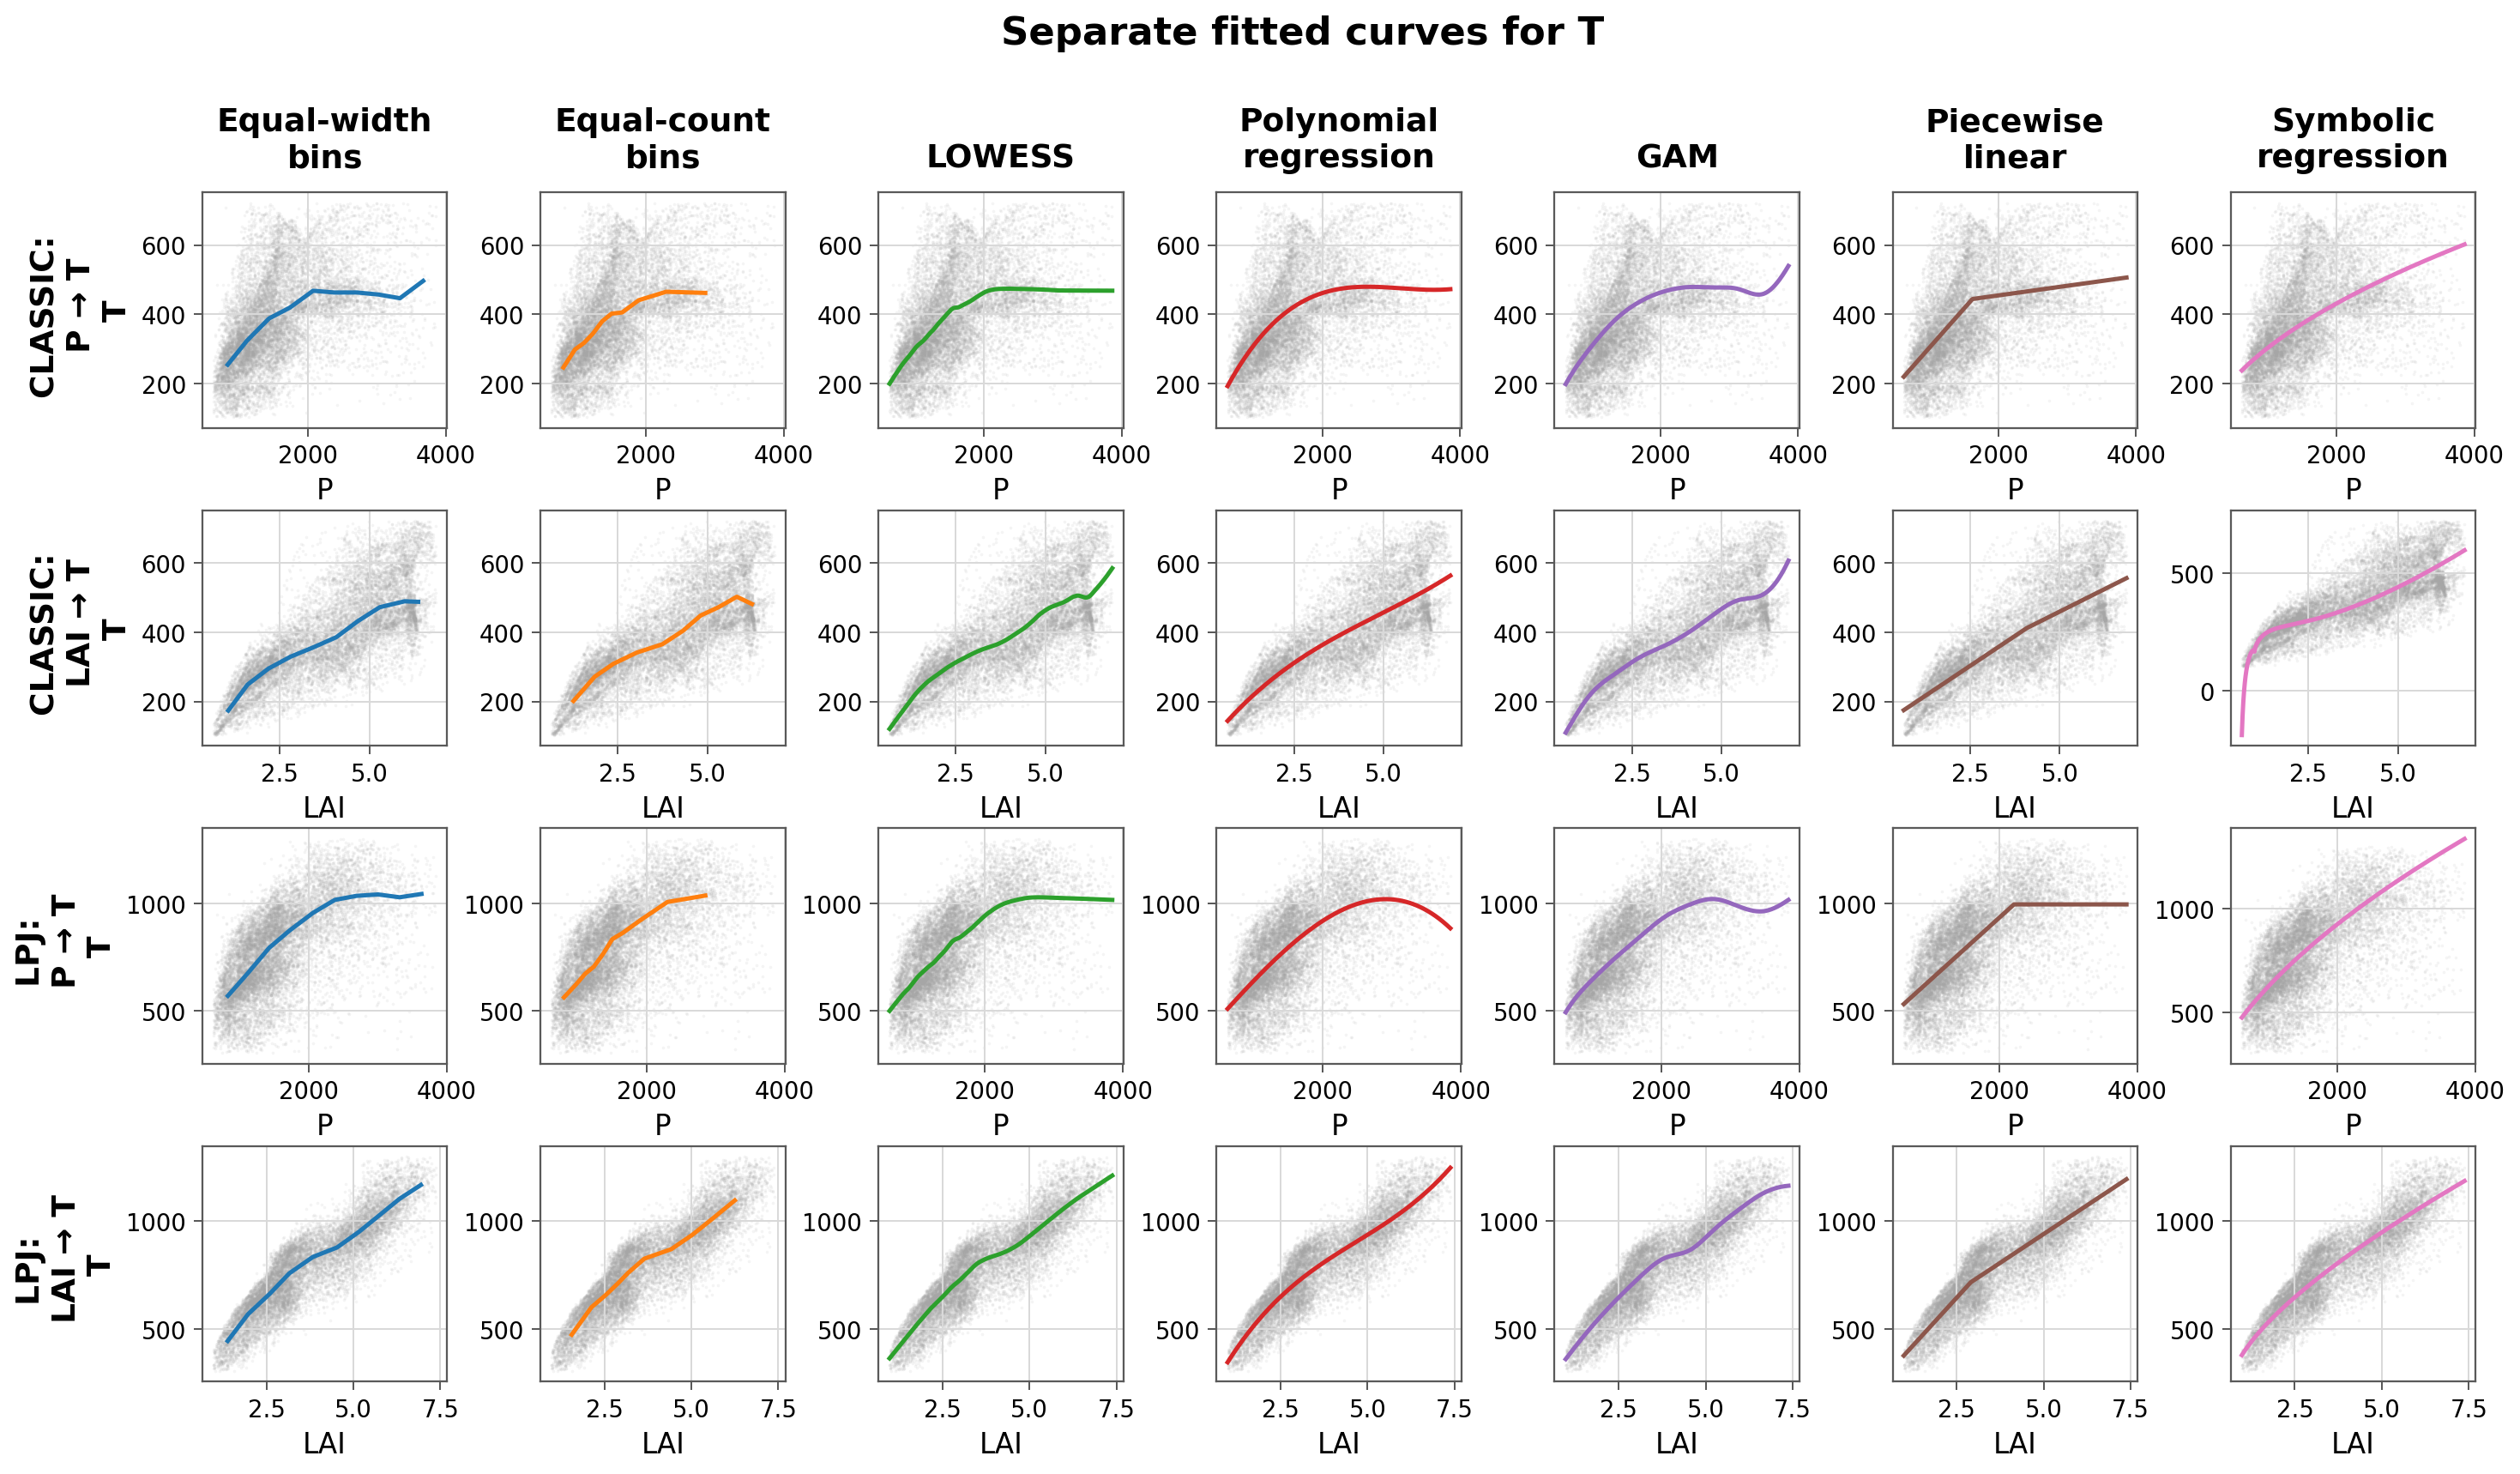

In [9]:

plot_each_curve_4x7(
    curve_results_t,
    y_label="T",
    x_labels=("P", "LAI"),
    model_names=("CLASSIC", "LPJ-GUESS"),
    show_scatter=True,
    line_width=2.0
)

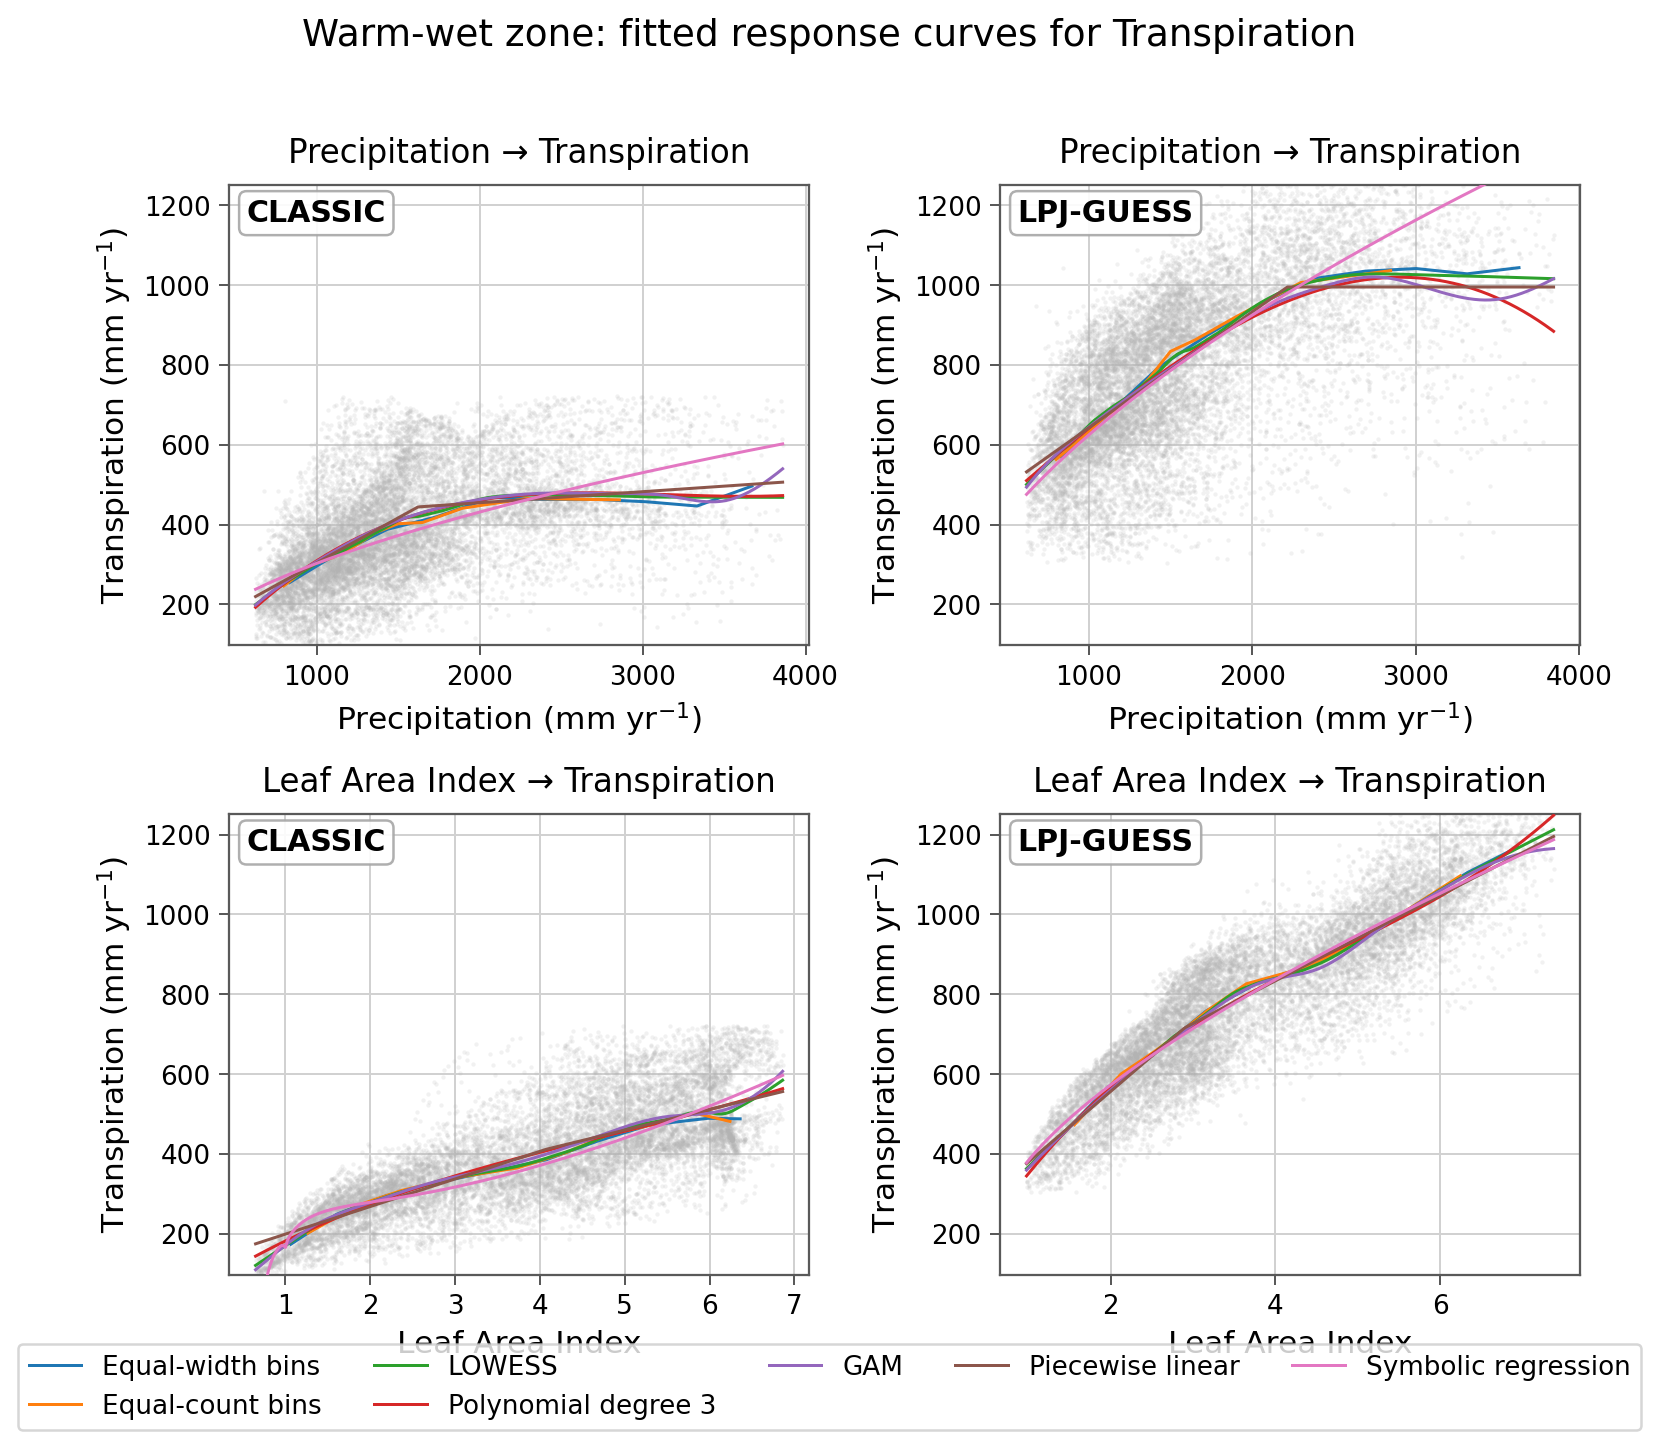

In [10]:
plot_esm_curves_2x2(
    curve_results_t,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    model_names=("CLASSIC", "LPJ-GUESS"),
    line_width=1.2,
    point_alpha=0.18,
    n_cols_legend=5
)

In [85]:
def plot_each_curve_2x7_p_to_t(
    curve_results,
    y_label="T",
    x_label="P",
    model_names=("CLASSIC", "LPJ-GUESS"),
    methods_order=None,
    show_scatter=True,
    sample_size=12000,
    point_size=2,
    point_alpha=0.12,
    line_width=2.2,
    figsize=(21, 6.5),
    dpi=180,
    title_fontsize=14,
    row_label_fontsize=14,
    axis_label_fontsize=12.5,
    tick_fontsize=10.5,
    share_y=True
):
    """
    Plot fitted response curves in a 2 x 7 panel.

    Rows:
        CLASSIC: P -> T
        LPJ-GUESS: P -> T

    Columns:
        fitting methods
    """

    if methods_order is None:
        methods_order = [
            "Equal-width bins",
            "Equal-count bins",
            "LOWESS",
            "Polynomial degree 3",
            "GAM",
            "Piecewise linear",
            "Symbolic regression"
        ]

    method_styles = {
        "Equal-width bins": {
            "color": "#1f77b4",
            "linestyle": "-"
        },
        "Equal-count bins": {
            "color": "#ff7f0e",
            "linestyle": "-"
        },
        "LOWESS": {
            "color": "#2ca02c",
            "linestyle": "-"
        },
        "Polynomial degree 3": {
            "color": "#d62728",
            "linestyle": "-"
        },
        "GAM": {
            "color": "#9467bd",
            "linestyle": "-"
        },
        "Piecewise linear": {
            "color": "#8c564b",
            "linestyle": "-"
        },
        "Symbolic regression": {
            "color": "#e377c2",
            "linestyle": "-"
        }
    }

    # --------------------------------------------------------
    # Axis labels with units
    # --------------------------------------------------------
    x_axis_label = full_label_map.get(x_label, x_label)
    y_axis_label = full_label_map.get(y_label, y_label)

    # --------------------------------------------------------
    # Shared y-axis limit across two rows if needed
    # --------------------------------------------------------
    y_limit = None

    if share_y:
        all_y = []

        for model_name in model_names:
            key = (x_label, y_label, model_name)

            if key in curve_results:
                y_raw = np.asarray(curve_results[key]["y_raw"], dtype=float)
                y_raw = y_raw[np.isfinite(y_raw)]

                if len(y_raw) > 0:
                    all_y.append(y_raw)

        if len(all_y) > 0:
            y_all = np.concatenate(all_y)
            ymin, ymax = np.nanpercentile(y_all, [1, 99])
            yrange = ymax - ymin

            if yrange == 0:
                yrange = 1

            y_limit = (
                ymin - 0.05 * yrange,
                ymax + 0.05 * yrange
            )

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        len(model_names),
        len(methods_order),
        figsize=figsize,
        dpi=dpi,
        sharex=False,
        sharey=share_y
    )

    if len(model_names) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, model_name in enumerate(model_names):
        key = (x_label, y_label, model_name)

        if key not in curve_results:
            for col in range(len(methods_order)):
                axes[row, col].set_visible(False)
            continue

        result = curve_results[key]

        x_raw = np.asarray(result["x_raw"], dtype=float)
        y_raw = np.asarray(result["y_raw"], dtype=float)
        sub = result["sub"]
        curves = result["curves"]

        # ----------------------------------------------------
        # Scatter sampling
        # ----------------------------------------------------
        if len(sub) > sample_size:
            sub_plot = sub.sample(sample_size, random_state=42)
            x_plot = sub_plot.iloc[:, 0].values
            y_plot = sub_plot.iloc[:, 1].values
        else:
            x_plot = x_raw
            y_plot = y_raw

        valid_plot = np.isfinite(x_plot) & np.isfinite(y_plot)
        x_plot = x_plot[valid_plot]
        y_plot = y_plot[valid_plot]

        for col, method in enumerate(methods_order):
            ax = axes[row, col]

            # Scatter
            if show_scatter:
                ax.scatter(
                    x_plot,
                    y_plot,
                    s=point_size,
                    alpha=point_alpha,
                    color="0.70",
                    linewidths=0,
                    zorder=1
                )

            # Fitted curve
            if method in curves and curves[method] is not None:
                curve = curves[method]

                x_curve = np.asarray(curve["x"], dtype=float)
                y_curve = np.asarray(curve["y"], dtype=float)

                valid_curve = np.isfinite(x_curve) & np.isfinite(y_curve)
                x_curve = x_curve[valid_curve]
                y_curve = y_curve[valid_curve]

                style = method_styles.get(
                    method,
                    {
                        "color": "black",
                        "linestyle": "-"
                    }
                )

                ax.plot(
                    x_curve,
                    y_curve,
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=line_width,
                    zorder=5
                )
            else:
                ax.text(
                    0.5,
                    0.5,
                    "Not available",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="0.35"
                )

            # Column titles
            if row == 0:
                ax.set_title(
                    method,
                    fontsize=title_fontsize,
                    pad=9
                )

            # Row labels: model name
            if col == 0:
                ax.text(
                    -0.52,
                    0.5,
                    model_name,
                    transform=ax.transAxes,
                    fontsize=row_label_fontsize,
                    fontweight="bold",
                    rotation=90,
                    ha="center",
                    va="center"
                )

            # Axis labels
            # if row == len(model_names) - 1:
            #     ax.set_xlabel(
            #         x_axis_label,
            #         fontsize=axis_label_fontsize
            #     )
            # else:
            #     ax.set_xlabel("")

            # Show x-axis label for every subplot

            ax.set_xlabel(
                x_axis_label,
                fontsize=axis_label_fontsize
            )

            # Show x-axis tick labels for every subplot

            ax.tick_params(axis="x", labelbottom=True)

            ax.set_ylabel(
                    y_axis_label,
                    fontsize=axis_label_fontsize
                )

            # if col == 0:
            #     ax.set_ylabel(
            #         y_axis_label,
            #         fontsize=axis_label_fontsize
            #     )
            # else:
            #     ax.set_ylabel("")
                # if share_y:
                #     ax.tick_params(axis="y", labelleft=False)

            if y_limit is not None:
                ax.set_ylim(y_limit)

            # Style
            ax.set_facecolor("white")
            ax.set_axisbelow(True)
            ax.grid(
                True,
                which="major",
                color="0.85",
                linestyle="-",
                linewidth=0.75
            )
            ax.minorticks_off()

            for side in ["top", "right", "bottom", "left"]:
                ax.spines[side].set_visible(True)
                ax.spines[side].set_linewidth(0.85)
                ax.spines[side].set_color("0.35")

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=tick_fontsize,
                length=3.5,
                width=0.8,
                color="0.35"
            )

    fig.suptitle(
        f"Fitted response curves for "
        f"{short_label_map.get(x_label, x_label)} → "
        f"{short_label_map.get(y_label, y_label)}",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout(rect=[0.03, 0.02, 1, 0.96])
    plt.show()

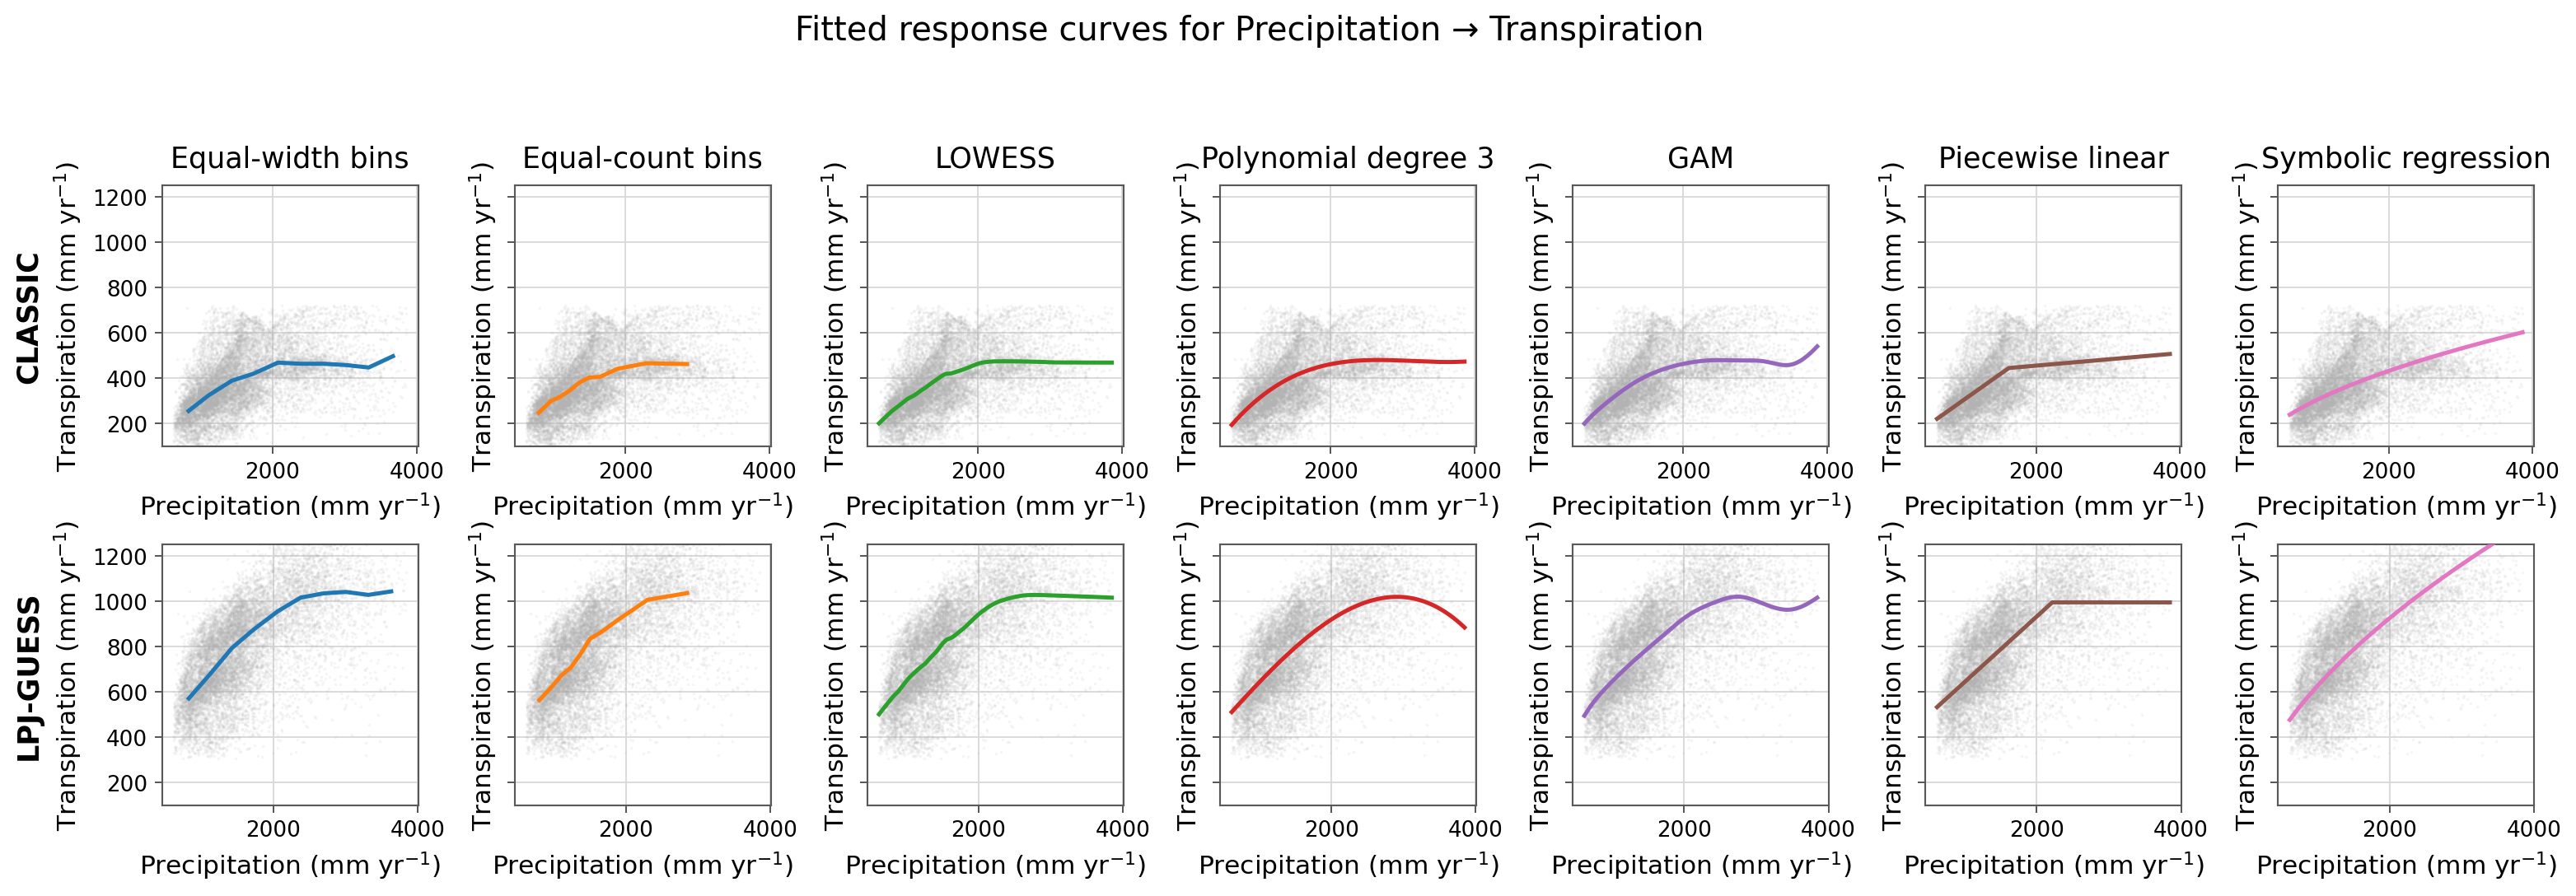

In [86]:
plot_each_curve_2x7_p_to_t(
    curve_results_t,
    y_label="T",
    x_label="P",
    model_names=("CLASSIC", "LPJ-GUESS"),
    show_scatter=True,
    line_width=2.0,
    figsize=(18, 6),
)

In [11]:
# def classify_esm_curves_simple(curve_results):
#     records = []

#     for key, result in curve_results.items():
#         x_label, y_label, model_name = key

#         y_raw = result["y_raw"]
#         y_raw_std = np.nanstd(y_raw)

#         for method, curve in result["curves"].items():
#             shape_result = classify_curve_shape_simple(
#                 curve["x"],
#                 curve["y"],
#                 y_raw_std=y_raw_std
#             )

#             records.append({
#                 "model": model_name,
#                 "x": x_label,
#                 "y": y_label,
#                 "method": method,
#                 "shape_type": shape_result.get("shape_type", np.nan),
#                 "y_range_to_obs_std": shape_result.get("y_range_to_obs_std", np.nan),
#                 "net_change": shape_result.get("net_change", np.nan),
#                 "pos_fraction": shape_result.get("pos_fraction", np.nan),
#                 "neg_fraction": shape_result.get("neg_fraction", np.nan),
#                 "flat_fraction": shape_result.get("flat_fraction", np.nan),
#                 "n_sign_changes": shape_result.get("n_sign_changes", np.nan),
#                 "roughness_ratio": shape_result.get("roughness_ratio", np.nan),
#                 "u_shape_candidate": shape_result.get("u_shape_candidate", np.nan),
#                 "inverted_u_candidate": shape_result.get("inverted_u_candidate", np.nan),
#             })

#     return pd.DataFrame(records)


# shape_df_simple_t = classify_esm_curves_simple(curve_results_t)
# # shape_df_simple

In [12]:
# def make_method_shape_table_simple(shape_df_simple, target_y="T"):
#     shape_table_long = shape_df_simple.copy()

#     shape_table_long["model_short"] = shape_table_long["model"].replace({
#         "CLASSIC": "CLASSIC",
#         "LPJ-GUESS": "LPJ"
#     })

#     shape_table_long["relation_col"] = (
#         shape_table_long["model_short"]
#         + ": "
#         + shape_table_long["x"]
#         + " → "
#         + shape_table_long["y"]
#     )

#     method_name_map = {
#         "Equal-width bins": "Equal-width bins",
#         "Equal-count bins": "Equal-count bins",
#         "LOWESS": "LOWESS",
#         "Polynomial degree 3": "Polynomial regression",
#         "GAM": "Generalized Additive Model (GAM)",
#         "Piecewise linear": "Piecewise linear regression",
#         "Symbolic regression": "Symbolic regression"
#     }

#     shape_table_long["Method"] = (
#         shape_table_long["method"]
#         .map(method_name_map)
#         .fillna(shape_table_long["method"])
#     )

#     shape_table_method_simple = shape_table_long.pivot_table(
#         index="Method",
#         columns="relation_col",
#         values="shape_type",
#         aggfunc="first"
#     ).reset_index()

#     method_order = [
#         "Equal-width bins",
#         "Equal-count bins",
#         "LOWESS",
#         "Polynomial regression",
#         "Generalized Additive Model (GAM)",
#         "Piecewise linear regression",
#         "Symbolic regression"
#     ]

#     shape_table_method_simple["Method"] = pd.Categorical(
#         shape_table_method_simple["Method"],
#         categories=method_order,
#         ordered=True
#     )

#     shape_table_method_simple = (
#         shape_table_method_simple
#         .sort_values("Method")
#         .reset_index(drop=True)
#     )

#     column_order = [
#         "Method",
#         f"CLASSIC: LAI → {target_y}",
#         f"CLASSIC: P → {target_y}",
#         f"LPJ: LAI → {target_y}",
#         f"LPJ: P → {target_y}"
#     ]

#     available_columns = [
#         col for col in column_order
#         if col in shape_table_method_simple.columns
#     ]

#     return shape_table_method_simple[available_columns]

# shape_table_method_simple_t = make_method_shape_table_simple(shape_df_simple_t)
# shape_table_method_simple_t

### 画soil

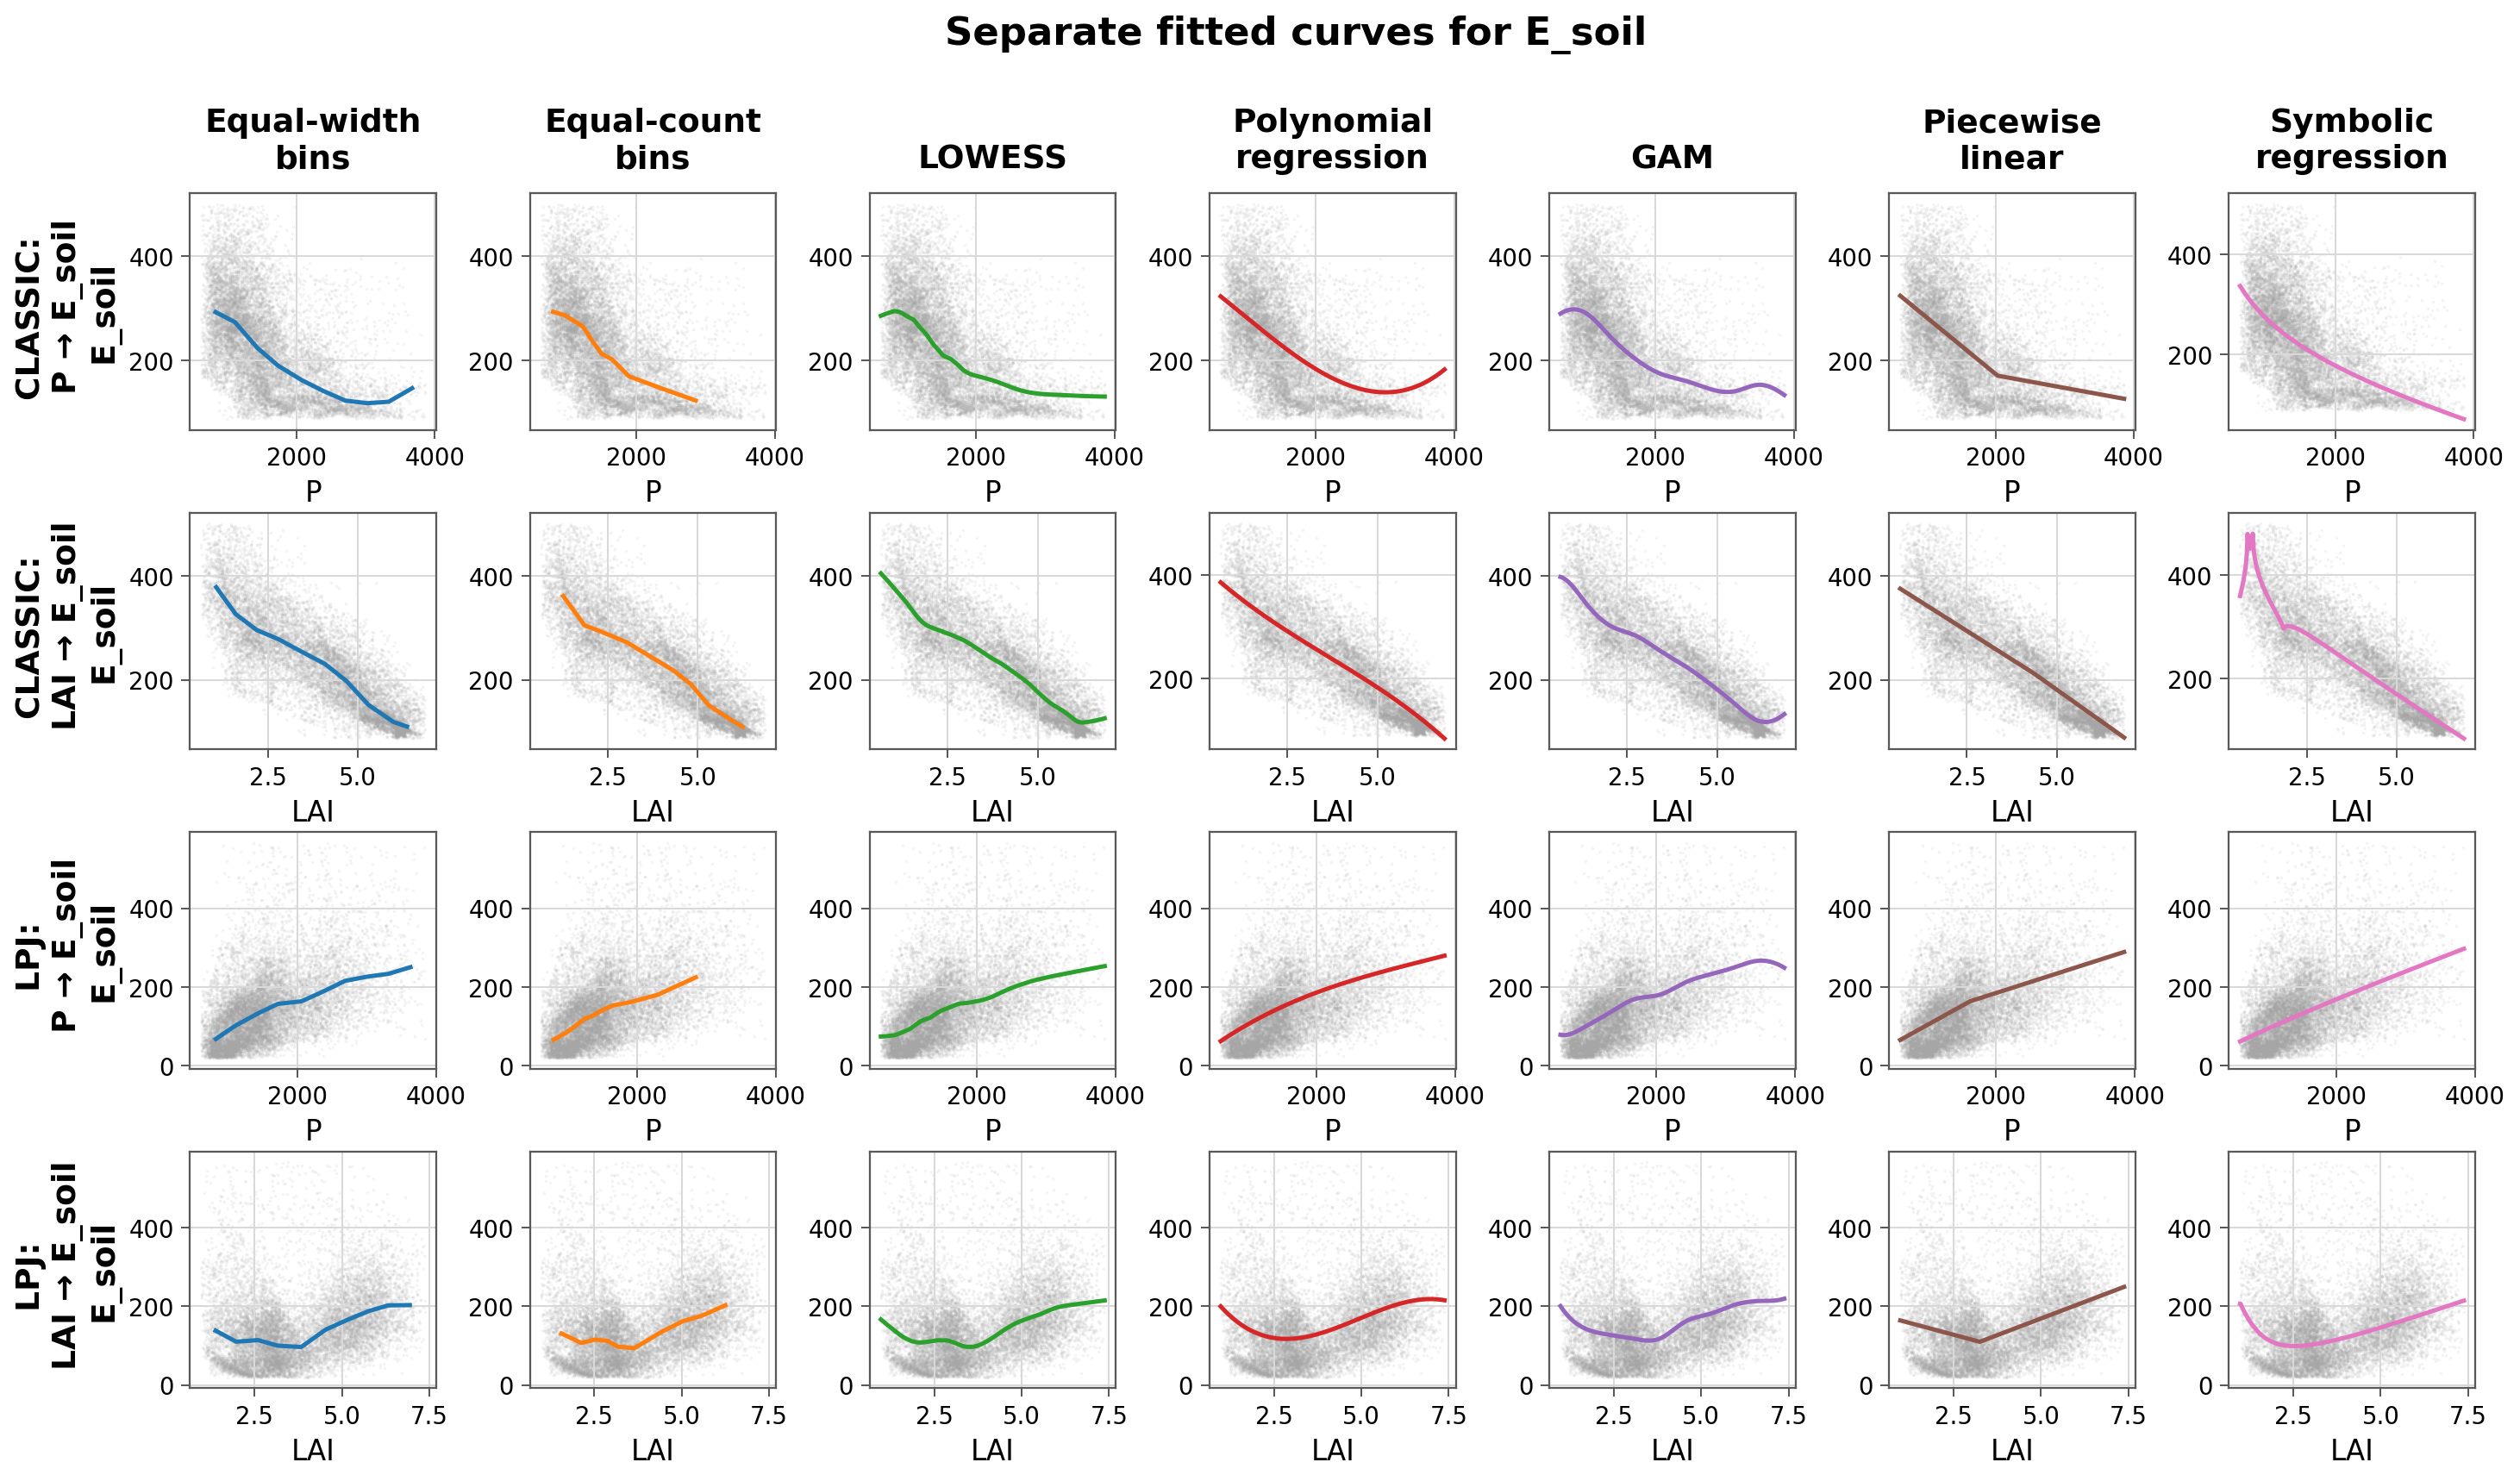

In [13]:
curve_results_esoil = compute_esm_curves_2x2(
    classic_df,
    lpj_df,
    var_map=var_map,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="E_soil",
    n_bins=10,
    min_count_per_bin=20,
    frac=0.18,
    poly_degree=3,
    include_symbolic=True
)

plot_each_curve_4x7(
    curve_results_esoil,
    y_label="E_soil",
    x_labels=("P", "LAI"),
    model_names=("CLASSIC", "LPJ-GUESS"),
    show_scatter=True,
    line_width=2.0
)

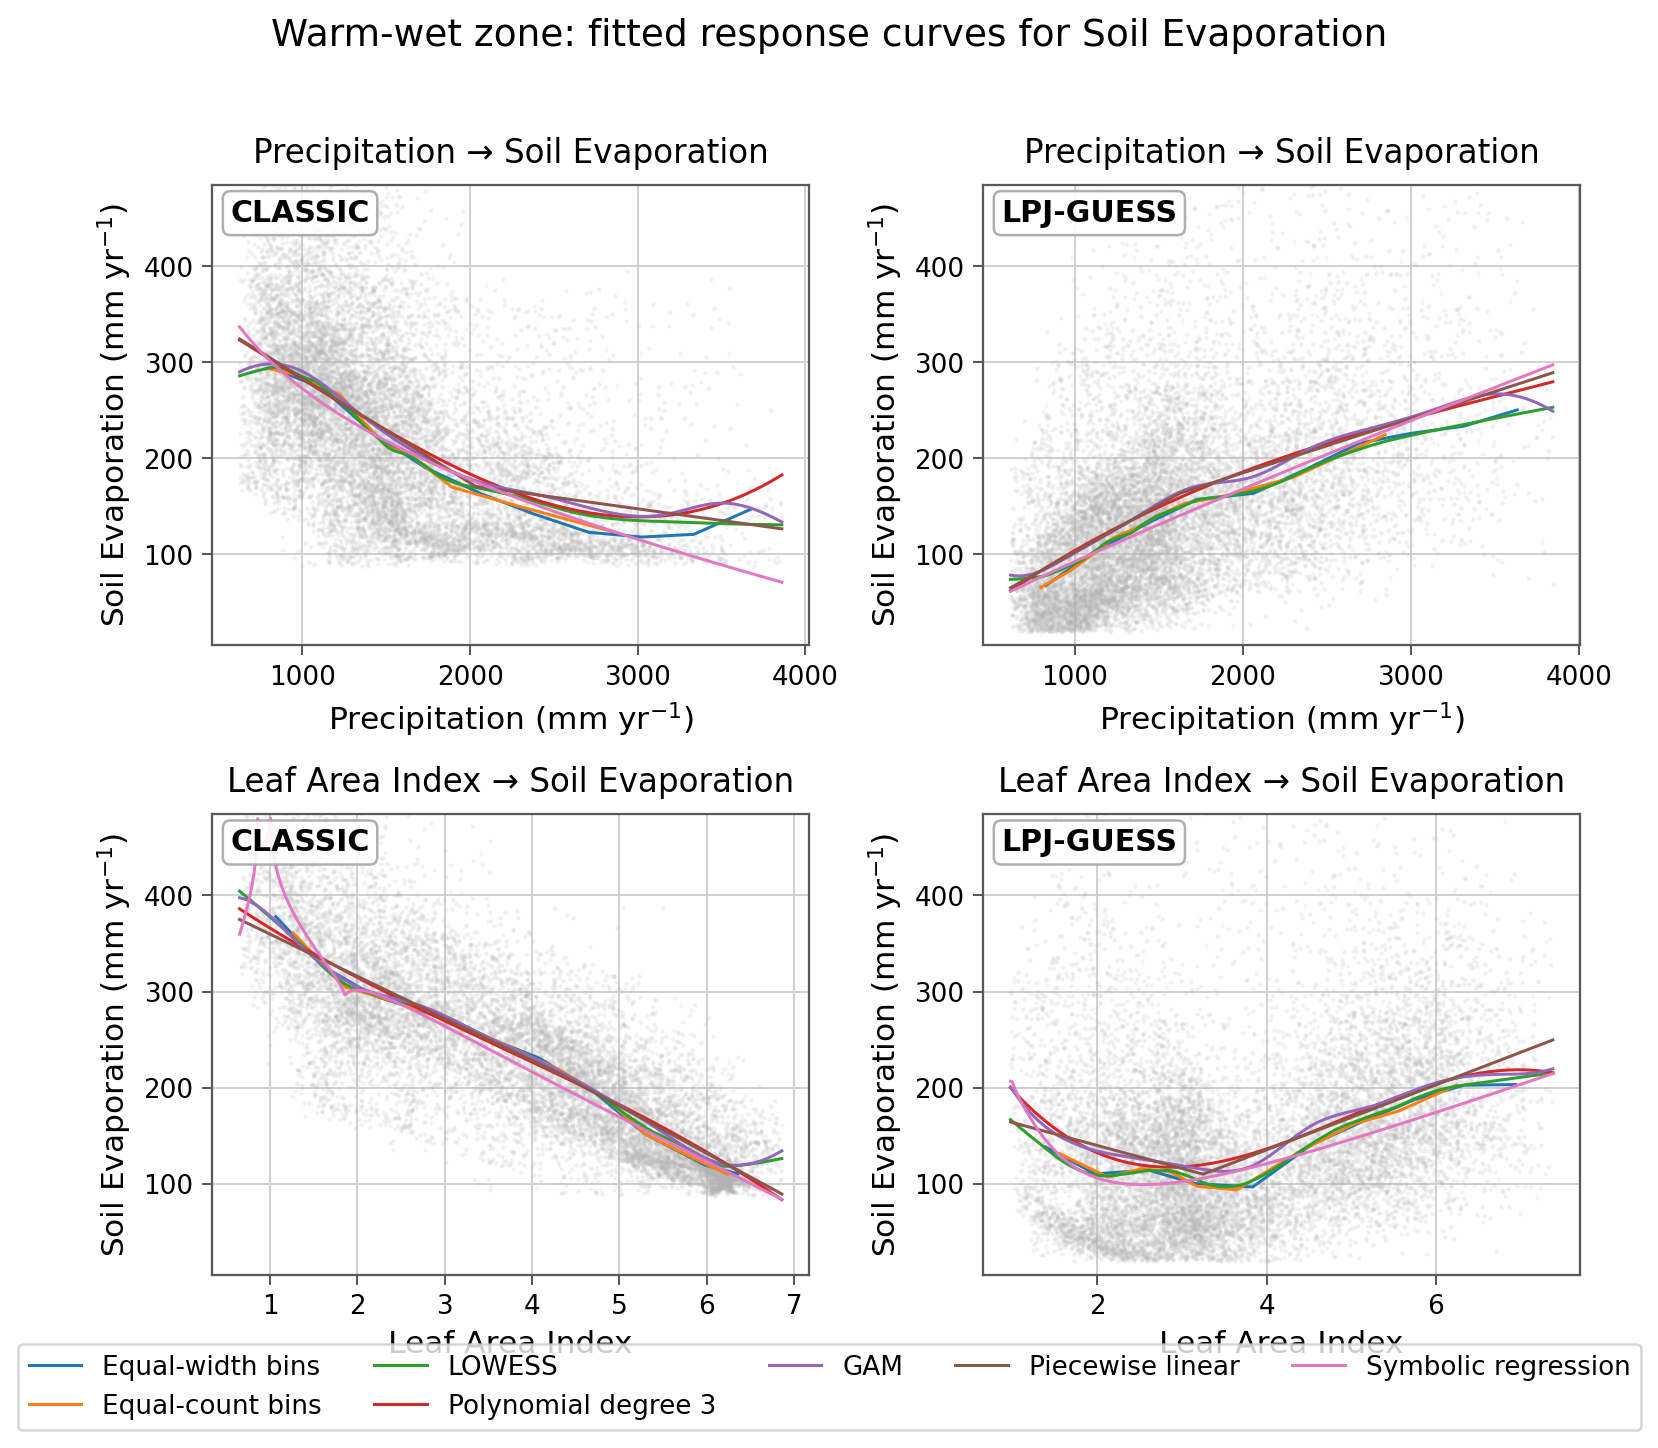

In [14]:
plot_esm_curves_2x2(
    curve_results_esoil,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="E_soil",
    model_names=("CLASSIC", "LPJ-GUESS"),
    line_width=1.2,
    point_alpha=0.18,
    n_cols_legend=5
)

In [15]:


# shape_df_simple_esoil = classify_esm_curves_simple(curve_results_esoil)
# shape_df_simple_esoil

In [16]:


# shape_table_method_simple_esoil = make_method_shape_table_simple(shape_df_simple_esoil, target_y="E_soil")
# shape_table_method_simple_esoil



# Curve shape classifier

In [17]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, kendalltau, norm
import statsmodels.api as sm
from sklearn.isotonic import IsotonicRegression
### 其他的测试维度的方法 斯皮尔曼 皮尔逊 等
# =========================================================
# 6. Spearman / Pearson / U-test methods
# =========================================================

def lind_mehlum_quadratic_test(x, y, alpha=0.05):
    """
    Quadratic U-test inspired by Lind-Mehlum.

    Fit:
        y = b0 + b1*x + b2*x^2

    U-shaped:
        slope at lower x < 0
        slope at upper x > 0
        turning point inside x range

    Inverted-U-shaped:
        slope at lower x > 0
        slope at upper x < 0
        turning point inside x range
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 10:
        return {"lm_result": "Insufficient data"}

    x_min = np.nanmin(x)
    x_max = np.nanmax(x)

    if x_max == x_min:
        return {"lm_result": "Insufficient data"}

    x_norm = (x - x_min) / (x_max - x_min)

    X = np.column_stack([
        np.ones_like(x_norm),
        x_norm,
        x_norm ** 2
    ])

    model = sm.OLS(y, X).fit()

    b0, b1, b2 = model.params
    cov = model.cov_params()

    x_low = np.nanmin(x_norm)
    x_high = np.nanmax(x_norm)

    slope_low = b1 + 2 * b2 * x_low
    slope_high = b1 + 2 * b2 * x_high

    c_low = np.array([0, 1, 2 * x_low])
    c_high = np.array([0, 1, 2 * x_high])

    se_low = np.sqrt(c_low @ cov @ c_low)
    se_high = np.sqrt(c_high @ cov @ c_high)

    z_low = slope_low / se_low if se_low > 0 else np.nan
    z_high = slope_high / se_high if se_high > 0 else np.nan

    p_low_neg = norm.cdf(z_low)
    p_high_pos = 1 - norm.cdf(z_high)

    p_low_pos = 1 - norm.cdf(z_low)
    p_high_neg = norm.cdf(z_high)

    p_u = max(p_low_neg, p_high_pos)
    p_inv_u = max(p_low_pos, p_high_neg)

    turning_point = -b1 / (2 * b2) if b2 != 0 else np.nan
    turning_inside = 0 < turning_point < 1

    u_supported = (
        b2 > 0
        and turning_inside
        and slope_low < 0
        and slope_high > 0
        and p_u < alpha
    )

    inv_u_supported = (
        b2 < 0
        and turning_inside
        and slope_low > 0
        and slope_high < 0
        and p_inv_u < alpha
    )

    if u_supported:
        lm_result = "U-shaped"
    elif inv_u_supported:
        lm_result = "Inverted-U-shaped"
    else:
        lm_result = "No U-shape detected"

    return {
        "lm_result": lm_result,
        "lm_b2": b2,
        "lm_turning_point_norm": turning_point,
        "lm_turning_inside": turning_inside,
        "lm_slope_low": slope_low,
        "lm_slope_high": slope_high,
        "lm_p_u": p_u,
        "lm_p_inv_u": p_inv_u,
    }


def two_line_test(x, y, alpha=0.05, min_side_n=10):
    """
    Practical two-line test.

    Search for a breakpoint.
    Fit one line on the left and one line on the right.

    U-shaped:
        left slope < 0 and significant
        right slope > 0 and significant

    Inverted-U-shaped:
        left slope > 0 and significant
        right slope < 0 and significant
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 * min_side_n:
        return {"two_line_result": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    candidate_indices = range(min_side_n, len(x) - min_side_n)

    best = None

    for idx in candidate_indices:
        x_left = x[:idx]
        y_left = y[:idx]
        x_right = x[idx:]
        y_right = y[idx:]

        X_left = sm.add_constant(x_left)
        X_right = sm.add_constant(x_right)

        left_model = sm.OLS(y_left, X_left).fit()
        right_model = sm.OLS(y_right, X_right).fit()

        rss = np.sum(left_model.resid ** 2) + np.sum(right_model.resid ** 2)

        if best is None or rss < best["rss"]:
            best = {
                "break_index": idx,
                "break_x": x[idx],
                "rss": rss,
                "left_model": left_model,
                "right_model": right_model
            }

    left_model = best["left_model"]
    right_model = best["right_model"]

    left_slope = left_model.params[1]
    right_slope = right_model.params[1]

    left_se = left_model.bse[1]
    right_se = right_model.bse[1]

    z_left = left_slope / left_se if left_se > 0 else np.nan
    z_right = right_slope / right_se if right_se > 0 else np.nan

    p_left_neg = norm.cdf(z_left)
    p_right_pos = 1 - norm.cdf(z_right)

    p_left_pos = 1 - norm.cdf(z_left)
    p_right_neg = norm.cdf(z_right)

    p_u = max(p_left_neg, p_right_pos)
    p_inv_u = max(p_left_pos, p_right_neg)

    u_supported = (
        left_slope < 0
        and right_slope > 0
        and p_u < alpha
    )

    inv_u_supported = (
        left_slope > 0
        and right_slope < 0
        and p_inv_u < alpha
    )

    if u_supported:
        two_line_result = "U-shaped"
    elif inv_u_supported:
        two_line_result = "Inverted-U-shaped"
    else:
        two_line_result = "No U-shape detected"

    return {
        "two_line_result": two_line_result,
        "two_line_break_x": best["break_x"],
        "two_line_left_slope": left_slope,
        "two_line_right_slope": right_slope,
        "two_line_p_u": p_u,
        "two_line_p_inv_u": p_inv_u,
    }


def order_restricted_u_detection(
    x,
    y,
    min_side_n=10,
    amplitude_threshold=0.10
):
    """
    Shape-constrained U detection using isotonic regression.

    U-shaped:
        left side constrained decreasing
        right side constrained increasing

    Inverted-U-shaped:
        left side constrained increasing
        right side constrained decreasing

    This is a constrained-fit detector, not a p-value test.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 * min_side_n:
        return {"order_result": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    y_min = np.nanmin(y)
    y_max = np.nanmax(y)

    if y_max == y_min:
        return {"order_result": "Flat / no U-shape detected"}

    y_norm = (y - y_min) / (y_max - y_min)

    best_u = None
    best_inv_u = None

    for idx in range(min_side_n, len(x) - min_side_n):
        x_left = x[:idx + 1]
        y_left = y_norm[:idx + 1]

        x_right = x[idx:]
        y_right = y_norm[idx:]

        # U: decreasing left, increasing right
        iso_left_dec = IsotonicRegression(increasing=False, out_of_bounds="clip")
        iso_right_inc = IsotonicRegression(increasing=True, out_of_bounds="clip")

        yhat_left_u = iso_left_dec.fit_transform(x_left, y_left)
        yhat_right_u = iso_right_inc.fit_transform(x_right, y_right)

        rss_u = (
            np.sum((y_left - yhat_left_u) ** 2)
            + np.sum((y_right - yhat_right_u) ** 2)
        )

        left_drop = yhat_left_u[0] - yhat_left_u[-1]
        right_rise = yhat_right_u[-1] - yhat_right_u[0]

        if best_u is None or rss_u < best_u["rss"]:
            best_u = {
                "rss": rss_u,
                "turn_x": x[idx],
                "left_drop": left_drop,
                "right_rise": right_rise
            }

        # Inverted-U: increasing left, decreasing right
        iso_left_inc = IsotonicRegression(increasing=True, out_of_bounds="clip")
        iso_right_dec = IsotonicRegression(increasing=False, out_of_bounds="clip")

        yhat_left_inv = iso_left_inc.fit_transform(x_left, y_left)
        yhat_right_inv = iso_right_dec.fit_transform(x_right, y_right)

        rss_inv = (
            np.sum((y_left - yhat_left_inv) ** 2)
            + np.sum((y_right - yhat_right_inv) ** 2)
        )

        left_rise = yhat_left_inv[-1] - yhat_left_inv[0]
        right_drop = yhat_right_inv[0] - yhat_right_inv[-1]

        if best_inv_u is None or rss_inv < best_inv_u["rss"]:
            best_inv_u = {
                "rss": rss_inv,
                "turn_x": x[idx],
                "left_rise": left_rise,
                "right_drop": right_drop
            }

    u_valid = (
        best_u["left_drop"] >= amplitude_threshold
        and best_u["right_rise"] >= amplitude_threshold
    )

    inv_u_valid = (
        best_inv_u["left_rise"] >= amplitude_threshold
        and best_inv_u["right_drop"] >= amplitude_threshold
    )

    if u_valid and (not inv_u_valid or best_u["rss"] <= best_inv_u["rss"]):
        order_result = "U-shaped"
    elif inv_u_valid:
        order_result = "Inverted-U-shaped"
    else:
        order_result = "No U-shape detected"

    return {
        "order_result": order_result,
        "order_u_rss": best_u["rss"],
        "order_u_turn_x": best_u["turn_x"],
        "order_u_left_drop": best_u["left_drop"],
        "order_u_right_rise": best_u["right_rise"],
        "order_inv_rss": best_inv_u["rss"],
        "order_inv_turn_x": best_inv_u["turn_x"],
        "order_inv_left_rise": best_inv_u["left_rise"],
        "order_inv_right_drop": best_inv_u["right_drop"],
    }


In [18]:

def classify_curve_shape(
    x_curve,
    y_curve,
    y_raw_std=None,
    flat_threshold=0.05,
    slope_tol=0.03,
    monotonic_fraction=0.70,
    min_net_change_ratio=0.10,
    turning_amplitude_ratio=0.10,
    side_fraction_threshold=0.60,
    roughness_max=3.0,
):
    """
    Classify the shape of a fitted response curve.

    Shape labels:
    - Flat / negligible response
    - Monotonic increase
    - Monotonic decrease
    - U-shaped
    - Inverted-U-shaped
    - Complex / uncertain nonlinear
    - Insufficient data

    Note:
    This function should be applied to fitted curves, not directly to raw scatter points.
    """

    x = np.asarray(x_curve, dtype=float)
    y = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    unique_mask = np.concatenate([[True], np.diff(x) > 0])
    x = x[unique_mask]
    y = y[unique_mask]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    x_range = float(np.nanmax(x) - np.nanmin(x))
    y_range_raw = float(np.nanmax(y) - np.nanmin(y))

    if x_range == 0:
        return {"shape_type": "Insufficient data"}

    # -----------------------------------------------------
    # S1: Pre-check — response amplitude
    # -----------------------------------------------------
    raw_scale_available = (
        y_raw_std is not None
        and np.isfinite(y_raw_std)
        and y_raw_std > 0
    )

    if raw_scale_available:
        y_range_to_raw_std = y_range_raw / y_raw_std

        if y_range_to_raw_std < flat_threshold:
            return {
                "shape_type": "Flat / negligible response",
                "y_range_raw": y_range_raw,
                "y_raw_std": y_raw_std,
                "y_range_to_raw_std": y_range_to_raw_std,
                "raw_scale_available": True,
            }

    elif y_range_raw == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": 0.0,
            "y_raw_std": y_raw_std,
            "y_range_to_raw_std": np.nan,
            "raw_scale_available": False,
        }

    # -----------------------------------------------------
    # Normalize x and y after pre-check
    # -----------------------------------------------------
    y_min = float(np.nanmin(y))
    y_range = float(np.nanmax(y) - y_min)

    if y_range == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": y_range_raw,
            "y_raw_std": y_raw_std,
            "y_range_to_raw_std": (
                y_range_raw / y_raw_std if raw_scale_available else np.nan
            ),
            "raw_scale_available": raw_scale_available,
        }

    x_norm = (x - np.nanmin(x)) / x_range
    y_norm = (y - y_min) / y_range

    # -----------------------------------------------------
    # Local slopes
    # -----------------------------------------------------
    dx = np.diff(x_norm)
    dy = np.diff(y_norm)

    valid_dx = dx != 0
    dx = dx[valid_dx]
    dy = dy[valid_dx]

    if len(dx) < 4:
        return {"shape_type": "Insufficient data"}

    slopes = dy / dx

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1
    signs[np.abs(slopes) <= slope_tol] = 0

    n_segments = len(signs)

    pos_fraction = float(np.sum(signs == 1) / n_segments)
    neg_fraction = float(np.sum(signs == -1) / n_segments)
    flat_fraction = float(np.sum(signs == 0) / n_segments)

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) == 0:
        n_sign_changes = 0
        first_sign = 0
        last_sign = 0
    else:
        n_sign_changes = int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))
        first_sign = int(nonzero_signs[0])
        last_sign = int(nonzero_signs[-1])

    # -----------------------------------------------------
    # S2: Overall direction
    # -----------------------------------------------------
    net_change = float(y_norm[-1] - y_norm[0])
    net_change_ratio = abs(net_change)

    total_variation = float(np.sum(np.abs(np.diff(y_norm))))
    roughness_ratio = total_variation / (abs(net_change) + 1e-9)

    mostly_increasing = (
        net_change > min_net_change_ratio
        and pos_fraction + flat_fraction >= monotonic_fraction
    )

    mostly_decreasing = (
        net_change < -min_net_change_ratio
        and neg_fraction + flat_fraction >= monotonic_fraction
    )

    # -----------------------------------------------------
    # S3: Major turning point
    # -----------------------------------------------------
    min_idx = int(np.argmin(y_norm))
    max_idx = int(np.argmax(y_norm))

    valley_is_internal = 0 < min_idx < len(y_norm) - 1
    peak_is_internal = 0 < max_idx < len(y_norm) - 1

    left_drop_to_min = float(y_norm[0] - y_norm[min_idx])
    right_rise_from_min = float(y_norm[-1] - y_norm[min_idx])

    left_rise_to_max = float(y_norm[max_idx] - y_norm[0])
    right_drop_from_max = float(y_norm[max_idx] - y_norm[-1])

    # U-shaped: left side mostly decreasing/flat, right side mostly increasing/flat
    left_signs_to_min = signs[:max(min_idx, 1)]
    right_signs_from_min = signs[min_idx:]

    if len(left_signs_to_min) > 0:
        left_neg_or_flat = float(np.mean((left_signs_to_min == -1) | (left_signs_to_min == 0)))
    else:
        left_neg_or_flat = 0.0

    if len(right_signs_from_min) > 0:
        right_pos_or_flat = float(np.mean((right_signs_from_min == 1) | (right_signs_from_min == 0)))
    else:
        right_pos_or_flat = 0.0

    u_shape_candidate = (
        valley_is_internal
        and left_drop_to_min >= turning_amplitude_ratio
        and right_rise_from_min >= turning_amplitude_ratio
        and left_neg_or_flat >= side_fraction_threshold
        and right_pos_or_flat >= side_fraction_threshold
    )

    # Inverted-U: left side mostly increasing/flat, right side mostly decreasing/flat
    left_signs_to_max = signs[:max(max_idx, 1)]
    right_signs_from_max = signs[max_idx:]

    if len(left_signs_to_max) > 0:
        left_pos_or_flat = float(np.mean((left_signs_to_max == 1) | (left_signs_to_max == 0)))
    else:
        left_pos_or_flat = 0.0

    if len(right_signs_from_max) > 0:
        right_neg_or_flat = float(np.mean((right_signs_from_max == -1) | (right_signs_from_max == 0)))
    else:
        right_neg_or_flat = 0.0

    inverted_u_candidate = (
        peak_is_internal
        and left_rise_to_max >= turning_amplitude_ratio
        and right_drop_from_max >= turning_amplitude_ratio
        and left_pos_or_flat >= side_fraction_threshold
        and right_neg_or_flat >= side_fraction_threshold
    )

    # -----------------------------------------------------
    # Decision tree
    # -----------------------------------------------------
    if u_shape_candidate:
        shape_type = "U-shaped"

    elif inverted_u_candidate:
        shape_type = "Inverted-U-shaped"

    elif mostly_increasing:
        shape_type = "Monotonic increase"

    elif mostly_decreasing:
        shape_type = "Monotonic decrease"

    elif (
        n_sign_changes >= 2
        or roughness_ratio > roughness_max
    ):
        shape_type = "Complex / uncertain nonlinear"

    else:
        shape_type = "Complex / uncertain nonlinear"

    return {
        "shape_type": shape_type,

        # S1
        "y_range_raw": y_range_raw,
        "y_raw_std": y_raw_std,
        "y_range_to_raw_std": (
            y_range_raw / y_raw_std if raw_scale_available else np.nan
        ),
        "raw_scale_available": raw_scale_available,

        # S2
        "net_change": net_change,
        "net_change_ratio": net_change_ratio,
        "pos_fraction": pos_fraction,
        "neg_fraction": neg_fraction,
        "flat_fraction": flat_fraction,
        "n_sign_changes": n_sign_changes,
        "first_sign": first_sign,
        "last_sign": last_sign,
        "roughness_ratio": roughness_ratio,

        # S3
        "valley_is_internal": valley_is_internal,
        "peak_is_internal": peak_is_internal,
        "left_drop_to_min": left_drop_to_min,
        "right_rise_from_min": right_rise_from_min,
        "left_rise_to_max": left_rise_to_max,
        "right_drop_from_max": right_drop_from_max,
        "left_neg_or_flat": left_neg_or_flat,
        "right_pos_or_flat": right_pos_or_flat,
        "left_pos_or_flat": left_pos_or_flat,
        "right_neg_or_flat": right_neg_or_flat,
        "u_shape_candidate": u_shape_candidate,
        "inverted_u_candidate": inverted_u_candidate,
    }


在你已经计算好的 fitted curves 上，运行一组“形式检验 / U-shape 检验 / 相关性检验”，然后生成一个结果表。

它不是重新拟合曲线，也不是直接处理原始散点，而是处理你前面 compute_esm_curves_2x2() 生成的：

In [53]:
def run_formal_u_tests_on_curve_results(
    curve_results,
    alpha=0.05,
    min_side_n=10,
    amplitude_threshold=0.10
):
    records = []

    for key, result in curve_results.items():
        x_label, y_label, model_name = key

        # ====================================================
        # 1. Correlation based on raw scatter points
        # ====================================================
        x_raw = np.asarray(result["x_raw"], dtype=float)
        y_raw = np.asarray(result["y_raw"], dtype=float)

        valid_raw = np.isfinite(x_raw) & np.isfinite(y_raw)
        x_raw_valid = x_raw[valid_raw]
        y_raw_valid = y_raw[valid_raw]

        if (
            len(x_raw_valid) < 5
            or np.nanstd(x_raw_valid) == 0
            or np.nanstd(y_raw_valid) == 0
        ):
            pearson_r = np.nan
            pearson_p = np.nan
            spearman_rho = np.nan
            spearman_p = np.nan
            kendall_tau = np.nan
            kendall_p = np.nan
        else:
            pearson_r, pearson_p = pearsonr(x_raw_valid, y_raw_valid)
            spearman_rho, spearman_p = spearmanr(x_raw_valid, y_raw_valid)
            kendall_tau, kendall_p = kendalltau(x_raw_valid, y_raw_valid)

        # ====================================================
        # 2. Formal U-shape tests based on fitted curves
        # ====================================================
        for method, curve in result["curves"].items():
            x = np.asarray(curve["x"], dtype=float)
            y = np.asarray(curve["y"], dtype=float)

            valid = np.isfinite(x) & np.isfinite(y)
            x = x[valid]
            y = y[valid]

            lm = lind_mehlum_quadratic_test(
                x,
                y,
                alpha=alpha
            )

            tl = two_line_test(
                x,
                y,
                alpha=alpha,
                min_side_n=min_side_n
            )

            order_test = order_restricted_u_detection(
                x,
                y,
                min_side_n=min_side_n,
                amplitude_threshold=amplitude_threshold
            )

            records.append({
                "model": model_name,
                "x": x_label,
                "y": y_label,
                "method": method,

                # Correlation from raw scatter
                "Pearson r": pearson_r,
                "Pearson p": pearson_p,
                "Spearman rho": spearman_rho,
                "Spearman p": spearman_p,
                "Kendall tau": kendall_tau,
                "Kendall p": kendall_p,

                # Formal U tests from fitted curve
                "Lind_Mehlum": lm.get("lm_result", np.nan),
                "LM_turning_point": lm.get("lm_turning_point_norm", np.nan),
                "LM_slope_low": lm.get("lm_slope_low", np.nan),
                "LM_slope_high": lm.get("lm_slope_high", np.nan),
                "LM_p_U": lm.get("lm_p_u", np.nan),
                "LM_p_invU": lm.get("lm_p_inv_u", np.nan),

                "Two_line": tl.get("two_line_result", np.nan),
                "Two_line_break_x": tl.get("two_line_break_x", np.nan),
                "Two_line_left_slope": tl.get("two_line_left_slope", np.nan),
                "Two_line_right_slope": tl.get("two_line_right_slope", np.nan),
                "Two_line_p_U": tl.get("two_line_p_u", np.nan),
                "Two_line_p_invU": tl.get("two_line_p_inv_u", np.nan),

                "Order_restricted": order_test.get("order_result", np.nan),
                "Order_U_left_drop": order_test.get("order_u_left_drop", np.nan),
                "Order_U_right_rise": order_test.get("order_u_right_rise", np.nan),
                "Order_inv_left_rise": order_test.get("order_inv_left_rise", np.nan),
                "Order_inv_right_drop": order_test.get("order_inv_right_drop", np.nan),
            })

    df = pd.DataFrame(records)

    num_cols = df.select_dtypes(include="number").columns
    df[num_cols] = df[num_cols].round(3)

    return df

### Real curve

In [54]:

# =========================================================
# 7. Apply classifier to ESM fitted curves
# =========================================================

def classify_esm_curves(curve_results):
    records = []

    for key, result in curve_results.items():
        x_label, y_label, model_name = key

        y_raw = result["y_raw"]
        y_raw_std_current = np.nanstd(y_raw)

        for method, curve in result["curves"].items():
            shape_result = classify_curve_shape(
                curve["x"],
                curve["y"],
                y_raw_std=y_raw_std_current
            )

            records.append({
                "model": model_name,
                "x": x_label,
                "y": y_label,
                "method": method,
                "shape_type": shape_result.get("shape_type", np.nan),

                "y_range_to_raw_std": shape_result.get("y_range_to_raw_std", np.nan),
                "net_change": shape_result.get("net_change", np.nan),
                "pos_fraction": shape_result.get("pos_fraction", np.nan),
                "neg_fraction": shape_result.get("neg_fraction", np.nan),
                "flat_fraction": shape_result.get("flat_fraction", np.nan),
                "n_sign_changes": shape_result.get("n_sign_changes", np.nan),
                "roughness_ratio": shape_result.get("roughness_ratio", np.nan),
                "u_shape_candidate": shape_result.get("u_shape_candidate", np.nan),
                "inverted_u_candidate": shape_result.get("inverted_u_candidate", np.nan),
            })

    return pd.DataFrame(records)



In [55]:
def make_combined_shape_u_corr_table(
    shape_df,
    formal_u_df,
    output_label="T"
):
    method_name_map = {
        "Equal-width bins": "Equal-width bins",
        "Equal-count bins": "Equal-count bins",
        "LOWESS": "LOWESS",
        "Polynomial degree 3": "Polynomial regression",
        "GAM": "Generalized Additive Model (GAM)",
        "Piecewise linear": "Piecewise linear regression",
        "Symbolic regression": "Symbolic regression"
    }

    method_order = [
        "Equal-width bins",
        "Equal-count bins",
        "LOWESS",
        "Polynomial regression",
        "Generalized Additive Model (GAM)",
        "Piecewise linear regression",
        "Symbolic regression"
    ]

    test_order = [
        "Our method",
        "Pearson r",
        "Spearman rho",
        "Kendall tau",
        "Lind-Mehlum",
        "Two-line",
        "Order-restricted"
    ]

    # -----------------------------
    # 1. Our method
    # -----------------------------
    our_df = shape_df.copy()

    our_df["model_short"] = our_df["model"].replace({
        "CLASSIC": "CLASSIC",
        "LPJ-GUESS": "LPJ"
    })

    our_df["relation_col"] = (
        our_df["model_short"]
        + ": "
        + our_df["x"]
        + " \u2192 "
        + our_df["y"]
    )

    our_df["Method"] = (
        our_df["method"]
        .map(method_name_map)
        .fillna(our_df["method"])
    )

    our_long = our_df[
        ["Method", "relation_col", "shape_type"]
    ].copy()

    our_long["Test"] = "Our method"
    our_long = our_long.rename(columns={"shape_type": "Result"})

    # -----------------------------
    # 2. Pearson / Spearman / U tests
    # -----------------------------
    formal_df = formal_u_df.copy()

    formal_df["model_short"] = formal_df["model"].replace({
        "CLASSIC": "CLASSIC",
        "LPJ-GUESS": "LPJ"
    })

    formal_df["relation_col"] = (
        formal_df["model_short"]
        + ": "
        + formal_df["x"]
        + " \u2192 "
        + formal_df["y"]
    )

    formal_df["Method"] = (
        formal_df["method"]
        .map(method_name_map)
        .fillna(formal_df["method"])
    )

    formal_long = formal_df.melt(
        id_vars=["Method", "relation_col"],
        value_vars=[
            "Pearson r",
            "Spearman rho",
            "Kendall tau",
            "Lind_Mehlum",
            "Two_line",
            "Order_restricted"
        ],
        var_name="Test",
        value_name="Result"
    )

    formal_long["Test"] = formal_long["Test"].replace({
        "Lind_Mehlum": "Lind-Mehlum",
        "Two_line": "Two-line",
        "Order_restricted": "Order-restricted"
    })

    combined_long = pd.concat(
        [
            our_long[["Method", "Test", "relation_col", "Result"]],
            formal_long[["Method", "Test", "relation_col", "Result"]]
        ],
        ignore_index=True
    )

    combined_table = combined_long.pivot_table(
        index=["Method", "Test"],
        columns="relation_col",
        values="Result",
        aggfunc="first"
    ).reset_index()

    combined_table["Method"] = pd.Categorical(
        combined_table["Method"],
        categories=method_order,
        ordered=True
    )

    combined_table["Test"] = pd.Categorical(
        combined_table["Test"],
        categories=test_order,
        ordered=True
    )

    combined_table = (
        combined_table
        .sort_values(["Method", "Test"])
        .reset_index(drop=True)
    )

    column_order = [
        "Method",
        "Test",
        f"CLASSIC: LAI \u2192 {output_label}",
        f"CLASSIC: P \u2192 {output_label}",
        f"LPJ: LAI \u2192 {output_label}",
        f"LPJ: P \u2192 {output_label}",
    ]

    available_columns = [
        col for col in column_order
        if col in combined_table.columns
    ]

    combined_table = combined_table[available_columns]

    return combined_table




In [56]:
shape_df_t = classify_esm_curves(curve_results_t)

formal_u_t_df = run_formal_u_tests_on_curve_results(
    curve_results_t,
    alpha=0.05,
    min_side_n=10,
    amplitude_threshold=0.10
)



combined_t_table = make_combined_shape_u_corr_table(
    shape_df=shape_df_t,
    formal_u_df=formal_u_t_df,
    output_label="T"
)

combined_t_table

relation_col,Method,Test,CLASSIC: LAI → T,CLASSIC: P → T,LPJ: LAI → T,LPJ: P → T
0,Equal-width bins,Our method,Monotonic increase,Complex / uncertain nonlinear,Monotonic increase,Monotonic increase
1,Equal-width bins,Pearson r,0.777,0.495,0.894,0.636
2,Equal-width bins,Spearman rho,0.795,0.572,0.903,0.672
3,Equal-width bins,Kendall tau,0.595,0.396,0.726,0.486
4,Equal-width bins,Lind-Mehlum,No U-shape detected,Inverted-U-shaped,No U-shape detected,Inverted-U-shaped
5,Equal-width bins,Two-line,Insufficient data,Insufficient data,Insufficient data,Insufficient data
6,Equal-width bins,Order-restricted,Insufficient data,Insufficient data,Insufficient data,Insufficient data
7,Equal-count bins,Our method,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
8,Equal-count bins,Pearson r,0.777,0.495,0.894,0.636
9,Equal-count bins,Spearman rho,0.795,0.572,0.903,0.672


In [23]:
shape_df_esoil = classify_esm_curves(curve_results_esoil)

formal_u_esoil_df = run_formal_u_tests_on_curve_results(
    curve_results_esoil,
    alpha=0.05,
    min_side_n=10,
    amplitude_threshold=0.10
)

combined_esoil_table = make_combined_shape_u_corr_table(
    shape_df=shape_df_esoil,
    formal_u_df=formal_u_esoil_df,
    output_label="E_soil"
)



In [24]:
combined_esoil_table

relation_col,Method,Test,CLASSIC: LAI → E_soil,CLASSIC: P → E_soil,LPJ: LAI → E_soil,LPJ: P → E_soil
0,Equal-width bins,Our method,Monotonic decrease,U-shaped,U-shaped,Monotonic increase
1,Equal-width bins,Pearson r,-0.994,-0.895,0.817,0.984
2,Equal-width bins,Spearman rho,-1.0,-0.867,0.77,1.0
3,Equal-width bins,Kendall tau,-1.0,-0.778,0.6,1.0
4,Equal-width bins,Lind-Mehlum,No U-shape detected,U-shaped,No U-shape detected,No U-shape detected
5,Equal-width bins,Two-line,Insufficient data,Insufficient data,Insufficient data,Insufficient data
6,Equal-width bins,Order-restricted,Insufficient data,Insufficient data,Insufficient data,Insufficient data
7,Equal-count bins,Our method,Monotonic decrease,Monotonic decrease,U-shaped,Monotonic increase
8,Equal-count bins,Pearson r,-0.992,-0.974,0.794,0.983
9,Equal-count bins,Spearman rho,-1.0,-1.0,0.612,1.0


In [61]:
try:
    from minepy import MINE
    MINE_AVAILABLE = True
except ImportError:
    MINE_AVAILABLE = False


def _safe_mic(x, y, alpha=0.6, c=15):
    """
    Compute MIC from raw scatter points.

    MIC ranges from 0 to 1.
    Higher MIC indicates stronger general association,
    including nonlinear relationships.
    """
    if not MINE_AVAILABLE:
        return np.nan

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return np.nan

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan

    try:
        mine = MINE(alpha=alpha, c=c)
        mine.compute_score(x, y)
        return mine.mic()
    except Exception:
        return np.nan

In [62]:
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# Utility
# ============================================================

def _normalize_01(arr):
    """
    Normalize an array to [0, 1].
    Return None if the range is invalid.
    """
    arr = np.asarray(arr, dtype=float)

    if len(arr) == 0:
        return None

    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)

    if not np.isfinite(arr_min) or not np.isfinite(arr_max):
        return None

    if arr_max == arr_min:
        return None

    return (arr - arr_min) / (arr_max - arr_min)


def _prepare_curve_xy(x_curve, y_curve):
    """
    Clean, sort, and remove duplicated x values.
    """
    x = np.asarray(x_curve, dtype=float)
    y = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return x, y

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    unique_mask = np.concatenate([[True], np.diff(x) > 0])
    x = x[unique_mask]
    y = y[unique_mask]

    return x, y


def _compute_slope_set(
    x,
    y_used,
    x_for_slope,
    x_for_split,
    slope_tol=0.03
):
    """
    Compute slope fractions and early/middle/late slopes
    for one transformed y series.
    """

    dx = np.gradient(x_for_slope)
    dy = np.gradient(y_used)

    valid_slope = (
        np.isfinite(dx)
        & np.isfinite(dy)
        & (np.abs(dx) > 1e-12)
    )

    slopes = np.full_like(y_used, np.nan, dtype=float)
    slopes[valid_slope] = dy[valid_slope] / dx[valid_slope]

    slopes_valid = slopes[np.isfinite(slopes)]

    if len(slopes_valid) == 0:
        positive_fraction = np.nan
        negative_fraction = np.nan
        flat_fraction = np.nan
    else:
        positive_fraction = np.mean(slopes_valid > slope_tol)
        negative_fraction = np.mean(slopes_valid < -slope_tol)
        flat_fraction = np.mean(np.abs(slopes_valid) <= slope_tol)

    early_mask = x_for_split <= 1 / 3
    middle_mask = (x_for_split > 1 / 3) & (x_for_split <= 2 / 3)
    late_mask = x_for_split > 2 / 3

    def _mean_slope(mask):
        vals = slopes[mask]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            return np.nan
        return np.nanmean(vals)

    return {
        "positive_fraction": positive_fraction,
        "negative_fraction": negative_fraction,
        "flat_fraction": flat_fraction,
        "early_slope": _mean_slope(early_mask),
        "middle_slope": _mean_slope(middle_mask),
        "late_slope": _mean_slope(late_mask),
    }


# ============================================================
# Main function: compute both shape and strength slope metrics
# ============================================================

# def compute_dual_slope_descriptors_for_curve(
#     x_curve,
#     y_curve,
#     y_raw=None,
#     slope_tol=0.03,
# ):
#     """
#     Compute two sets of slope descriptors for one fitted curve.

#     1. Shape-normalized metrics:
#        x: min-max normalized to [0, 1]
#        y: min-max normalized to [0, 1]
#        Purpose: compare relative curve shape.

#     2. Strength-standardized metrics:
#        x: min-max normalized to [0, 1]
#        y: divided by raw y standard deviation
#        Purpose: compare response strength / sensitivity.

#     Returned columns:
#     - net_change_raw
#     - shape_net_change
#     - shape_positive_fraction
#     - shape_negative_fraction
#     - shape_flat_fraction
#     - shape_early_slope
#     - shape_middle_slope
#     - shape_late_slope
#     - strength_net_change_sd
#     - strength_positive_fraction
#     - strength_negative_fraction
#     - strength_flat_fraction
#     - strength_early_slope
#     - strength_middle_slope
#     - strength_late_slope
#     """

#     x, y = _prepare_curve_xy(x_curve, y_curve)

#     if len(x) < 3:
#         return {
#             "net_change_raw": np.nan,

#             "shape_net_change": np.nan,
#             "shape_positive_fraction": np.nan,
#             "shape_negative_fraction": np.nan,
#             "shape_flat_fraction": np.nan,
#             "shape_early_slope": np.nan,
#             "shape_middle_slope": np.nan,
#             "shape_late_slope": np.nan,

#             "strength_net_change_sd": np.nan,
#             "strength_positive_fraction": np.nan,
#             "strength_negative_fraction": np.nan,
#             "strength_flat_fraction": np.nan,
#             "strength_early_slope": np.nan,
#             "strength_middle_slope": np.nan,
#             "strength_late_slope": np.nan,

#             "y_raw_sd": np.nan,
#             "n_curve_points": len(x),
#         }

#     # --------------------------------------------------------
#     # Common x normalization
#     # --------------------------------------------------------
#     x_norm = _normalize_01(x)

#     if x_norm is None:
#         x_norm = np.linspace(0, 1, len(x))

#     # Raw net change
#     net_change_raw = y[-1] - y[0]

#     # ========================================================
#     # A. Shape-normalized version
#     #    x_norm, y_norm by min-max
#     # ========================================================
#     y_shape = _normalize_01(y)

#     if y_shape is not None:
#         shape_net_change = y_shape[-1] - y_shape[0]

#         shape_slopes = _compute_slope_set(
#             x=x,
#             y_used=y_shape,
#             x_for_slope=x_norm,
#             x_for_split=x_norm,
#             slope_tol=slope_tol
#         )
#     else:
#         shape_net_change = np.nan
#         shape_slopes = {
#             "positive_fraction": np.nan,
#             "negative_fraction": np.nan,
#             "flat_fraction": np.nan,
#             "early_slope": np.nan,
#             "middle_slope": np.nan,
#             "late_slope": np.nan,
#         }

#     # ========================================================
#     # B. Strength-standardized version
#     #    x_norm, y / raw y SD
#     # ========================================================
#     y_raw_sd = np.nan

#     if y_raw is not None:
#         y_raw_arr = np.asarray(y_raw, dtype=float)
#         y_raw_arr = y_raw_arr[np.isfinite(y_raw_arr)]

#         if len(y_raw_arr) > 1:
#             y_raw_sd = np.nanstd(y_raw_arr)

#     if np.isfinite(y_raw_sd) and y_raw_sd > 0:
#         y_strength = y / y_raw_sd
#         strength_net_change_sd = net_change_raw / y_raw_sd

#         strength_slopes = _compute_slope_set(
#             x=x,
#             y_used=y_strength,
#             x_for_slope=x_norm,
#             x_for_split=x_norm,
#             slope_tol=slope_tol
#         )
#     else:
#         strength_net_change_sd = np.nan
#         strength_slopes = {
#             "positive_fraction": np.nan,
#             "negative_fraction": np.nan,
#             "flat_fraction": np.nan,
#             "early_slope": np.nan,
#             "middle_slope": np.nan,
#             "late_slope": np.nan,
#         }

#     return {
#         "net_change_raw": net_change_raw,

#         # Shape-normalized metrics
#         "shape_net_change": shape_net_change,
#         "shape_positive_fraction": shape_slopes["positive_fraction"],
#         "shape_negative_fraction": shape_slopes["negative_fraction"],
#         "shape_flat_fraction": shape_slopes["flat_fraction"],
#         "shape_early_slope": shape_slopes["early_slope"],
#         "shape_middle_slope": shape_slopes["middle_slope"],
#         "shape_late_slope": shape_slopes["late_slope"],

#         # Strength-standardized metrics
#         "strength_net_change_sd": strength_net_change_sd,
#         "strength_positive_fraction": strength_slopes["positive_fraction"],
#         "strength_negative_fraction": strength_slopes["negative_fraction"],
#         "strength_flat_fraction": strength_slopes["flat_fraction"],
#         "strength_early_slope": strength_slopes["early_slope"],
#         "strength_middle_slope": strength_slopes["middle_slope"],
#         "strength_late_slope": strength_slopes["late_slope"],

#         "y_raw_sd": y_raw_sd,
#         "n_curve_points": len(x),
#     }
def compute_dual_slope_descriptors_for_curve(
    x_curve,
    y_curve,
    y_raw=None,
    slope_tol=0.03,
    mic_alpha=0.6,
    mic_c=15,
):
    """
    Compute two sets of slope descriptors for one fitted curve.

    1. Shape-normalized metrics:
       x: min-max normalized to [0, 1]
       y: min-max normalized to [0, 1]
       Purpose: compare relative curve shape.

    2. Strength-standardized metrics:
       x: min-max normalized to [0, 1]
       y: divided by raw y standard deviation
       Purpose: compare response strength / sensitivity.

    Additional:
    - curve_mic: MIC calculated from the fitted curve points.
    """

    x, y = _prepare_curve_xy(x_curve, y_curve)

    if len(x) < 3:
        return {
            "net_change_raw": np.nan,

            "shape_net_change": np.nan,
            "shape_positive_fraction": np.nan,
            "shape_negative_fraction": np.nan,
            "shape_flat_fraction": np.nan,
            "shape_early_slope": np.nan,
            "shape_middle_slope": np.nan,
            "shape_late_slope": np.nan,

            "strength_net_change_sd": np.nan,
            "strength_positive_fraction": np.nan,
            "strength_negative_fraction": np.nan,
            "strength_flat_fraction": np.nan,
            "strength_early_slope": np.nan,
            "strength_middle_slope": np.nan,
            "strength_late_slope": np.nan,

            "curve_mic": np.nan,
            "y_raw_sd": np.nan,
            "n_curve_points": len(x),
        }

    # --------------------------------------------------------
    # MIC for fitted curve
    # --------------------------------------------------------
    curve_mic = _safe_mic(
        x,
        y,
        alpha=mic_alpha,
        c=mic_c
    )

    # --------------------------------------------------------
    # Common x normalization
    # --------------------------------------------------------
    x_norm = _normalize_01(x)

    if x_norm is None:
        x_norm = np.linspace(0, 1, len(x))

    # Raw net change
    net_change_raw = y[-1] - y[0]

    # ========================================================
    # A. Shape-normalized version
    #    x_norm, y_norm by min-max
    # ========================================================
    y_shape = _normalize_01(y)

    if y_shape is not None:
        shape_net_change = y_shape[-1] - y_shape[0]

        shape_slopes = _compute_slope_set(
            x=x,
            y_used=y_shape,
            x_for_slope=x_norm,
            x_for_split=x_norm,
            slope_tol=slope_tol
        )
    else:
        shape_net_change = np.nan
        shape_slopes = {
            "positive_fraction": np.nan,
            "negative_fraction": np.nan,
            "flat_fraction": np.nan,
            "early_slope": np.nan,
            "middle_slope": np.nan,
            "late_slope": np.nan,
        }

    # ========================================================
    # B. Strength-standardized version
    #    x_norm, y / raw y SD
    # ========================================================
    y_raw_sd = np.nan

    if y_raw is not None:
        y_raw_arr = np.asarray(y_raw, dtype=float)
        y_raw_arr = y_raw_arr[np.isfinite(y_raw_arr)]

        if len(y_raw_arr) > 1:
            y_raw_sd = np.nanstd(y_raw_arr)

    if np.isfinite(y_raw_sd) and y_raw_sd > 0:
        y_strength = y / y_raw_sd
        strength_net_change_sd = net_change_raw / y_raw_sd

        strength_slopes = _compute_slope_set(
            x=x,
            y_used=y_strength,
            x_for_slope=x_norm,
            x_for_split=x_norm,
            slope_tol=slope_tol
        )
    else:
        strength_net_change_sd = np.nan
        strength_slopes = {
            "positive_fraction": np.nan,
            "negative_fraction": np.nan,
            "flat_fraction": np.nan,
            "early_slope": np.nan,
            "middle_slope": np.nan,
            "late_slope": np.nan,
        }

    return {
        "net_change_raw": net_change_raw,

        # Shape-normalized metrics
        "shape_net_change": shape_net_change,
        "shape_positive_fraction": shape_slopes["positive_fraction"],
        "shape_negative_fraction": shape_slopes["negative_fraction"],
        "shape_flat_fraction": shape_slopes["flat_fraction"],
        "shape_early_slope": shape_slopes["early_slope"],
        "shape_middle_slope": shape_slopes["middle_slope"],
        "shape_late_slope": shape_slopes["late_slope"],

        # Strength-standardized metrics
        "strength_net_change_sd": strength_net_change_sd,
        "strength_positive_fraction": strength_slopes["positive_fraction"],
        "strength_negative_fraction": strength_slopes["negative_fraction"],
        "strength_flat_fraction": strength_slopes["flat_fraction"],
        "strength_early_slope": strength_slopes["early_slope"],
        "strength_middle_slope": strength_slopes["middle_slope"],
        "strength_late_slope": strength_slopes["late_slope"],

        # MIC for fitted curve
        "curve_mic": curve_mic,

        "y_raw_sd": y_raw_sd,
        "n_curve_points": len(x),
    }
def make_dual_slope_descriptor_table(
    curve_results,
    slope_tol=0.03,
    mic_alpha=0.6,
    mic_c=15,
    round_numeric=True,
):
    """
    Apply dual slope-descriptor calculation to all fitted curves.

    MIC is calculated from raw scatter points, not fitted curves.
    Therefore, MIC is the same for all fitting methods under the same
    model-x-y relationship.
    """

    records = []

    for key, result in curve_results.items():
        x_label, y_label, model_name = key

        x_raw = result.get("x_raw", None)
        y_raw = result.get("y_raw", None)
        curves = result.get("curves", {})

        # ----------------------------------------------------
        # Raw scatter MIC
        # Same for all methods under this relationship
        # ----------------------------------------------------
        raw_mic = _safe_mic(
            x_raw,
            y_raw,
            alpha=mic_alpha,
            c=mic_c
        )

        for method, curve in curves.items():
            if curve is None:
                continue

            if "x" not in curve or "y" not in curve:
                continue

            descriptors = compute_dual_slope_descriptors_for_curve(
                x_curve=curve["x"],
                y_curve=curve["y"],
                y_raw=y_raw,
                slope_tol=slope_tol,
            )

            records.append({
                "model": model_name,
                "x": x_label,
                "y": y_label,
                "method": method,

                # Raw scatter-level nonlinear association
                "MIC": raw_mic,

                **descriptors,
            })

    descriptor_df = pd.DataFrame(records)

    if round_numeric and len(descriptor_df) > 0:
        num_cols = descriptor_df.select_dtypes(include=[np.number]).columns
        descriptor_df[num_cols] = descriptor_df[num_cols].round(4)

    return descriptor_df

# ============================================================
# Run for E_soil
# ============================================================

# basic_slope_esoil_df = make_basic_slope_descriptor_table(
#     curve_results=curve_results_esoil,
#     slope_tol=0.03,
#     normalize_x=True,
#     normalize_y_by="raw_sd",
#     round_numeric=True,
# )

# basic_slope_esoil_df

In [63]:
dual_slope_esoil_df = make_dual_slope_descriptor_table(
    curve_results=curve_results_esoil,
    slope_tol=0.03,
    round_numeric=True,
)

dual_slope_esoil_df


output_dir = Path("./form_metric_outputs/HW")
output_dir.mkdir(parents=True, exist_ok=True)

dual_slope_esoil_df.to_csv(
    output_dir / "dual_slope_descriptors_esoil.csv",
    index=False
)


In [64]:
dual_slope_t_df = make_dual_slope_descriptor_table(
    curve_results=curve_results_t,
    slope_tol=0.03,
    round_numeric=True,
)

dual_slope_t_df


output_dir = Path("./form_metric_outputs/HW")
output_dir.mkdir(parents=True, exist_ok=True)

dual_slope_t_df.to_csv(
    output_dir / "dual_slope_descriptors_t.csv",
    index=False
)


In [67]:
def make_shape_stage_slope_table(
    dual_slope_df,
    model=None,
    x=None,
    y=None,
    methods_order=None,
    round_numeric=True
):
    """
    Make a clean table for shape early/middle/late slopes.

    Rows:
        fitting methods

    Columns:
        shape_early_slope
        shape_middle_slope
        shape_late_slope
    """

    df = dual_slope_df.copy()

    # Optional filters
    if model is not None:
        df = df[df["model"] == model]

    if x is not None:
        df = df[df["x"] == x]

    if y is not None:
        df = df[df["y"] == y]

    keep_cols = [
        "model",
        "x",
        "y",
        "method",
        "shape_early_slope",
        "shape_middle_slope",
        "shape_late_slope",
        "MIC"
    ]

    out = df[keep_cols].copy()

    if methods_order is None:
        methods_order = [
            "Equal-width bins",
            "Equal-count bins",
            "LOWESS",
            "Polynomial degree 3",
            "GAM",
            "Piecewise linear",
            "Symbolic regression"
        ]

    out["method"] = pd.Categorical(
        out["method"],
        categories=methods_order,
        ordered=True
    )

    out = (
        out
        .sort_values(["model", "x", "y", "method"])
        .reset_index(drop=True)
    )

    if round_numeric:
        num_cols = [
            "shape_early_slope",
            "shape_middle_slope",
            "shape_late_slope",
            "MIC"
        ]
        out[num_cols] = out[num_cols].round(3)

    return out

shape_stage_classic_p_t = make_shape_stage_slope_table(
    dual_slope_df=dual_slope_t_df,
    model="CLASSIC",
    x="P",
    y="T"
)

shape_stage_classic_p_t

,model,x,y,method,shape_early_slope,shape_middle_slope,shape_late_slope,MIC
0,CLASSIC,P,T,Equal-width bins,2.195,0.196,0.714,0.287
1,CLASSIC,P,T,Equal-count bins,2.208,0.877,0.076,0.287
2,CLASSIC,P,T,LOWESS,2.416,0.649,-0.068,0.287
3,CLASSIC,P,T,Polynomial degree 3,2.551,0.455,-0.069,0.287
4,CLASSIC,P,T,GAM,2.103,0.359,0.560,0.287
5,CLASSIC,P,T,Piecewise linear,2.378,0.313,0.313,0.287
6,CLASSIC,P,T,Symbolic regression,1.317,0.927,0.758,0.287


In [69]:
shape_stage_classic_p_esoil = make_shape_stage_slope_table(
    dual_slope_df=dual_slope_esoil_df,
    model="CLASSIC",
    x="P",
    y="E_soil"
)

shape_stage_classic_p_esoil

,model,x,y,method,shape_early_slope,shape_middle_slope,shape_late_slope,MIC
0,CLASSIC,P,E_soil,Equal-width bins,-1.678,-0.940,0.637,0.263
1,CLASSIC,P,E_soil,Equal-count bins,-1.244,-1.276,-0.579,0.263
2,CLASSIC,P,E_soil,LOWESS,-1.989,-1.212,-0.194,0.263
3,CLASSIC,P,E_soil,Polynomial degree 3,-1.850,-1.109,0.679,0.263
4,CLASSIC,P,E_soil,GAM,-1.562,-1.057,-0.221,0.263
5,CLASSIC,P,E_soil,Piecewise linear,-1.784,-0.820,-0.397,0.263
6,CLASSIC,P,E_soil,Symbolic regression,-1.545,-0.818,-0.644,0.263


In [43]:
def plot_esm_curves_1x4(
    curve_results,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    model_names=("CLASSIC", "LPJ-GUESS"),
    methods_to_plot=("Equal-width bins", "Equal-count bins", "LOWESS", "GAM"),
    sample_size=30000,
    point_size=3,
    point_alpha=0.18,
    line_width=1.4,
    n_cols_legend=4,
    figsize=(16, 3.8),
    dpi=180
):
    method_styles = {
        "Equal-width bins": {
            "color": "#1f77b4",
            "linestyle": "-"
        },
        "Equal-count bins": {
            "color": "#ff7f0e",
            "linestyle": "-"
        },
        "LOWESS": {
            "color": "#2ca02c",
            "linestyle": "-"
        },
        "Polynomial degree 3": {
            "color": "#d62728",
            "linestyle": "-"
        },
        "GAM": {
            "color": "#9467bd",
            "linestyle": "-"
        },
        "Piecewise linear": {
            "color": "#8c564b",
            "linestyle": "-"
        },
        "Symbolic regression": {
            "color": "#e377c2",
            "linestyle": "-"
        }
    }

    methods_to_plot = list(methods_to_plot)

    panel_items = []

    # for x_label in x_labels:
    #     for model_name in model_names:
    #         panel_items.append((x_label, model_name))
    for model_name in model_names:
        for x_label in x_labels:
            panel_items.append((x_label, model_name))

    # Align y-axis across all four panels
    all_y = []

    for x_label, model_name in panel_items:
        key = (x_label, y_label, model_name)

        if key in curve_results:
            y_raw = curve_results[key]["y_raw"]

            if len(y_raw) > 0:
                all_y.append(y_raw)

    y_limit = None

    if len(all_y) > 0:
        y_all = np.concatenate(all_y)
        ymin, ymax = np.nanpercentile(y_all, [1, 99])
        yrange = ymax - ymin

        if yrange == 0:
            yrange = 1

        y_limit = (
            ymin - 0.05 * yrange,
            ymax + 0.05 * yrange
        )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=figsize,
        dpi=dpi
    )

    for i, (x_label, model_name) in enumerate(panel_items):
        ax = axes[i]

        key = (x_label, y_label, model_name)

        if key not in curve_results:
            ax.set_visible(False)
            continue

        result = curve_results[key]

        x_raw = result["x_raw"]
        y_raw = result["y_raw"]
        sub = result["sub"]
        curves = result["curves"]

        # Scatter sampling
        if len(sub) > sample_size:
            sub_plot = sub.sample(sample_size, random_state=42)
            x_plot = sub_plot.iloc[:, 0].values
            y_plot = sub_plot.iloc[:, 1].values
        else:
            x_plot = x_raw
            y_plot = y_raw

        ax.scatter(
            x_plot,
            y_plot,
            s=point_size,
            alpha=point_alpha,
            color="0.70",
            linewidths=0,
            zorder=1
        )

        # Plot only selected fitted curves
        for method in methods_to_plot:
            if method not in curves:
                continue

            curve = curves[method]

            if curve is None:
                continue

            style = method_styles.get(
                method,
                {
                    "color": "black",
                    "linestyle": "-"
                }
            )

            ax.plot(
                curve["x"],
                curve["y"],
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=line_width,
                label=method,
                zorder=5
            )

        # Model label
        ax.text(
            0.03,
            0.97,
            model_name,
            transform=ax.transAxes,
            fontsize=11.5,
            fontweight="bold",
            ha="left",
            va="top",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.65",
                alpha=0.90
            ),
            zorder=20
        )

        ax.set_xlabel(
            full_label_map.get(x_label, x_label),
            fontsize=12
        )

        if i == 0:
            ax.set_ylabel(
                full_label_map.get(y_label, y_label),
                fontsize=12
            )
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)

        if y_limit is not None:
            ax.set_ylim(y_limit)

        ax.set_title(
            f"{short_label_map.get(x_label, x_label)} → "
            f"{short_label_map.get(y_label, y_label)}",
            fontsize=12.5,
            pad=8
        )

        ax.set_facecolor("white")
        ax.set_axisbelow(True)
        ax.grid(
            True,
            which="major",
            color="0.82",
            linestyle="-",
            linewidth=0.8
        )
        ax.minorticks_off()

        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(0.9)
            ax.spines[side].set_color("0.35")

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=10,
            length=4,
            width=0.8,
            color="0.35"
        )

    # Shared legend: remove duplicates
    handles, labels = [], []
    seen = set()

    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in seen:
                handles.append(handle)
                labels.append(label)
                seen.add(label)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=n_cols_legend,
        frameon=True,
        fontsize=10,
        bbox_to_anchor=(0.5, -0.08)
    )

    fig.suptitle(
        f"Warm-wet zone: fitted response curves for "
        f"{short_label_map.get(y_label, y_label)}",
        fontsize=15,
        y=1.02
    )

    plt.tight_layout(rect=[0.02, 0.08, 1, 0.98])
    plt.show()

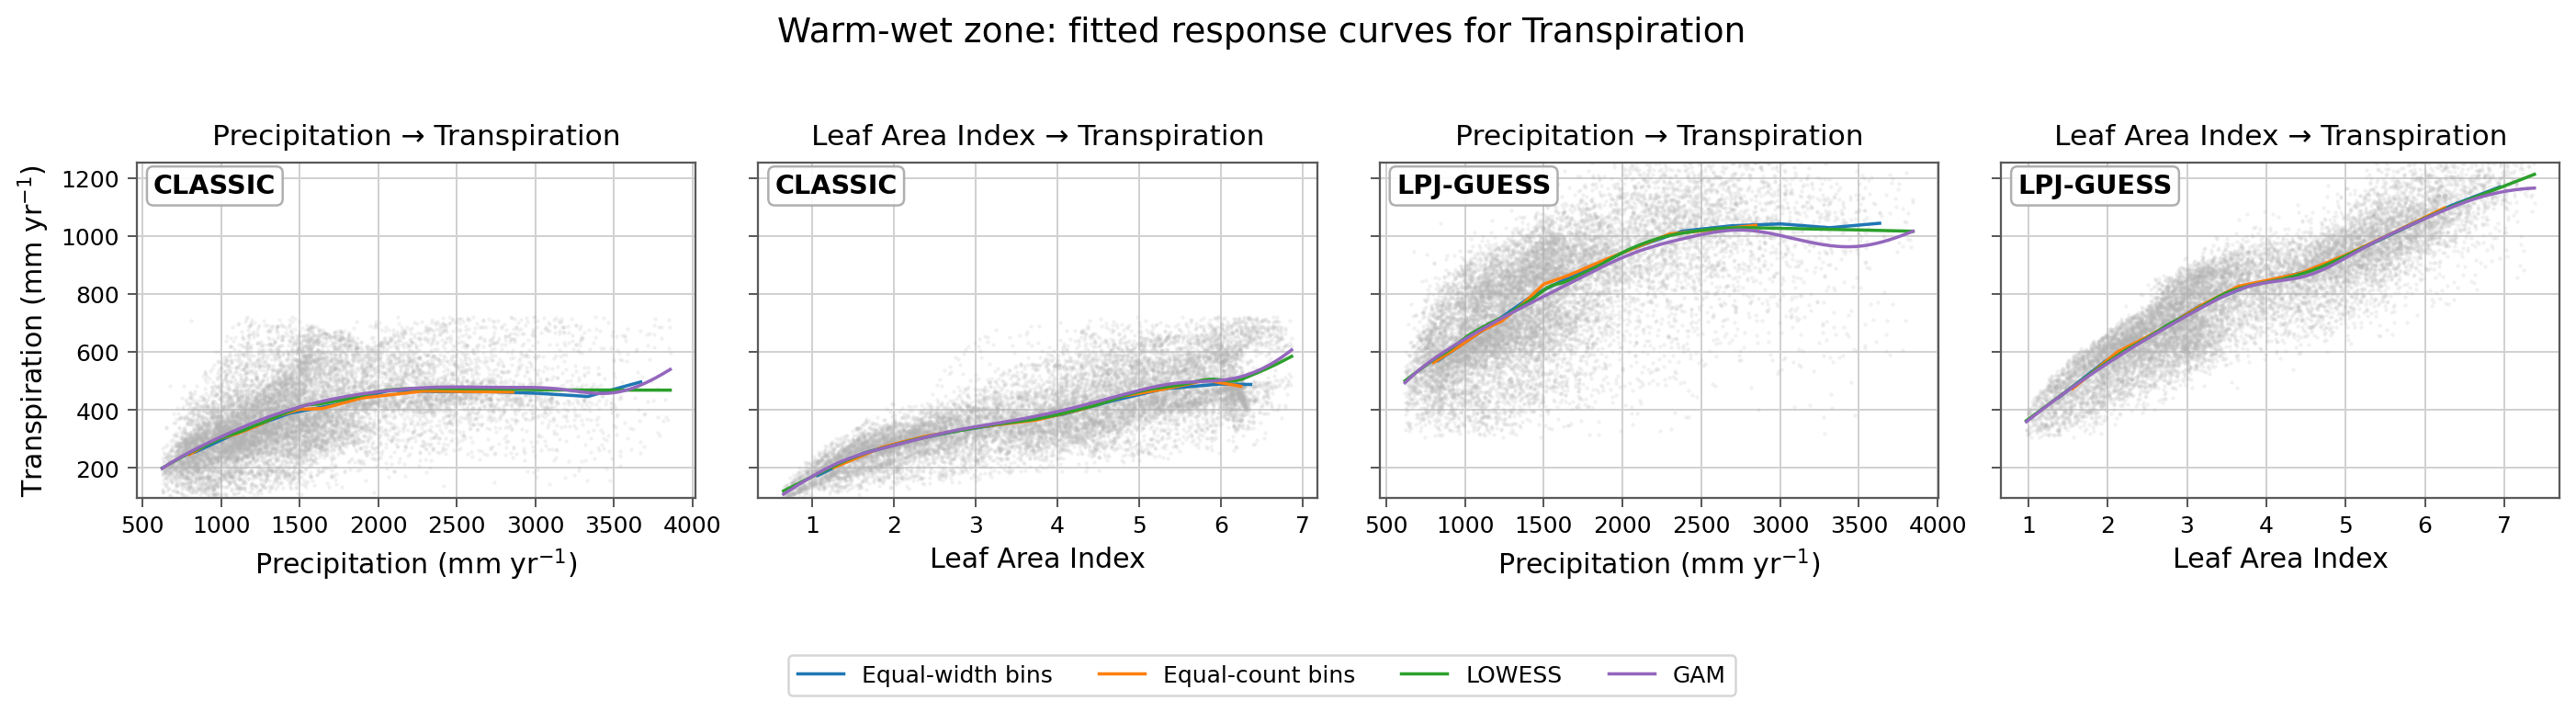

In [44]:
plot_esm_curves_1x4(
    curve_results_t,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    model_names=("CLASSIC", "LPJ-GUESS"),
    methods_to_plot=("Equal-width bins", "Equal-count bins", "LOWESS", "GAM"),
    line_width=1.4,
    point_alpha=0.18,
    n_cols_legend=4
)

plot_esm_curves_1x4(
    curve_results_t,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    model_names=("CLASSIC", "LPJ-GUESS"),
    methods_to_plot=("Equal-width bins", "Equal-count bins", "LOWESS", "GAM"),
    line_width=1.4,
    point_alpha=0.18,
    n_cols_legend=4
)

In [45]:
def plot_one_relation_methods_1x4(
    curve_results,
    climate_zone="HW",
    model_name="CLASSIC",
    x_label="P",
    y_label="T",
    methods_to_plot=("Equal-count bins", "LOWESS", "Equal-width bins", "GAM"),
    sample_size=30000,
    point_size=3,
    point_alpha=0.18,
    line_width=2.0,
    figsize=(16, 3.8),
    dpi=180,
    share_y=True
):
    """
    Plot one model-zone-input-output relationship as 1 x 4 panels,
    with each panel showing one fitting method.

    Example:
    CLASSIC / HW / P -> T:
    Equal-count bins | LOWESS | Equal-width bins | GAM
    """

    method_styles = {
        "Equal-width bins": {
            "color": "#1f77b4",
            "linestyle": "-"
        },
        "Equal-count bins": {
            "color": "#ff7f0e",
            "linestyle": "-"
        },
        "LOWESS": {
            "color": "#2ca02c",
            "linestyle": "-"
        },
        "GAM": {
            "color": "#9467bd",
            "linestyle": "-"
        },
        "Polynomial degree 3": {
            "color": "#d62728",
            "linestyle": "-"
        },
        "Piecewise linear": {
            "color": "#8c564b",
            "linestyle": "-"
        },
        "Symbolic regression": {
            "color": "#e377c2",
            "linestyle": "-"
        }
    }

    key = (x_label, y_label, model_name)

    if key not in curve_results:
        raise KeyError(
            f"Cannot find key {key} in curve_results. "
            f"Available keys include: {list(curve_results.keys())[:5]}"
        )

    result = curve_results[key]

    x_raw = result["x_raw"]
    y_raw = result["y_raw"]
    sub = result["sub"]
    curves = result["curves"]

    # --------------------------------------------------------
    # Scatter sampling
    # --------------------------------------------------------
    if len(sub) > sample_size:
        sub_plot = sub.sample(sample_size, random_state=42)
        x_plot = sub_plot.iloc[:, 0].values
        y_plot = sub_plot.iloc[:, 1].values
    else:
        x_plot = x_raw
        y_plot = y_raw

    # --------------------------------------------------------
    # Shared y-axis limit
    # --------------------------------------------------------
    y_limit = None

    if share_y and len(y_raw) > 0:
        ymin, ymax = np.nanpercentile(y_raw, [1, 99])
        yrange = ymax - ymin

        if yrange == 0:
            yrange = 1

        y_limit = (
            ymin - 0.05 * yrange,
            ymax + 0.05 * yrange
        )

    # --------------------------------------------------------
    # Create 1 x 4 figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        1,
        len(methods_to_plot),
        figsize=figsize,
        dpi=dpi,
        sharey=share_y
    )

    if len(methods_to_plot) == 1:
        axes = [axes]

    for i, method in enumerate(methods_to_plot):
        ax = axes[i]

        # Scatter
        ax.scatter(
            x_plot,
            y_plot,
            s=point_size,
            alpha=point_alpha,
            color="0.70",
            linewidths=0,
            zorder=1
        )

        # Fitted curve
        if method in curves and curves[method] is not None:
            curve = curves[method]

            style = method_styles.get(
                method,
                {
                    "color": "black",
                    "linestyle": "-"
                }
            )

            ax.plot(
                curve["x"],
                curve["y"],
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=line_width,
                label=method,
                zorder=5
            )
        else:
            ax.text(
                0.5,
                0.5,
                f"{method}\nnot available",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
                color="0.35"
            )

        # Method title
        ax.set_title(
            method,
            fontsize=12.5,
            pad=8
        )

        # Axis labels
        ax.set_xlabel(
            full_label_map.get(x_label, x_label),
            fontsize=12
        )

        if i == 0:
            ax.set_ylabel(
                full_label_map.get(y_label, y_label),
                fontsize=12
            )
        else:
            ax.set_ylabel("")
            if share_y:
                ax.tick_params(axis="y", labelleft=False)

        if y_limit is not None:
            ax.set_ylim(y_limit)

        # Model label
        ax.text(
            0.03,
            0.97,
            model_name,
            transform=ax.transAxes,
            fontsize=11.5,
            fontweight="bold",
            ha="left",
            va="top",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.65",
                alpha=0.90
            ),
            zorder=20
        )

        # Style
        ax.set_facecolor("white")
        ax.set_axisbelow(True)
        ax.grid(
            True,
            which="major",
            color="0.82",
            linestyle="-",
            linewidth=0.8
        )
        ax.minorticks_off()

        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(0.9)
            ax.spines[side].set_color("0.35")

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=10,
            length=4,
            width=0.8,
            color="0.35"
        )

    # --------------------------------------------------------
    # Figure title
    # --------------------------------------------------------
    fig.suptitle(
        f"{climate_zone} zone: {model_name}, "
        f"{short_label_map.get(x_label, x_label)} → "
        f"{short_label_map.get(y_label, y_label)}",
        fontsize=15,
        y=1.04
    )

    plt.tight_layout(rect=[0.02, 0.02, 1, 0.96])
    plt.show()

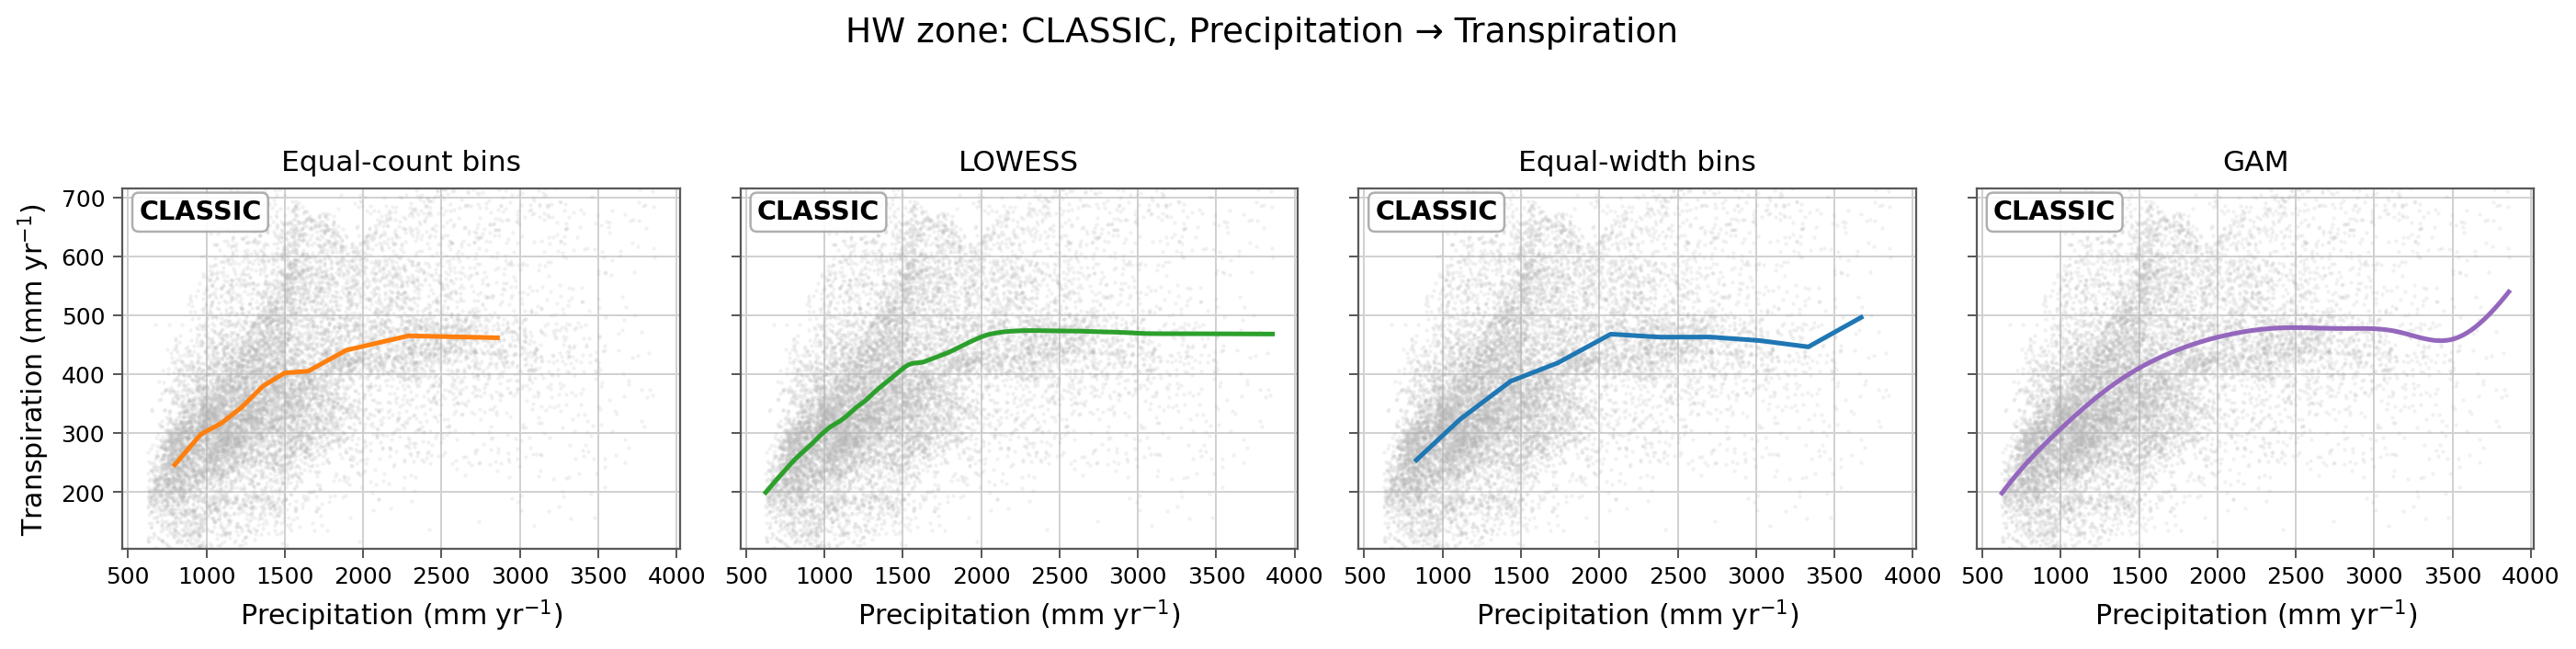

In [46]:
plot_one_relation_methods_1x4(
    curve_results=curve_results_t,
    climate_zone="HW",
    model_name="CLASSIC",
    x_label="P",
    y_label="T",
    methods_to_plot=("Equal-count bins", "LOWESS", "Equal-width bins", "GAM"),
    line_width=2.0,
    point_alpha=0.18
)

In [51]:
def plot_one_relation_methods_1x4_normalized(
    curve_results,
    climate_zone="HW",
    model_name="CLASSIC",
    x_label="P",
    y_label="T",
    methods_to_plot=("Equal-count bins", "LOWESS", "Equal-width bins", "GAM"),
    sample_size=30000,
    point_size=3,
    point_alpha=0.18,
    line_width=2.0,
    figsize=(14, 3.8),
    dpi=180
):
    """
    Plot one model-zone-input-output relationship as 1 x 4 panels,
    with x and y both normalized to [0, 1].

    Example:
    CLASSIC / HW / P -> T:
    Equal-count bins | LOWESS | Equal-width bins | GAM
    """

    method_styles = {
        "Equal-width bins": {
            "color": "#1f77b4",
            "linestyle": "-"
        },
        "Equal-count bins": {
            "color": "#ff7f0e",
            "linestyle": "-"
        },
        "LOWESS": {
            "color": "#2ca02c",
            "linestyle": "-"
        },
        "GAM": {
            "color": "#9467bd",
            "linestyle": "-"
        },
        "Polynomial degree 3": {
            "color": "#d62728",
            "linestyle": "-"
        },
        "Piecewise linear": {
            "color": "#8c564b",
            "linestyle": "-"
        },
        "Symbolic regression": {
            "color": "#e377c2",
            "linestyle": "-"
        }
    }

    key = (x_label, y_label, model_name)

    if key not in curve_results:
        raise KeyError(
            f"Cannot find key {key} in curve_results. "
            f"Available keys include: {list(curve_results.keys())[:5]}"
        )

    result = curve_results[key]

    x_raw = np.asarray(result["x_raw"], dtype=float)
    y_raw = np.asarray(result["y_raw"], dtype=float)
    sub = result["sub"]
    curves = result["curves"]

    # --------------------------------------------------------
    # Normalization reference from raw scatter points
    # --------------------------------------------------------
    valid_raw = np.isfinite(x_raw) & np.isfinite(y_raw)
    x_ref = x_raw[valid_raw]
    y_ref = y_raw[valid_raw]

    x_min, x_max = np.nanmin(x_ref), np.nanmax(x_ref)
    y_min, y_max = np.nanmin(y_ref), np.nanmax(y_ref)

    x_range = x_max - x_min
    y_range = y_max - y_min

    if x_range == 0:
        x_range = 1

    if y_range == 0:
        y_range = 1

    def normalize_x(x):
        x = np.asarray(x, dtype=float)
        return (x - x_min) / x_range

    def normalize_y(y):
        y = np.asarray(y, dtype=float)
        return (y - y_min) / y_range

    # --------------------------------------------------------
    # Scatter sampling
    # --------------------------------------------------------
    if len(sub) > sample_size:
        sub_plot = sub.sample(sample_size, random_state=42)
        x_plot = sub_plot.iloc[:, 0].values
        y_plot = sub_plot.iloc[:, 1].values
    else:
        x_plot = x_raw
        y_plot = y_raw

    x_plot_norm = normalize_x(x_plot)
    y_plot_norm = normalize_y(y_plot)

    valid_plot = np.isfinite(x_plot_norm) & np.isfinite(y_plot_norm)
    x_plot_norm = x_plot_norm[valid_plot]
    y_plot_norm = y_plot_norm[valid_plot]

    # --------------------------------------------------------
    # Create 1 x 4 figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        1,
        len(methods_to_plot),
        figsize=figsize,
        dpi=dpi,
        sharex=True,
        sharey=True
    )

    if len(methods_to_plot) == 1:
        axes = [axes]

    for i, method in enumerate(methods_to_plot):
        ax = axes[i]

        # Scatter
        ax.scatter(
            x_plot_norm,
            y_plot_norm,
            s=point_size,
            alpha=point_alpha,
            color="0.70",
            linewidths=0,
            zorder=1
        )

        # Fitted curve
        if method in curves and curves[method] is not None:
            curve = curves[method]

            x_curve_norm = normalize_x(curve["x"])
            y_curve_norm = normalize_y(curve["y"])

            valid_curve = np.isfinite(x_curve_norm) & np.isfinite(y_curve_norm)
            x_curve_norm = x_curve_norm[valid_curve]
            y_curve_norm = y_curve_norm[valid_curve]

            style = method_styles.get(
                method,
                {
                    "color": "black",
                    "linestyle": "-"
                }
            )

            ax.plot(
                x_curve_norm,
                y_curve_norm,
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=line_width,
                label=method,
                zorder=5
            )
        else:
            ax.text(
                0.5,
                0.5,
                f"{method}\nnot available",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
                color="0.35"
            )

        # Method title
        ax.set_title(
            method,
            fontsize=12.5,
            pad=8
        )

        # Axis labels
        ax.set_xlabel(
            f"Normalized {short_label_map.get(x_label, x_label)} (0–1)",
            fontsize=12
        )

        if i == 0:
            ax.set_ylabel(
                f"Normalized {short_label_map.get(y_label, y_label)} (0–1)",
                fontsize=12
            )
            
        else:
            ax.set_ylabel("")
        
        ax.tick_params(axis="y", labelleft=True)


        # Fixed normalized limits
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)

        # Model label
        ax.text(
            0.03,
            0.97,
            model_name,
            transform=ax.transAxes,
            fontsize=11.5,
            fontweight="bold",
            ha="left",
            va="top",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.65",
                alpha=0.90
            ),
            zorder=20
        )

        # Style
        ax.set_facecolor("white")
        ax.set_axisbelow(True)
        ax.grid(
            True,
            which="major",
            color="0.82",
            linestyle="-",
            linewidth=0.8
        )
        ax.minorticks_off()

        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(0.9)
            ax.spines[side].set_color("0.35")

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=10,
            length=4,
            width=0.8,
            color="0.35"
        )

    fig.suptitle(
        f"{climate_zone} zone: {model_name}, "
        f"{short_label_map.get(x_label, x_label)} → "
        f"{short_label_map.get(y_label, y_label)} "
        f"(normalized)",
        fontsize=15,
        y=1.04
    )

    plt.tight_layout(rect=[0.02, 0.02, 1, 0.96])
    plt.show()

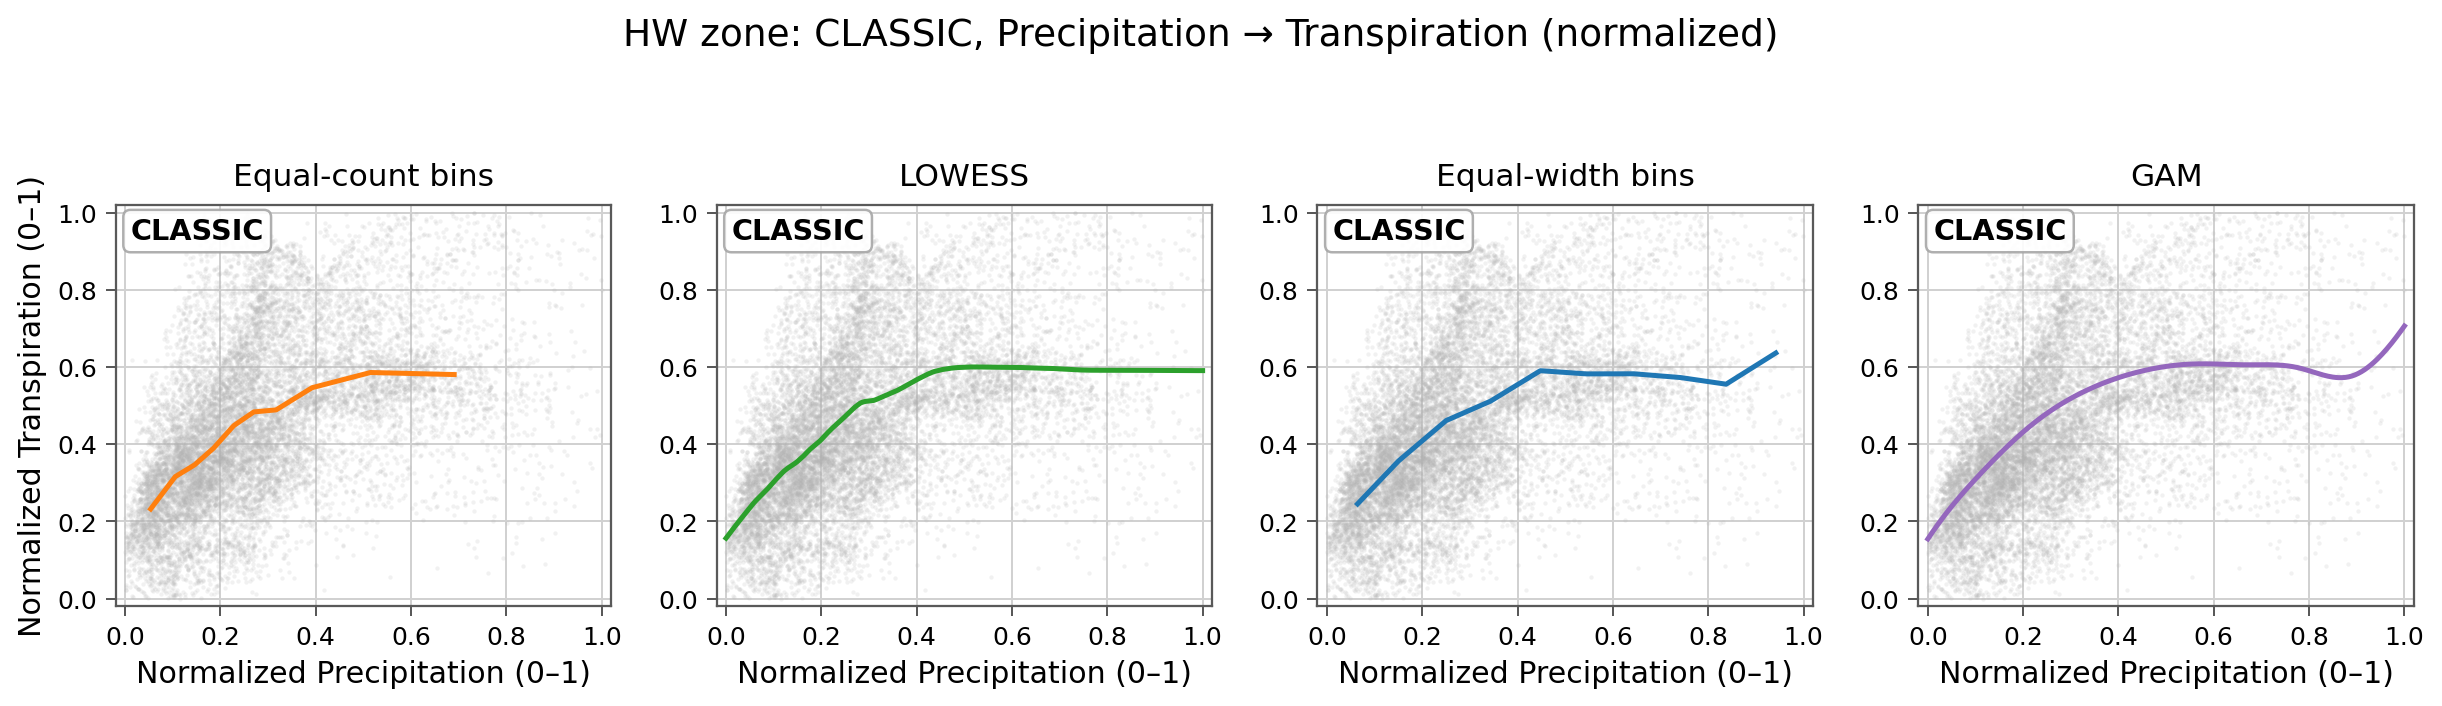

In [52]:
plot_one_relation_methods_1x4_normalized(
    curve_results=curve_results_t,
    climate_zone="HW",
    model_name="CLASSIC",
    x_label="P",
    y_label="T",
    methods_to_plot=("Equal-count bins", "LOWESS", "Equal-width bins", "GAM"),
    line_width=2.0,
    point_alpha=0.18
)

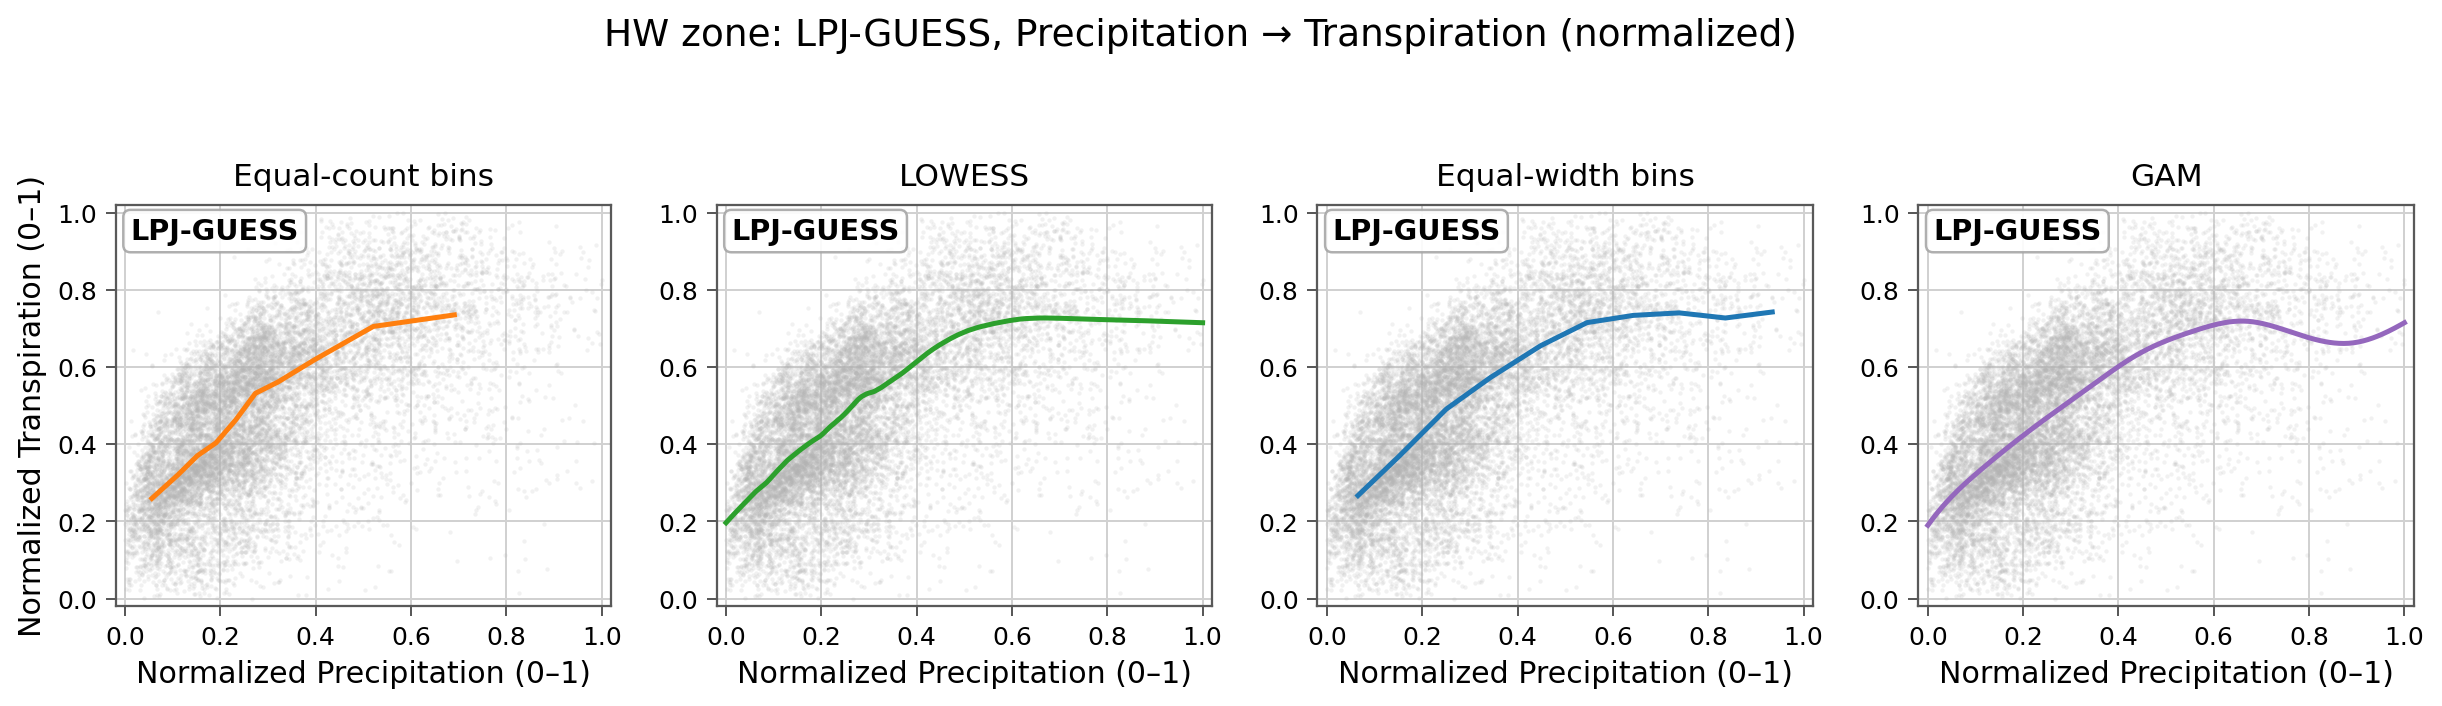

In [87]:
plot_one_relation_methods_1x4_normalized(
    curve_results=curve_results_t,
    climate_zone="HW",
    model_name="LPJ-GUESS",
    x_label="P",
    y_label="T",
    methods_to_plot=("Equal-count bins", "LOWESS", "Equal-width bins", "GAM"),
    line_width=2.0,
    point_alpha=0.18
)

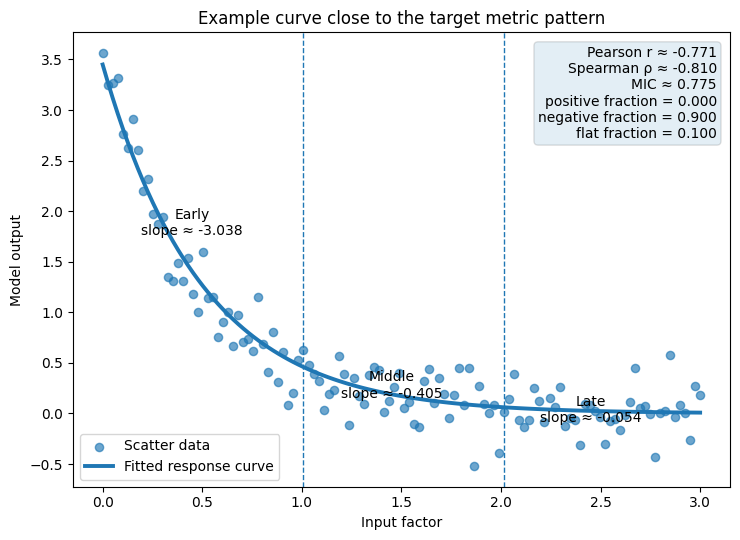

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Optional: MIC
# pip install minepy
try:
    from minepy import MINE
    HAS_MINEPY = True
except ImportError:
    HAS_MINEPY = False


# ============================================================
# 1. Helper functions
# ============================================================

def calculate_mic(x, y):
    if not HAS_MINEPY:
        return np.nan

    mine = MINE(alpha=0.6, c=15)
    mine.compute_score(x, y)
    return mine.mic()


def calculate_shape_fractions(x, y, slope_tol=0.03):
    """
    Calculate positive / negative / flat fraction from local slopes.
    """
    slopes = np.gradient(y, x)

    positive_fraction = np.mean(slopes > slope_tol)
    negative_fraction = np.mean(slopes < -slope_tol)
    flat_fraction = np.mean(np.abs(slopes) <= slope_tol)

    return positive_fraction, negative_fraction, flat_fraction, slopes


def calculate_stage_slopes(x, y):
    """
    Calculate early / middle / late mean slopes.
    """
    slopes = np.gradient(y, x)

    n = len(slopes)
    early = slopes[: n // 3]
    middle = slopes[n // 3 : 2 * n // 3]
    late = slopes[2 * n // 3 :]

    return early.mean(), middle.mean(), late.mean()


# ============================================================
# 2. Generate a curve close to the target metrics
# ============================================================

np.random.seed(42)

n = 120
x = np.linspace(0, 3, n)

# A monotonic saturating decreasing curve
# Large negative slope at the beginning, then gradually flattening
base_y = 3.0 * np.exp(-2.0 * x)

# Add moderate noise to make Pearson / Spearman around -0.8
noise = np.random.normal(0, 0.23, n)

y_raw = base_y + noise

# Enforce an overall decreasing fitted curve for shape metrics
# This fitted curve represents the response curve, not raw scatter
y_fit = 3.0 * np.exp(-2.0 * x)

# Rescale fitted curve so its stage slopes are close to:
# early = -2.451, middle = -0.463, late = -0.087
scale = 1.15
y_fit = scale * y_fit

# Scatter points around the fitted curve
y_scatter = y_fit + noise


# ============================================================
# 3. Calculate metrics
# ============================================================

pearson_r, _ = pearsonr(x, y_scatter)
spearman_rho, _ = spearmanr(x, y_scatter)
mic_value = calculate_mic(x, y_scatter)

pos_frac, neg_frac, flat_frac, slopes = calculate_shape_fractions(
    x, y_fit,
    slope_tol=0.03
)

early_slope, middle_slope, late_slope = calculate_stage_slopes(x, y_fit)


# ============================================================
# 4. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(
    x,
    y_scatter,
    s=35,
    alpha=0.65,
    label="Scatter data"
)

ax.plot(
    x,
    y_fit,
    linewidth=2.8,
    label="Fitted response curve"
)

# Stage boundaries
ax.axvline(x[len(x)//3], linestyle="--", linewidth=1)
ax.axvline(x[2*len(x)//3], linestyle="--", linewidth=1)

# Stage labels
ax.text(
    0.45,
    y_fit[12],
    f"Early\nslope ≈ {early_slope:.3f}",
    ha="center",
    va="center"
)

ax.text(
    1.45,
    y_fit[50],
    f"Middle\nslope ≈ {middle_slope:.3f}",
    ha="center",
    va="center"
)

ax.text(
    2.45,
    y_fit[92],
    f"Late\nslope ≈ {late_slope:.3f}",
    ha="center",
    va="center"
)

# Metric annotation
metric_text = (
    f"Pearson r ≈ {pearson_r:.3f}\n"
    f"Spearman ρ ≈ {spearman_rho:.3f}\n"
)

if HAS_MINEPY:
    metric_text += f"MIC ≈ {mic_value:.3f}\n"
else:
    metric_text += "MIC: install minepy to compute\n"

metric_text += (
    f"positive fraction = {pos_frac:.3f}\n"
    f"negative fraction = {neg_frac:.3f}\n"
    f"flat fraction = {flat_frac:.3f}"
)

ax.text(
    0.98,
    0.97,
    metric_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.12)
)

ax.set_xlabel("Input factor")
ax.set_ylabel("Model output")
ax.set_title("Example curve close to the target metric pattern")

ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [70]:
import numpy as np
import matplotlib.pyplot as plt


def plot_selected_xy_distributions(
    curve_results,
    model_name="CLASSIC",
    x_label="P",
    y_label="T",
    climate_zone="HW",
    bins=40,
    figsize=(10, 3.8),
    dpi=180,
    show_mean=True,
    show_median=True,
    density=False
):
    """
    Plot distributions of x_raw and y_raw for one selected relationship.

    Parameters
    ----------
    curve_results : dict
        Existing curve_results object.

    model_name : str
        Model name, e.g. "CLASSIC" or "LPJ-GUESS".

    x_label : str
        Input variable, e.g. "P" or "LAI".

    y_label : str
        Output variable, e.g. "T", "E_soil", "ET".

    climate_zone : str
        Only used for figure title.

    bins : int
        Number of histogram bins.

    density : bool
        If True, plot density instead of count.
    """

    key = (x_label, y_label, model_name)

    if key not in curve_results:
        raise KeyError(
            f"Cannot find key {key} in curve_results. "
            f"Available keys include: {list(curve_results.keys())[:5]}"
        )

    result = curve_results[key]

    x_raw = np.asarray(result["x_raw"], dtype=float)
    y_raw = np.asarray(result["y_raw"], dtype=float)

    valid = np.isfinite(x_raw) & np.isfinite(y_raw)
    x_raw = x_raw[valid]
    y_raw = y_raw[valid]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        dpi=dpi
    )

    variables = [
        (x_raw, x_label, axes[0]),
        (y_raw, y_label, axes[1]),
    ]

    for values, label, ax in variables:
        ax.hist(
            values,
            bins=bins,
            density=density,
            alpha=0.75,
            edgecolor="white",
            linewidth=0.6
        )

        if show_mean:
            mean_val = np.nanmean(values)
            ax.axvline(
                mean_val,
                linestyle="--",
                linewidth=1.5,
                label=f"Mean = {mean_val:.2f}"
            )

        if show_median:
            median_val = np.nanmedian(values)
            ax.axvline(
                median_val,
                linestyle="-",
                linewidth=1.5,
                label=f"Median = {median_val:.2f}"
            )

        ax.set_title(
            f"{short_label_map.get(label, label)} distribution",
            fontsize=12.5,
            pad=8
        )

        ax.set_xlabel(
            full_label_map.get(label, label),
            fontsize=11.5
        )

        ax.set_ylabel(
            "Density" if density else "Count",
            fontsize=11.5
        )

        ax.grid(
            True,
            which="major",
            color="0.85",
            linestyle="-",
            linewidth=0.7
        )

        ax.set_axisbelow(True)

        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(0.8)
            ax.spines[side].set_color("0.35")

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=10,
            length=3.5,
            width=0.8,
            color="0.35"
        )

        ax.legend(
            frameon=True,
            fontsize=9
        )

    fig.suptitle(
        f"{climate_zone} zone: {model_name}, "
        f"{short_label_map.get(x_label, x_label)} → "
        f"{short_label_map.get(y_label, y_label)}",
        fontsize=14,
        y=1.03
    )

    plt.tight_layout()
    plt.show()

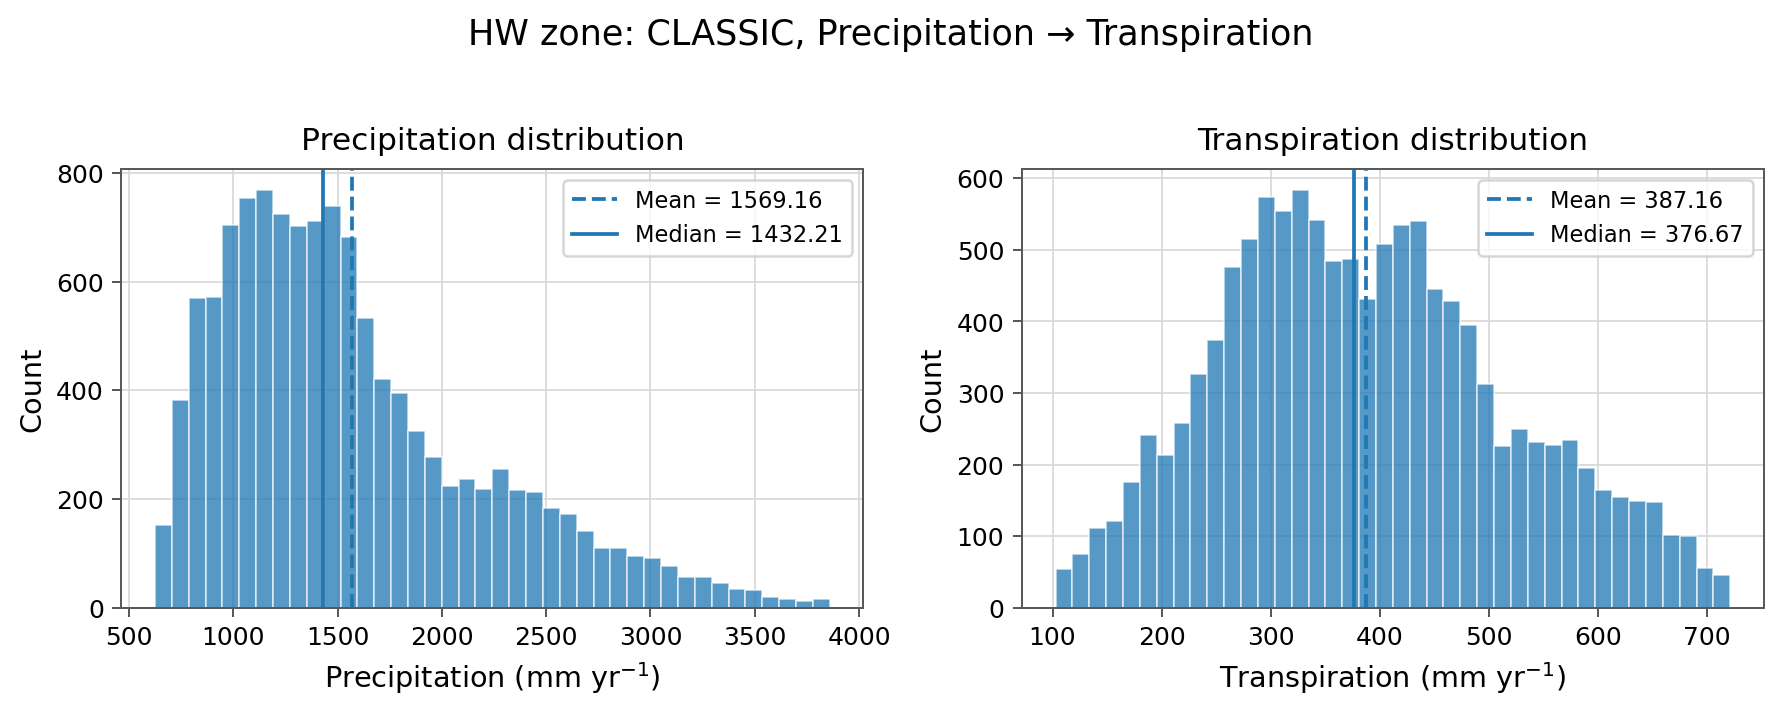

In [71]:
plot_selected_xy_distributions(
    curve_results=curve_results_t,
    climate_zone="HW",
    model_name="CLASSIC",
    x_label="P",
    y_label="T",
    bins=40,
    density=False
)

In [96]:
# ============================================================
# Association metrics from raw scatter points
# ============================================================

def _safe_corr_metrics(x, y):
    """
    Compute Pearson r, Spearman rho, and Kendall tau
    from raw scatter points.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return {
            "Pearson r": np.nan,
            "Pearson p": np.nan,
            "Spearman rho": np.nan,
            "Spearman p": np.nan,
            "Kendall tau": np.nan,
            "Kendall p": np.nan,
        }

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    kendall_tau, kendall_p = kendalltau(x, y)

    return {
        "Pearson r": pearson_r,
        "Pearson p": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman p": spearman_p,
        "Kendall tau": kendall_tau,
        "Kendall p": kendall_p,
    }


def _safe_mic(x, y, alpha=0.6, c=15):
    """
    Compute MIC from raw scatter points.

    MIC ranges from 0 to 1.
    Higher MIC indicates stronger general association,
    including nonlinear relationships.

    If minepy is not installed, return NaN.
    """
    if not MINE_AVAILABLE:
        return np.nan

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan

    try:
        mine = MINE(alpha=alpha, c=c)
        mine.compute_score(x, y)
        return mine.mic()
    except Exception:
        return np.nan
    

# ============================================================
# Turning point detection from fitted curve slopes
# ============================================================

def _compute_slopes(x_for_slope, y_used):
    """
    Compute local slopes dy/dx.
    """
    dx = np.gradient(x_for_slope)
    dy = np.gradient(y_used)

    valid_slope = (
        np.isfinite(dx)
        & np.isfinite(dy)
        & (np.abs(dx) > 1e-12)
    )

    slopes = np.full_like(y_used, np.nan, dtype=float)
    slopes[valid_slope] = dy[valid_slope] / dx[valid_slope]

    return slopes


def _detect_turning_points_from_slopes(
    x_norm,
    y_used,
    slopes,
    slope_tol=0.03,
    turn_window=5
):
    """
    Detect turning points based on local slope sign changes.

    Turning point definition:
    - positive slope to negative slope: peak-like turning point
    - negative slope to positive slope: valley-like turning point

    Flat segments are ignored when detecting sign changes.

    Returns:
    - n_turning_points
    - first_turning_x_norm
    - first_turning_y_value
    - first_turning_type
    - first_turning_left_slope
    - first_turning_right_slope
    - main_turning_x_norm
    - main_turning_y_value
    - main_turning_type
    - main_turning_left_slope
    - main_turning_right_slope
    """

    x_norm = np.asarray(x_norm, dtype=float)
    y_used = np.asarray(y_used, dtype=float)
    slopes = np.asarray(slopes, dtype=float)

    if len(slopes) < 3:
        return {
            "n_turning_points": 0,
            "first_turning_x_norm": np.nan,
            "first_turning_y_value": np.nan,
            "first_turning_type": np.nan,
            "first_turning_left_slope": np.nan,
            "first_turning_right_slope": np.nan,
            "main_turning_x_norm": np.nan,
            "main_turning_y_value": np.nan,
            "main_turning_type": np.nan,
            "main_turning_left_slope": np.nan,
            "main_turning_right_slope": np.nan,
        }

    # Convert slopes to signs
    signs = np.full(len(slopes), 0, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1

    # Ignore flat points when detecting sign changes
    nonflat_idx = np.where(signs != 0)[0]

    if len(nonflat_idx) < 2:
        return {
            "n_turning_points": 0,
            "first_turning_x_norm": np.nan,
            "first_turning_y_value": np.nan,
            "first_turning_type": np.nan,
            "first_turning_left_slope": np.nan,
            "first_turning_right_slope": np.nan,
            "main_turning_x_norm": np.nan,
            "main_turning_y_value": np.nan,
            "main_turning_type": np.nan,
            "main_turning_left_slope": np.nan,
            "main_turning_right_slope": np.nan,
        }

    turning_records = []

    for j in range(1, len(nonflat_idx)):
        prev_idx = nonflat_idx[j - 1]
        curr_idx = nonflat_idx[j]

        prev_sign = signs[prev_idx]
        curr_sign = signs[curr_idx]

        if prev_sign == curr_sign:
            continue

        # Approximate turning point location:
        # use the midpoint index between the last non-flat segment and next non-flat segment
        turn_idx = int(round((prev_idx + curr_idx) / 2))

        if prev_sign > 0 and curr_sign < 0:
            turn_type = "peak"
        elif prev_sign < 0 and curr_sign > 0:
            turn_type = "valley"
        else:
            turn_type = "unknown"

        left_start = max(0, turn_idx - turn_window)
        left_end = turn_idx

        right_start = turn_idx + 1
        right_end = min(len(slopes), turn_idx + 1 + turn_window)

        left_vals = slopes[left_start:left_end]
        right_vals = slopes[right_start:right_end]

        left_vals = left_vals[np.isfinite(left_vals)]
        right_vals = right_vals[np.isfinite(right_vals)]

        left_slope = np.nanmean(left_vals) if len(left_vals) > 0 else np.nan
        right_slope = np.nanmean(right_vals) if len(right_vals) > 0 else np.nan

        # Turning strength: how strong the sign reversal is
        turning_strength = np.nan
        if np.isfinite(left_slope) and np.isfinite(right_slope):
            turning_strength = abs(left_slope - right_slope)

        turning_records.append({
            "turn_idx": turn_idx,
            "turning_x_norm": x_norm[turn_idx],
            "turning_y_value": y_used[turn_idx],
            "turning_type": turn_type,
            "turning_left_slope": left_slope,
            "turning_right_slope": right_slope,
            "turning_strength": turning_strength,
        })

    if len(turning_records) == 0:
        return {
            "n_turning_points": 0,
            "first_turning_x_norm": np.nan,
            "first_turning_y_value": np.nan,
            "first_turning_type": np.nan,
            "first_turning_left_slope": np.nan,
            "first_turning_right_slope": np.nan,
            "main_turning_x_norm": np.nan,
            "main_turning_y_value": np.nan,
            "main_turning_type": np.nan,
            "main_turning_left_slope": np.nan,
            "main_turning_right_slope": np.nan,
        }

    # First turning point by x order
    first_turn = turning_records[0]

    # Main turning point = strongest reversal
    main_turn = max(
        turning_records,
        key=lambda d: -np.inf if not np.isfinite(d["turning_strength"]) else d["turning_strength"]
    )

    return {
        "n_turning_points": len(turning_records),

        "first_turning_x_norm": first_turn["turning_x_norm"],
        "first_turning_y_value": first_turn["turning_y_value"],
        "first_turning_type": first_turn["turning_type"],
        "first_turning_left_slope": first_turn["turning_left_slope"],
        "first_turning_right_slope": first_turn["turning_right_slope"],

        "main_turning_x_norm": main_turn["turning_x_norm"],
        "main_turning_y_value": main_turn["turning_y_value"],
        "main_turning_type": main_turn["turning_type"],
        "main_turning_left_slope": main_turn["turning_left_slope"],
        "main_turning_right_slope": main_turn["turning_right_slope"],
    }

In [95]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# Association metrics from raw scatter points
# ============================================================

def _safe_corr_metrics(x, y):
    """
    Compute Pearson r, Spearman rho, and Kendall tau
    from raw scatter points.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return {
            "Pearson r": np.nan,
            "Pearson p": np.nan,
            "Spearman rho": np.nan,
            "Spearman p": np.nan,
            "Kendall tau": np.nan,
            "Kendall p": np.nan,
        }

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    kendall_tau, kendall_p = kendalltau(x, y)

    return {
        "Pearson r": pearson_r,
        "Pearson p": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman p": spearman_p,
        "Kendall tau": kendall_tau,
        "Kendall p": kendall_p,
    }


def _safe_mic(x, y, alpha=0.6, c=15):
    """
    Compute MIC from raw scatter points.

    MIC ranges from 0 to 1.
    Higher MIC indicates stronger general association,
    including nonlinear relationships.

    If minepy is not installed, return NaN.
    """
    if not MINE_AVAILABLE:
        return np.nan

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan

    try:
        mine = MINE(alpha=alpha, c=c)
        mine.compute_score(x, y)
        return mine.mic()
    except Exception:
        return np.nan
    
# ============================================================
# Utility
# ============================================================

def _normalize_01(arr):
    """
    Normalize an array to [0, 1].
    Return None if the range is invalid.
    """
    arr = np.asarray(arr, dtype=float)

    if len(arr) == 0:
        return None

    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)

    if not np.isfinite(arr_min) or not np.isfinite(arr_max):
        return None

    if arr_max == arr_min:
        return None

    return (arr - arr_min) / (arr_max - arr_min)


def _prepare_curve_xy(x_curve, y_curve):
    """
    Clean, sort, and remove duplicated x values.
    """
    x = np.asarray(x_curve, dtype=float)
    y = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return x, y

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    unique_mask = np.concatenate([[True], np.diff(x) > 0])
    x = x[unique_mask]
    y = y[unique_mask]

    return x, y

def _compute_slope_set(
    x,
    y_used,
    x_for_slope,
    x_for_split,
    slope_tol=0.03,
    turn_window=5
):
    """
    Compute slope fractions, early/middle/late slopes,
    number of turning points, and local slopes around turning points.
    """

    slopes = _compute_slopes(
        x_for_slope=x_for_slope,
        y_used=y_used
    )

    slopes_valid = slopes[np.isfinite(slopes)]

    if len(slopes_valid) == 0:
        positive_fraction = np.nan
        negative_fraction = np.nan
        flat_fraction = np.nan
    else:
        positive_fraction = np.mean(slopes_valid > slope_tol)
        negative_fraction = np.mean(slopes_valid < -slope_tol)
        flat_fraction = np.mean(np.abs(slopes_valid) <= slope_tol)

    early_mask = x_for_split <= 1 / 3
    middle_mask = (x_for_split > 1 / 3) & (x_for_split <= 2 / 3)
    late_mask = x_for_split > 2 / 3

    def _mean_slope(mask):
        vals = slopes[mask]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            return np.nan
        return np.nanmean(vals)

    turning_info = _detect_turning_points_from_slopes(
        x_norm=x_for_split,
        y_used=y_used,
        slopes=slopes,
        slope_tol=slope_tol,
        turn_window=turn_window
    )

    return {
        "positive_fraction": positive_fraction,
        "negative_fraction": negative_fraction,
        "flat_fraction": flat_fraction,

        "early_slope": _mean_slope(early_mask),
        "middle_slope": _mean_slope(middle_mask),
        "late_slope": _mean_slope(late_mask),

        **turning_info,
    }
# ============================================================
# Main function: compute both shape and strength slope metrics
# ============================================================
def compute_dual_slope_descriptors_for_curve(
    x_curve,
    y_curve,
    y_raw=None,
    slope_tol=0.03,
    turn_window=5,
):
    """
    Compute two sets of slope descriptors for one fitted curve.

    1. Shape-normalized metrics:
       x: min-max normalized to [0, 1]
       y: min-max normalized to [0, 1]

    2. Strength-standardized metrics:
       x: min-max normalized to [0, 1]
       y: divided by raw y standard deviation

    Turning points are calculated from local slope sign changes.
    """

    x, y = _prepare_curve_xy(x_curve, y_curve)

    if len(x) < 3:
        return {
            "net_change_raw": np.nan,

            "shape_net_change": np.nan,
            "shape_positive_fraction": np.nan,
            "shape_negative_fraction": np.nan,
            "shape_flat_fraction": np.nan,
            "shape_early_slope": np.nan,
            "shape_middle_slope": np.nan,
            "shape_late_slope": np.nan,
            "shape_n_turning_points": np.nan,
            "shape_first_turning_x_norm": np.nan,
            "shape_first_turning_y_value": np.nan,
            "shape_first_turning_type": np.nan,
            "shape_first_turning_left_slope": np.nan,
            "shape_first_turning_right_slope": np.nan,
            "shape_main_turning_x_norm": np.nan,
            "shape_main_turning_y_value": np.nan,
            "shape_main_turning_type": np.nan,
            "shape_main_turning_left_slope": np.nan,
            "shape_main_turning_right_slope": np.nan,

            "strength_net_change_sd": np.nan,
            "strength_positive_fraction": np.nan,
            "strength_negative_fraction": np.nan,
            "strength_flat_fraction": np.nan,
            "strength_early_slope": np.nan,
            "strength_middle_slope": np.nan,
            "strength_late_slope": np.nan,
            "strength_n_turning_points": np.nan,
            "strength_first_turning_x_norm": np.nan,
            "strength_first_turning_y_value": np.nan,
            "strength_first_turning_type": np.nan,
            "strength_first_turning_left_slope": np.nan,
            "strength_first_turning_right_slope": np.nan,
            "strength_main_turning_x_norm": np.nan,
            "strength_main_turning_y_value": np.nan,
            "strength_main_turning_type": np.nan,
            "strength_main_turning_left_slope": np.nan,
            "strength_main_turning_right_slope": np.nan,

            "y_raw_sd": np.nan,
            "n_curve_points": len(x),
        }

    # --------------------------------------------------------
    # Common x normalization
    # --------------------------------------------------------
    x_norm = _normalize_01(x)

    if x_norm is None:
        x_norm = np.linspace(0, 1, len(x))

    # Raw net change
    net_change_raw = y[-1] - y[0]

    # ========================================================
    # A. Shape-normalized version
    # ========================================================
    y_shape = _normalize_01(y)

    if y_shape is not None:
        shape_net_change = y_shape[-1] - y_shape[0]

        shape_slopes = _compute_slope_set(
            x=x,
            y_used=y_shape,
            x_for_slope=x_norm,
            x_for_split=x_norm,
            slope_tol=slope_tol,
            turn_window=turn_window
        )
    else:
        shape_net_change = np.nan
        shape_slopes = _empty_slope_turning_dict()

    # ========================================================
    # B. Strength-standardized version
    # ========================================================
    y_raw_sd = np.nan

    if y_raw is not None:
        y_raw_arr = np.asarray(y_raw, dtype=float)
        y_raw_arr = y_raw_arr[np.isfinite(y_raw_arr)]

        if len(y_raw_arr) > 1:
            y_raw_sd = np.nanstd(y_raw_arr)

    if np.isfinite(y_raw_sd) and y_raw_sd > 0:
        y_strength = y / y_raw_sd
        strength_net_change_sd = net_change_raw / y_raw_sd

        strength_slopes = _compute_slope_set(
            x=x,
            y_used=y_strength,
            x_for_slope=x_norm,
            x_for_split=x_norm,
            slope_tol=slope_tol,
            turn_window=turn_window
        )
    else:
        strength_net_change_sd = np.nan
        strength_slopes = _empty_slope_turning_dict()

    return {
        "net_change_raw": net_change_raw,

        # Shape-normalized metrics
        "shape_net_change": shape_net_change,
        "shape_positive_fraction": shape_slopes["positive_fraction"],
        "shape_negative_fraction": shape_slopes["negative_fraction"],
        "shape_flat_fraction": shape_slopes["flat_fraction"],
        "shape_early_slope": shape_slopes["early_slope"],
        "shape_middle_slope": shape_slopes["middle_slope"],
        "shape_late_slope": shape_slopes["late_slope"],
        "shape_n_turning_points": shape_slopes["n_turning_points"],
        "shape_first_turning_x_norm": shape_slopes["first_turning_x_norm"],
        "shape_first_turning_y_value": shape_slopes["first_turning_y_value"],
        "shape_first_turning_type": shape_slopes["first_turning_type"],
        "shape_first_turning_left_slope": shape_slopes["first_turning_left_slope"],
        "shape_first_turning_right_slope": shape_slopes["first_turning_right_slope"],
        "shape_main_turning_x_norm": shape_slopes["main_turning_x_norm"],
        "shape_main_turning_y_value": shape_slopes["main_turning_y_value"],
        "shape_main_turning_type": shape_slopes["main_turning_type"],
        "shape_main_turning_left_slope": shape_slopes["main_turning_left_slope"],
        "shape_main_turning_right_slope": shape_slopes["main_turning_right_slope"],

        # Strength-standardized metrics
        "strength_net_change_sd": strength_net_change_sd,
        "strength_positive_fraction": strength_slopes["positive_fraction"],
        "strength_negative_fraction": strength_slopes["negative_fraction"],
        "strength_flat_fraction": strength_slopes["flat_fraction"],
        "strength_early_slope": strength_slopes["early_slope"],
        "strength_middle_slope": strength_slopes["middle_slope"],
        "strength_late_slope": strength_slopes["late_slope"],
        "strength_n_turning_points": strength_slopes["n_turning_points"],
        "strength_first_turning_x_norm": strength_slopes["first_turning_x_norm"],
        "strength_first_turning_y_value": strength_slopes["first_turning_y_value"],
        "strength_first_turning_type": strength_slopes["first_turning_type"],
        "strength_first_turning_left_slope": strength_slopes["first_turning_left_slope"],
        "strength_first_turning_right_slope": strength_slopes["first_turning_right_slope"],
        "strength_main_turning_x_norm": strength_slopes["main_turning_x_norm"],
        "strength_main_turning_y_value": strength_slopes["main_turning_y_value"],
        "strength_main_turning_type": strength_slopes["main_turning_type"],
        "strength_main_turning_left_slope": strength_slopes["main_turning_left_slope"],
        "strength_main_turning_right_slope": strength_slopes["main_turning_right_slope"],

        "y_raw_sd": y_raw_sd,
        "n_curve_points": len(x),
    }


def _empty_slope_turning_dict():
    return {
        "positive_fraction": np.nan,
        "negative_fraction": np.nan,
        "flat_fraction": np.nan,
        "early_slope": np.nan,
        "middle_slope": np.nan,
        "late_slope": np.nan,

        "n_turning_points": np.nan,
        "first_turning_x_norm": np.nan,
        "first_turning_y_value": np.nan,
        "first_turning_type": np.nan,
        "first_turning_left_slope": np.nan,
        "first_turning_right_slope": np.nan,
        "main_turning_x_norm": np.nan,
        "main_turning_y_value": np.nan,
        "main_turning_type": np.nan,
        "main_turning_left_slope": np.nan,
        "main_turning_right_slope": np.nan,
    }
def make_dual_slope_descriptor_table(
    curve_results,
    slope_tol=0.03,
    turn_window=5,
    mic_alpha=0.6,
    mic_c=15,
    round_numeric=True,
):
    """
    Apply dual slope-descriptor calculation to all fitted curves.

    Raw association metrics:
    - Pearson r
    - Spearman rho
    - Kendall tau
    - MIC

    These are calculated from raw scatter points and are the same
    for all fitting methods under the same model-x-y relationship.

    Curve-form metrics:
    - shape slopes
    - strength slopes
    - number of turning points
    - local slopes around turning points

    These are calculated from fitted curves and may differ by method.
    """

    records = []

    for key, result in curve_results.items():
        x_label, y_label, model_name = key

        x_raw = result.get("x_raw", None)
        y_raw = result.get("y_raw", None)
        curves = result.get("curves", {})

        # ----------------------------------------------------
        # Raw scatter association metrics
        # ----------------------------------------------------
        corr_metrics = _safe_corr_metrics(x_raw, y_raw)

        raw_mic = _safe_mic(
            x_raw,
            y_raw,
            alpha=mic_alpha,
            c=mic_c
        )

        for method, curve in curves.items():
            if curve is None:
                continue

            if "x" not in curve or "y" not in curve:
                continue

            descriptors = compute_dual_slope_descriptors_for_curve(
                x_curve=curve["x"],
                y_curve=curve["y"],
                y_raw=y_raw,
                slope_tol=slope_tol,
                turn_window=turn_window,
            )

            records.append({
                "model": model_name,
                "x": x_label,
                "y": y_label,
                "method": method,

                # Raw scatter association
                "Pearson r": corr_metrics["Pearson r"],
                "Pearson p": corr_metrics["Pearson p"],
                "Spearman rho": corr_metrics["Spearman rho"],
                "Spearman p": corr_metrics["Spearman p"],
                "Kendall tau": corr_metrics["Kendall tau"],
                "Kendall p": corr_metrics["Kendall p"],
                "MIC": raw_mic,

                # Curve descriptors
                **descriptors,
            })

    descriptor_df = pd.DataFrame(records)

    if round_numeric and len(descriptor_df) > 0:
        num_cols = descriptor_df.select_dtypes(include=[np.number]).columns
        descriptor_df[num_cols] = descriptor_df[num_cols].round(4)

    return descriptor_df
# ============================================================
# Run for E_soil
# ============================================================

# basic_slope_esoil_df = make_basic_slope_descriptor_table(
#     curve_results=curve_results_esoil,
#     slope_tol=0.03,
#     normalize_x=True,
#     normalize_y_by="raw_sd",
#     round_numeric=True,
# )

# basic_slope_esoil_df

In [97]:
dual_slope_t_df = make_dual_slope_descriptor_table(
    curve_results=curve_results_t,
    slope_tol=0.03,
    round_numeric=True,
)

dual_slope_t_df


output_dir = Path("./form_metric_outputs/HW")
output_dir.mkdir(parents=True, exist_ok=True)

dual_slope_t_df.to_csv(
    output_dir / "dual_slope_descriptors_t.csv",
    index=False
)
